# Exploratory & Descriptive Analytics — Demo (`demo.parsewise.ai`)

This notebook describes how external prospects used the Parsewise demo environment. Navi is Parsewise's AI agent. In the live product, paying customers chat with Navi directly. In the public demo, prospects can **only read** example Navi conversations; they cannot type into the agent. The main conversion proxy in this export is the **"Sign up to chat with Navi"** CTA, which appears on Navi pages, in the top navigation, and in the sidebar.

Important product-routing context: public demo users are sent a direct link to a demo that is already preselected by project, such as `Insurance Claims Portfolio Triage`. They do **not** see the internal project-selection page shown in some product screenshots, and they cannot navigate back to that page through the normal UI without manually changing the URL. That means observed project-level activity reflects the demo link they were given, not an in-session choice from a visible project menu.

Important note for this export: `demo@parsewise.ai` is a shared identifier for public demo users, not an internal Parsewise employee account. Those visitors must therefore remain in-scope throughout the analysis.

The notebook remains strictly descriptive. It does **not** add funnel analysis, bootstrapping, Markov chains, clustering, segmentation, or CTGAN work.


### PostHog terms used below

- `distinct_id` vs `person_id`: `distinct_id` is the browser or device-level event identifier. `person_id` is PostHog's merged person record. For this demo export, `distinct_id` is the clearest unit for prospect-level browsing behaviour.
- `channel_type`: PostHog's session-level acquisition bucket, such as Direct, Referral, or Organic Search.
- Bounce rate: the share of sessions marked `is_bounce = True`, meaning the visit ended with only minimal engagement.
- `$pageview`: an automatically captured page-load event.
- `$autocapture`: an automatically captured interaction event, usually a click.
- `$dead_click`: a click that appears to have had no visible result.
- `$rageclick`: repeated rapid clicking in one area, used as a frustration signal.
- `$pageleave`: an automatically captured event fired when the browser leaves a page.


In [1]:
import re
import sys
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

try:
    display
except NameError:
    def display(obj):
        print(obj)

def Markdown(text):
    return text

try:
    import seaborn as sns
except ModuleNotFoundError:
    class _SeabornFallback:
        def set_theme(self, style="whitegrid", context="notebook", palette="muted"):
            try:
                plt.style.use("seaborn-v0_8-whitegrid")
            except OSError:
                plt.style.use("default")

        def barplot(self, data, x, y, hue=None, legend=False, ax=None, palette=None, dodge=False, color=None):
            ax = ax or plt.gca()
            values = pd.Series(data[x]).fillna(0)
            labels = pd.Series(data[y]).fillna("Unknown").astype(str)
            ax.barh(labels, values, color=color or "#4C72B0")
            return ax

        def histplot(self, data, bins=10, ax=None, color=None, discrete=False, binwidth=None):
            ax = ax or plt.gca()
            series = pd.Series(data).dropna()
            if discrete:
                start = int(series.min())
                stop = int(series.max()) + 2
                ax.hist(series, bins=range(start, stop), color=color or "#4C72B0", edgecolor="white", align="left", rwidth=0.9)
            else:
                ax.hist(series, bins=bins, color=color or "#4C72B0", edgecolor="white")
            return ax

        def countplot(self, x=None, data=None, ax=None, color=None):
            ax = ax or plt.gca()
            counts = data[x].value_counts().sort_index()
            ax.bar(counts.index.astype(str), counts.values, color=color or "#4C72B0")
            return ax

    sns = _SeabornFallback()

sns.set_theme(style="whitegrid", context="notebook", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 130

REPO = Path.cwd().resolve()
if not (REPO / "utils").exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

DATA_DIR = REPO / "raw data"
FIG_DIR = REPO / "outputs" / "eda_demo"
FIG_DIR.mkdir(parents=True, exist_ok=True)

DEMO_FILE = DATA_DIR / "demo-data-export-2026-06-02.xlsx"
print(f"File exists: {DEMO_FILE.exists()}")


File exists: True



### Data loading & cleaning

Most demo prospects are anonymous (`no email`), but a large share of public-demo traffic is grouped under the shared email `demo@parsewise.ai`. That shared address is **not** an internal-user exclusion and remains in-scope below. After that acknowledgement, the analysis treats all demo visitors as one combined audience. The cleaning steps below do two things: they collapse duplicate front-end autocapture noise so repeated UI firing does not overstate click activity, and they standardise the analysis unit so visitor counts remain interpretable.

Added standardisation step and rationale:

- Keep both `distinct_id` and `person_id` in the export, but treat `distinct_id` as the primary analysis unit for demo browsing behaviour.
- Use `distinct_id` for session, page, click, and routed-demo analysis because it is the cleanest observable browser/device event stream in the export.
- Use merged `person_id` / `demo_profiles` counts only as a secondary cross-check for identified visitor profiles, not as the default behavioural unit.
- Avoid ambiguous `unique users` wording by labelling counts explicitly as either `distinct visitors (distinct_id)` or `merged visitor profiles (person_id)`.
- Group `www.linkedin.com` and `com.linkedin.android` into a single `LinkedIn` traffic source, so LinkedIn web traffic and LinkedIn Android app traffic are not split into separate acquisition buckets.
- Normalise routed demo paths so project-specific `Navi` variants such as `/projects/{id}/nav` and `/projects/{id}/navi?chat=...` are grouped into the main `Navi (AI agent)` area instead of being stranded in `Other`.
- Exclude non-core or irrelevant routes from the cleaned demo analysis, including `/support`, `/subscription`, `/billing`, `/admin`, `/developer`, `/login-in-demo`, the routed entry pages `/projects` and `/projects/{id}`, and the remaining unmapped `Other` paths that do not represent meaningful demo usage.

Interpretation note: because demo users land on a project that is already selected for them, `/projects` should be read as a routed entry point or URL artifact rather than a meaningful project-browsing step. Likewise, differences between sample projects in this export should be interpreted as differences in inbound routing and subsequent engagement, not as evidence that prospects actively chose one project over another from a visible selection page.


In [2]:

demo_events_raw = pd.read_excel(DEMO_FILE, sheet_name="event_master")
demo_sessions_raw = pd.read_excel(DEMO_FILE, sheet_name="sessions_summary")
demo_persons = pd.read_excel(DEMO_FILE, sheet_name="persons")

demo_events_raw["event_timestamp"] = pd.to_datetime(
    demo_events_raw["event_timestamp"], utc=True, format="mixed", errors="coerce"
)
demo_sessions_raw["start_timestamp"] = pd.to_datetime(
    demo_sessions_raw["start_timestamp"], utc=True, format="mixed", errors="coerce"
)
demo_sessions_raw["end_timestamp"] = pd.to_datetime(
    demo_sessions_raw["end_timestamp"], utc=True, format="mixed", errors="coerce"
)
demo_persons["created_at"] = pd.to_datetime(
    demo_persons["created_at"], utc=True, format="mixed", errors="coerce"
)

DEMO_AREA_MAP = {
    "/projects/{id}/navi": "Navi (AI agent)",
    "/projects/{id}/results": "Results",
    "/projects/{id}/results/{result_id}": "Result detail",
    "/projects/{id}/agents": "Agents",
    "/projects/{id}/agents/{agent_id}/{run_id}": "Agent run detail",
    "/projects/{id}/agents/{agent_id}": "Agent detail",
    "/projects": "Project list",
    "/projects/{id}/documents": "Documents",
    "/projects/{id}/documents/{doc_id}": "Document detail",
    "/projects/{id}": "Project overview",
}

if "simplify_demo_path" not in globals():
    def simplify_demo_path(path):
        path = "" if pd.isna(path) else str(path).strip()
        path = path.split("?", 1)[0].split("#", 1)[0]
        if path in {"", "nan", "None"}:
            return ""
        if path != "/":
            path = re.sub(r"/+$", "", path)
        path = re.sub(r"/projects/([0-9a-f\-]+)/nav$", r"/projects/\1/navi", path)
        path = re.sub(
            r"/projects/[0-9a-f\-]+/documents/[0-9a-f\-]+$",
            "/projects/{id}/documents/{doc_id}",
            path,
        )
        path = re.sub(r"/projects/[0-9a-f\-]+/documents$", "/projects/{id}/documents", path)
        path = re.sub(
            r"/projects/[0-9a-f\-]+/agents/[0-9a-f\-]+/[0-9a-f\-]+$",
            "/projects/{id}/agents/{agent_id}/{run_id}",
            path,
        )
        path = re.sub(
            r"/projects/[0-9a-f\-]+/agents/[0-9a-f\-]+$",
            "/projects/{id}/agents/{agent_id}",
            path,
        )
        path = re.sub(r"/projects/[0-9a-f\-]+/agents$", "/projects/{id}/agents", path)
        path = re.sub(
            r"/projects/[0-9a-f\-]+/results/[0-9a-f\-]+$",
            "/projects/{id}/results/{result_id}",
            path,
        )
        path = re.sub(r"/projects/[0-9a-f\-]+/results$", "/projects/{id}/results", path)
        path = re.sub(r"/projects/[0-9a-f\-]+/navi$", "/projects/{id}/navi", path)
        path = re.sub(r"/projects/[0-9a-f\-]+$", "/projects/{id}", path)
        return path


def is_core_demo_path(path):
    return simplify_demo_path(path) in DEMO_AREA_MAP


print(f"Events (raw, all demo events): {len(demo_events_raw):,}")
print("  Behavioural analysis below uses `distinct_id` as the primary visitor unit.")
print("  Merged `person_id` / persons rows remain available as a secondary cross-check.")

clean_path = demo_events_raw["pathname"].apply(simplify_demo_path)
core_event_mask = clean_path.isin(DEMO_AREA_MAP) & ~clean_path.isin(["/projects", "/projects/{id}"])
removed_event_count = int((~core_event_mask).sum())

demo_events = demo_events_raw.loc[core_event_mask].copy()
demo_events["page_type"] = clean_path.loc[core_event_mask]
print(f"Events removed as non-core / irrelevant routes: {removed_event_count:,}")

demo_ac_raw = (
    demo_events.loc[demo_events["event"].eq("$autocapture"), [
        "event_timestamp",
        "distinct_id",
        "session_id",
        "event_type",
        "element_text",
        "element_href",
        "elements_chain",
        "current_url",
        "pathname",
    ]]
    .copy()
)
demo_ac_raw["page_type"] = demo_ac_raw["pathname"].apply(simplify_demo_path)

demo_geo = demo_events[[
    "event_timestamp",
    "distinct_id",
    "session_id",
    "device_type",
    "os",
    "browser",
    "browser_version",
    "browser_language",
    "viewport_width",
    "viewport_height",
    "screen_width",
    "screen_height",
    "country",
    "region",
    "city",
    "timezone",
    "sdk_library",
    "sdk_version",
]].copy()


def deduplicate_autocapture_windows(df, timestamp_col, session_col, element_cols, window_seconds=2):
    working = df.copy()
    working[timestamp_col] = pd.to_datetime(working[timestamp_col], utc=True, errors="coerce")
    sort_cols = [session_col, *element_cols, timestamp_col]
    working = working.sort_values(sort_cols).reset_index(drop=False).rename(columns={"index": "_original_index"})
    deltas = (
        working.groupby([session_col, *element_cols], dropna=False)[timestamp_col]
        .diff()
        .dt.total_seconds()
    )
    keep_mask = deltas.isna() | (deltas > window_seconds)
    return working.loc[keep_mask].sort_values("_original_index").drop(columns="_original_index").copy()


demo_ac_raw_external = demo_ac_raw.copy()
demo_ac = deduplicate_autocapture_windows(
    demo_ac_raw,
    timestamp_col="event_timestamp",
    session_col="session_id",
    element_cols=["pathname", "event_type", "elements_chain", "element_text", "element_href"],
    window_seconds=2,
)

merge_keys = ["event_timestamp", "distinct_id", "session_id", "pathname", "current_url"]
demo_ac_raw_external["_merge_n"] = demo_ac_raw_external.groupby(merge_keys, dropna=False).cumcount()
demo_ac["_merge_n"] = demo_ac.groupby(merge_keys, dropna=False).cumcount()
demo_ac["_keep_autocapture"] = True

demo_ac_keep = demo_ac[merge_keys + ["_merge_n", "_keep_autocapture"]]

demo_auto_core = demo_events.loc[demo_events["event"] == "$autocapture"].copy()
demo_non_auto = demo_events.loc[demo_events["event"] != "$autocapture"].copy()
demo_auto_core["_merge_n"] = demo_auto_core.groupby(merge_keys, dropna=False).cumcount()
demo_auto_core = demo_auto_core.merge(
    demo_ac_keep,
    on=merge_keys + ["_merge_n"],
    how="left",
)
demo_auto_core = demo_auto_core.loc[demo_auto_core["_keep_autocapture"].eq(True)].drop(
    columns=["_merge_n", "_keep_autocapture"]
)

demo_events = (
    pd.concat([demo_non_auto, demo_auto_core], ignore_index=True)
    .sort_values("event_timestamp")
    .reset_index(drop=True)
)

demo_session_core = (
    demo_events.sort_values(["session_id", "event_timestamp"])
    .groupby("session_id")
    .agg(
        distinct_id=("distinct_id", "first"),
        start_timestamp=("event_timestamp", "min"),
        end_timestamp=("event_timestamp", "max"),
        pageview_count=("event", lambda s: int((s == "$pageview").sum())),
        autocapture_count=("event", lambda s: int((s == "$autocapture").sum())),
        total_event_count=("event", "size"),
        entry_pathname=("pathname", "first"),
        end_pathname=("pathname", "last"),
    )
    .reset_index()
)

demo_session_sources = (
    demo_sessions_raw[["session_id", "entry_referring_domain"]]
    .drop_duplicates(subset=["session_id"])
)

demo_sessions = demo_session_core.merge(demo_session_sources, on="session_id", how="left")
demo_sessions["session_duration_seconds"] = (
    demo_sessions["end_timestamp"] - demo_sessions["start_timestamp"]
).dt.total_seconds().fillna(0).clip(lower=0)
demo_sessions["is_bounce"] = (
    (demo_sessions["session_duration_seconds"] < 10)
    & (demo_sessions["pageview_count"] == 1)
    & (demo_sessions["total_event_count"] == 1)
).astype(int)

demo_ids = set(demo_events["distinct_id"].unique())
demo_sessions = demo_sessions.loc[demo_sessions["distinct_id"].isin(demo_ids)].copy()

demo_profiles = demo_persons.copy()
if "person_id" in demo_profiles.columns and "person_id" in demo_events.columns:
    event_person_ids = set(demo_events["person_id"].dropna().astype(str))
    demo_profiles = demo_profiles.loc[
        demo_profiles["person_id"].astype(str).isin(event_person_ids)
        | demo_profiles["person_id"].isna()
    ].copy()


Events (raw, all demo events): 8,335
  Behavioural analysis below uses `distinct_id` as the primary visitor unit.
  Merged `person_id` / persons rows remain available as a secondary cross-check.
Events removed as non-core / irrelevant routes: 1,315


### Headline summary table

Data scale and coverage for the cleaned demo export.

In [ ]:
# Headline summary table (data scale and coverage)
demo_headline = pd.DataFrame({
    "Metric": ["Distinct visitors (distinct_id)", "Merged visitor profiles (person_id)", "Session rows",
               "Event rows (cleaned)", "Event rows (raw)", "Session date range", "Event date range"],
    "Value": [
        f"{demo_events['distinct_id'].nunique():,}",
        f"{demo_profiles['person_id'].nunique():,}" if 'person_id' in demo_profiles.columns else f"{demo_events['person_id'].nunique():,}",
        f"{demo_sessions['session_id'].nunique():,}",
        f"{len(demo_events):,}",
        f"{len(demo_events_raw):,}",
        f"{demo_sessions['start_timestamp'].min():%Y-%m-%d} \u2192 {demo_sessions['start_timestamp'].max():%Y-%m-%d}",
        f"{demo_events['event_timestamp'].min():%Y-%m-%d} \u2192 {demo_events['event_timestamp'].max():%Y-%m-%d}",
    ],
})
display(demo_headline)
demo_headline.to_csv("outputs/00_demo_headline_summary.csv", index=False)


### Headline demo summary

Bounce sessions remain descriptive here: they are simply visits that ended with minimal engagement, not evidence of success or failure on their own.


In [3]:
total_prospects = demo_events["distinct_id"].nunique()
merged_profiles = len(demo_profiles)

demo_summary = pd.DataFrame(
    {
        "Metric": [
            "Events (all demo visitors)",
            "Distinct visitors (distinct_id)",
            "Sessions (all demo visitors)",
            "Merged visitor profiles (person_id)",
            "Mean session duration (s)",
            "Median session duration (s)",
            "Total pageviews (sessions sheet)",
            "Total autocapture interactions (sessions sheet)",
            "Bounce sessions",
        ],
        "Value": [
            len(demo_events),
            total_prospects,
            len(demo_sessions),
            merged_profiles,
            round(demo_sessions["session_duration_seconds"].mean(), 1),
            demo_sessions["session_duration_seconds"].median(),
            int(demo_sessions["pageview_count"].sum()),
            int(demo_sessions["autocapture_count"].sum()),
            int(demo_sessions["is_bounce"].sum()),
        ],
    }
)
display(demo_summary)


,Metric,Value
0,Events (all demo visitors),6590.000
1,Distinct visitors (distinct_id),207.000
2,Sessions (all demo visitors),379.000
3,Merged visitor profiles (person_id),105.000
4,Mean session duration (s),293.000
5,Median session duration (s),18.552
6,Total pageviews (sessions sheet),3413.000
7,Total autocapture interactions (sessions sheet),2825.000
8,Bounce sessions,16.000


## 2. Traffic over time

This section starts with overall demo traffic, then shows how distinct visitor volumes vary through the day. A separate chart then compares daily routed-demo traffic across the five sample projects.


In [ ]:
if "PROJECT_NAMES" not in globals():
    PROJECT_NAMES = {
        "577b1f02-315d-4640-acf5-2273343a1384": "Insurance Claims Portfolio Triage",
        "1eeb342a-514e-47f1-a57f-edb5506b02bd": "Investment Diligence",
        "15f2c26a-42fd-4bb1-9a3b-5c9f14a3c778": "Mortgage Underwriting Automation",
        "2f34fe84-d961-420c-8fc1-6d34922bf163": "Property Insurance Risk Analysis",
        "bbb2aba6-5194-4dd0-a371-c321829c047e": "Reinsurance Recovery Optimization",
        "d522a363-1062-4320-b543-6040a9a9785b": "Unknown demo project",
    }

if "project_id" not in demo_events.columns:
    demo_events["project_id"] = demo_events["pathname"].str.extract(
        r"/projects/([0-9a-f]{8}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{12})"
    )

if "project_name" not in demo_events.columns:
    demo_events["project_name"] = demo_events["project_id"].map(PROJECT_NAMES).fillna("No project")

daily_traffic = (
    demo_events.assign(date=demo_events["event_timestamp"].dt.floor("D"))
    .groupby("date")["distinct_id"]
    .nunique()
    .reset_index(name="distinct_visitors")
)
display(daily_traffic)

project_daily_traffic = (
    demo_events.assign(date=demo_events["event_timestamp"].dt.floor("D"))
    .loc[demo_events["project_name"] != "No project"]
    .groupby(["date", "project_name"])["distinct_id"]
    .nunique()
    .reset_index(name="distinct_visitors")
)
display(project_daily_traffic)

milestones = [
    (pd.Timestamp("2026-02-26", tz="UTC"), "Navi LinkedIn Launch – 26 Feb 2026",                "#55A868"),
    (pd.Timestamp("2026-03-05", tz="UTC"), "Parsewise Product Hunt Launch – 5 Mar 2026",         "#DD8452"),
    (pd.Timestamp("2026-03-26", tz="UTC"), "LinkedIn Risk Workflow Week – 26 Mar 2026",          "#8172B2"),
    (pd.Timestamp("2026-05-26", tz="UTC"), "LinkedIn and Product Hunt API Launch – 26 May 2026", "#C44E52"),
]

fig, ax = plt.subplots(figsize=(9, 4.75))
ax.plot(
    daily_traffic["date"],
    daily_traffic["distinct_visitors"],
    marker="o",
    markersize=3,
    color="#4C72B0",
    linewidth=1.8,
    label="Distinct visitors / day",
)
ax.set_title("Distinct visitors per day")
ax.set_xlabel("Date")
ax.set_ylabel("Distinct visitors")

for when, label, color in milestones:                    # social-media / launch markers
    if daily_traffic["date"].min() <= when <= daily_traffic["date"].max():
        ax.axvline(when, color=color, linestyle="--", linewidth=1.2, alpha=0.9, label=label)
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1.0), alignment="left",
          frameon=True, edgecolor="0.6", facecolor="white", framealpha=1)

locator = mdates.AutoDateLocator()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
fig.tight_layout()
fig.savefig(FIG_DIR / "07b_all_demo_traffic_per_day.png", dpi=150, bbox_inches="tight")
plt.show()

project_order = [
    "Insurance Claims Portfolio Triage",
    "Investment Diligence",
    "Mortgage Underwriting Automation",
    "Property Insurance Risk Analysis",
    "Reinsurance Recovery Optimization",
]
project_palette = {
    "Insurance Claims Portfolio Triage": "#4C72B0",
    "Investment Diligence": "#55A868",
    "Mortgage Underwriting Automation": "#C44E52",
    "Property Insurance Risk Analysis": "#8172B2",
    "Reinsurance Recovery Optimization": "#CCB974",
}

fig, ax = plt.subplots(figsize=(10, 5))
for project_name in project_order:
    project_frame = project_daily_traffic.loc[
        project_daily_traffic["project_name"] == project_name
    ].copy()
    ax.plot(
        project_frame["date"],
        project_frame["distinct_visitors"],
        marker="o",
        linewidth=1.8,
        markersize=3,
        alpha=0.9,
        color=project_palette[project_name],
        label=project_name,
    )

ax.set_title("Distinct demo visitors per day by routed sample project")
ax.set_xlabel("Date")
ax.set_ylabel("Distinct visitors")
locator = mdates.AutoDateLocator()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
ax.legend(title="Routed sample project", bbox_to_anchor=(1.02, 1), loc="upper left",
          frameon=True, edgecolor="0.6", facecolor="white", framealpha=1)
fig.tight_layout()
fig.savefig(FIG_DIR / "07c_demo_visitors_per_day_by_project.png", dpi=150, bbox_inches="tight")
plt.show()


,date,distinct_visitors,sessions,events
0,2026-03-04 00:00:00+00:00,19,21,881
1,2026-03-05 00:00:00+00:00,51,51,484
2,2026-03-06 00:00:00+00:00,15,18,80
3,2026-03-07 00:00:00+00:00,7,9,302
4,2026-03-08 00:00:00+00:00,5,7,47
...,...,...,...,...
71,2026-05-27 00:00:00+00:00,1,5,253
72,2026-05-29 00:00:00+00:00,1,6,208
73,2026-05-30 00:00:00+00:00,2,2,47
74,2026-06-01 00:00:00+00:00,1,1,2


,date,project_name,distinct_visitors,sessions,events
0,2026-03-04 00:00:00+00:00,Insurance Claims Portfolio Triage,8,8,118
1,2026-03-04 00:00:00+00:00,Investment Diligence,13,15,194
2,2026-03-04 00:00:00+00:00,Mortgage Underwriting Automation,4,4,48
3,2026-03-04 00:00:00+00:00,Property Insurance Risk Analysis,1,1,15
4,2026-03-04 00:00:00+00:00,Reinsurance Recovery Optimization,6,6,126
...,...,...,...,...,...
185,2026-05-30 00:00:00+00:00,Investment Diligence,2,1,36
186,2026-05-30 00:00:00+00:00,Property Insurance Risk Analysis,1,1,11
187,2026-06-01 00:00:00+00:00,Mortgage Underwriting Automation,1,1,2
188,2026-06-02 00:00:00+00:00,Investment Diligence,1,1,3


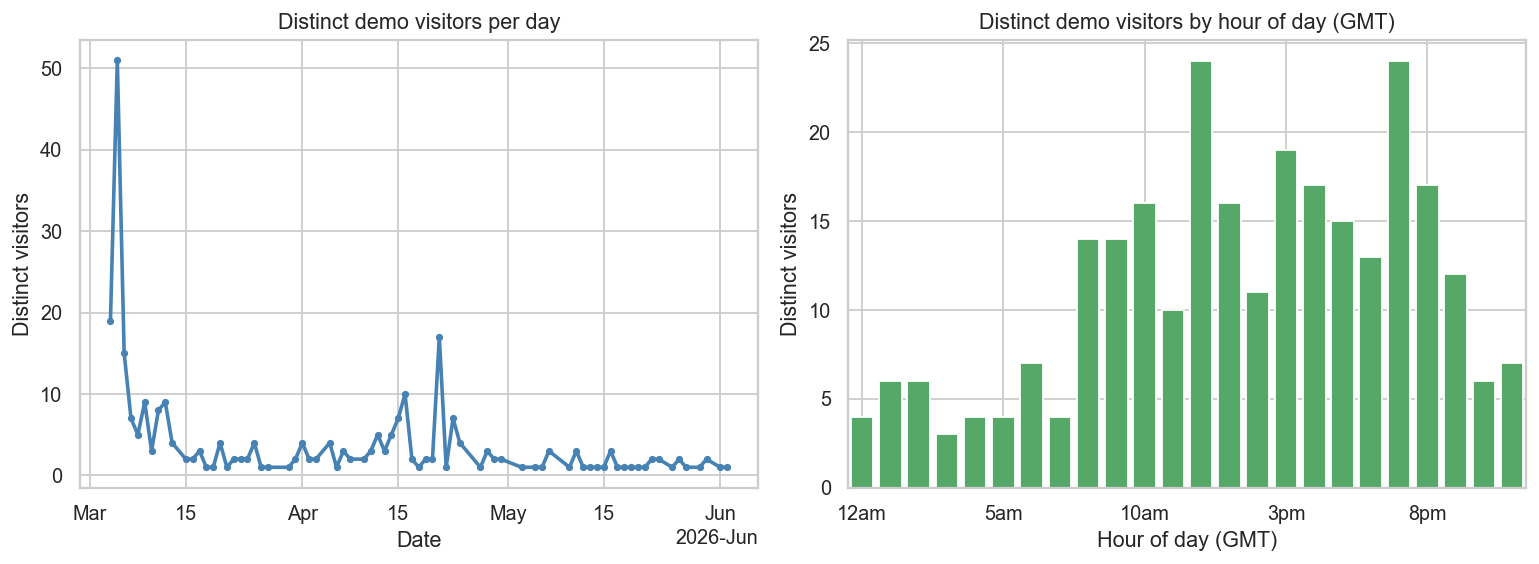

In [5]:
if "PROJECT_NAMES" not in globals():
    PROJECT_NAMES = {
        "577b1f02-315d-4640-acf5-2273343a1384": "Insurance Claims Portfolio Triage",
        "1eeb342a-514e-47f1-a57f-edb5506b02bd": "Investment Diligence",
        "15f2c26a-42fd-4bb1-9a3b-5c9f14a3c778": "Mortgage Underwriting Automation",
        "2f34fe84-d961-420c-8fc1-6d34922bf163": "Property Insurance Risk Analysis",
        "bbb2aba6-5194-4dd0-a371-c321829c047e": "Reinsurance Recovery Optimization",
        "d522a363-1062-4320-b543-6040a9a9785b": "Unknown demo project",
    }

if "project_id" not in demo_events.columns:
    demo_events["project_id"] = demo_events["pathname"].str.extract(
        r"/projects/([0-9a-f]{8}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{12})"
    )

if "project_name" not in demo_events.columns:
    demo_events["project_name"] = demo_events["project_id"].map(PROJECT_NAMES).fillna("No project")

demo_events["hour"] = demo_events["event_timestamp"].dt.hour
demo_events["date"] = demo_events["event_timestamp"].dt.floor("D")

daily = (
    demo_events.groupby("date")
    .agg(
        distinct_visitors=("distinct_id", "nunique"),
        sessions=("session_id", "nunique"),
        events=("event", "count"),
    )
    .reset_index()
)
display(daily)

project_daily = (
    demo_events.loc[demo_events["project_name"] != "No project"]
    .groupby(["date", "project_name"])
    .agg(distinct_visitors=("distinct_id", "nunique"), sessions=("session_id", "nunique"), events=("event", "count"))
    .reset_index()
)
display(project_daily)

hourly = (
    demo_events.groupby("hour")
    .agg(distinct_visitors=("distinct_id", "nunique"))
    .reset_index()
)
hour_ticks = [0, 5, 10, 15, 20]
hour_labels = ["12am", "5am", "10am", "3pm", "8pm"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(daily["date"], daily["distinct_visitors"], color="steelblue", linewidth=2, marker="o", markersize=3)
axes[0].set_title("Distinct demo visitors per day")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Distinct visitors")
locator = mdates.AutoDateLocator()
axes[0].xaxis.set_major_locator(locator)
axes[0].xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

axes[1].bar(hourly["hour"], hourly["distinct_visitors"], color="#55A868")
axes[1].set_title("Distinct demo visitors by hour of day (GMT)")
axes[1].set_xlabel("Hour of day (GMT)")
axes[1].set_ylabel("Distinct visitors")
axes[1].set_xticks(hour_ticks)
axes[1].set_xticklabels(hour_labels)
axes[1].set_xlim(-0.5, 23.5)

fig.tight_layout()
fig.savefig(FIG_DIR / "12_time_activity.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Visitor growth & repeat visits

This section focuses on the visitor base itself: when new distinct visitors first appear in the event stream and how often prospects come back for additional sessions. The `persons` sheet in the June 2 export stops in mid-March, so visitor-growth timing is derived from each `distinct_id`'s first observed event instead of `persons.created_at`.


,first_seen_date,new_distinct_visitors
0,2026-03-04 00:00:00+00:00,19
1,2026-03-05 00:00:00+00:00,48
2,2026-03-06 00:00:00+00:00,13
3,2026-03-07 00:00:00+00:00,6
4,2026-03-08 00:00:00+00:00,2
5,2026-03-09 00:00:00+00:00,8
6,2026-03-10 00:00:00+00:00,3
7,2026-03-11 00:00:00+00:00,7
8,2026-03-12 00:00:00+00:00,7
9,2026-03-13 00:00:00+00:00,3


'**Key finding:** New distinct demo visitors first appear through **2026-05-30** when measured from the event stream. The `persons.created_at` range only runs through **2026-03-12**, while events continue through **2026-06-02**. That means the `persons` sheet misses **82 days** of later visitor arrivals and should not be used for visitor-growth timing in this export.'

,first_seen_date,new_non_direct_visitors
0,2026-03-05 00:00:00+00:00,30
1,2026-03-06 00:00:00+00:00,6
2,2026-03-07 00:00:00+00:00,4
3,2026-03-08 00:00:00+00:00,1
4,2026-03-09 00:00:00+00:00,1
5,2026-03-10 00:00:00+00:00,2
6,2026-03-11 00:00:00+00:00,5
7,2026-03-12 00:00:00+00:00,2
8,2026-03-13 00:00:00+00:00,1
9,2026-03-20 00:00:00+00:00,2


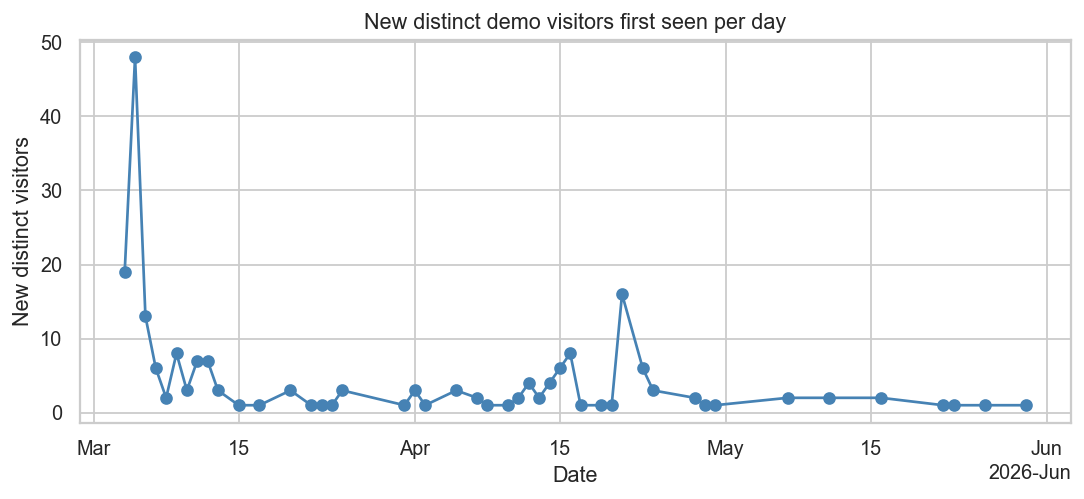

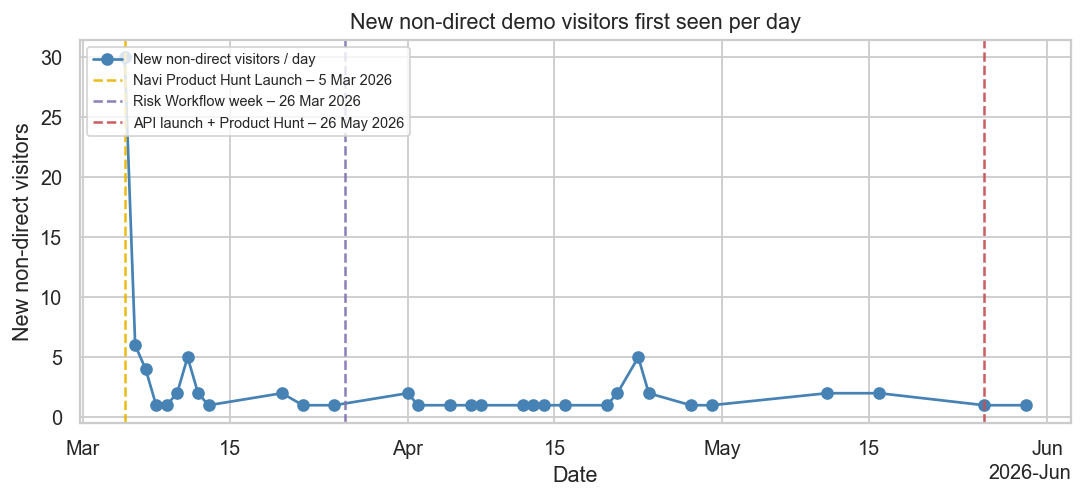

In [6]:
first_seen_visitors = (
    demo_events.groupby("distinct_id")["event_timestamp"]
    .min()
    .dt.floor("D")
    .rename("first_seen_date")
    .reset_index()
)

new_visitors_daily = (
    first_seen_visitors.groupby("first_seen_date")
    .size()
    .reset_index(name="new_distinct_visitors")
)
display(new_visitors_daily)

visitor_profile_end = demo_profiles["created_at"].max().floor("D")
first_seen_end = first_seen_visitors["first_seen_date"].max()
event_end = demo_events["event_timestamp"].max().floor("D")
days_after_profile_end = int((event_end - visitor_profile_end).days)

display(
    Markdown(
        f"**Key finding:** New distinct demo visitors first appear through **{first_seen_end.date()}** when measured from the event stream. The `persons.created_at` range only runs through **{visitor_profile_end.date()}**, while events continue through **{event_end.date()}**. That means the `persons` sheet misses **{days_after_profile_end} days** of later visitor arrivals and should not be used for visitor-growth timing in this export."
    )
)

session_source_clean = demo_sessions["entry_referring_domain"].fillna("Unknown").replace("", "Unknown")
session_source_clean = session_source_clean.replace(
    {"$direct": "Direct", "www.linkedin.com": "LinkedIn", "com.linkedin.android": "LinkedIn"}
)

first_session_sources = (
    demo_sessions.assign(traffic_source=session_source_clean)
    .sort_values(["distinct_id", "start_timestamp"])
    .drop_duplicates(subset=["distinct_id"], keep="first")[["distinct_id", "traffic_source"]]
)

non_direct_first_seen = first_seen_visitors.merge(first_session_sources, on="distinct_id", how="left")
non_direct_first_seen = non_direct_first_seen.loc[
    non_direct_first_seen["traffic_source"].fillna("Unknown") != "Direct"
]
non_direct_new_visitors_daily = (
    non_direct_first_seen.groupby("first_seen_date")
    .size()
    .reset_index(name="new_non_direct_visitors")
)
display(non_direct_new_visitors_daily)

social_media_milestones = [
    (pd.Timestamp("2026-03-05", tz="UTC"), "Parsewise Product Hunt Launch – 5 Mar 2026",  "#E8B400"),
    (pd.Timestamp("2026-03-26", tz="UTC"), "Risk Workflow week – 26 Mar 2026",        "#8172B2"),
    (pd.Timestamp("2026-05-26", tz="UTC"), "API launch + Product Hunt – 26 May 2026", "#C44E52"),
]

fig, ax = plt.subplots(figsize=(8.5, 4))
ax.plot(
    new_visitors_daily["first_seen_date"],
    new_visitors_daily["new_distinct_visitors"],
    marker="o",
    color="steelblue",
)
ax.set_title("New distinct demo visitors first seen per day")
ax.set_xlabel("Date")
ax.set_ylabel("New distinct visitors")
locator = mdates.AutoDateLocator()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
fig.tight_layout()
fig.savefig(FIG_DIR / "07_new_distinct_visitors_first_seen_per_day.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8.5, 4))
ax.plot(
    non_direct_new_visitors_daily["first_seen_date"],
    non_direct_new_visitors_daily["new_non_direct_visitors"],
    marker="o",
    color="steelblue",
    label="New non-direct visitors / day",
)
ax.set_title("New non-direct demo visitors first seen per day")
ax.set_xlabel("Date")
ax.set_ylabel("New non-direct visitors")

for when, label, color in social_media_milestones:       # social-media / launch markers
    if non_direct_new_visitors_daily["first_seen_date"].min() <= when <= non_direct_new_visitors_daily["first_seen_date"].max():
        ax.axvline(when, color=color, linestyle="--", linewidth=1.4, alpha=0.9, label=label)
ax.legend(fontsize=8, loc="upper left")

locator = mdates.AutoDateLocator()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
fig.tight_layout()
fig.savefig(FIG_DIR / "07d_new_non_direct_visitors_first_seen_per_day.png", dpi=150, bbox_inches="tight")
plt.show()


,Sessions,Prospects,% of prospects
0,1,186,90.7
1,2,10,4.9
2,3,5,2.4
3,5,2,1.0
4,7,1,0.5
5,141,1,0.5


,Group,Prospects
0,Single-session prospects,186
1,Multi-session prospects,19


'**Outlier note:** 1 prospects had more than 10 sessions. The highest observed value was 141 sessions.'

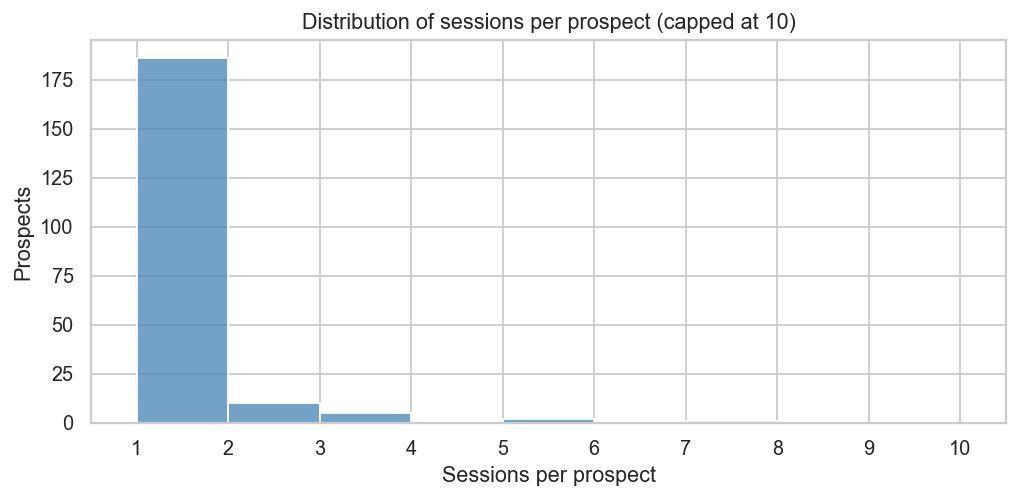

In [7]:
sessions_per_prospect = (
    demo_sessions.groupby("distinct_id")
    .size()
    .rename("sessions")
    .reset_index()
)
session_distribution = (
    sessions_per_prospect["sessions"]
    .value_counts()
    .sort_index()
    .rename_axis("Sessions")
    .reset_index(name="Prospects")
)
session_distribution["% of prospects"] = (
    session_distribution["Prospects"] / session_distribution["Prospects"].sum() * 100
).round(1)
display(session_distribution)

single_vs_multi = pd.DataFrame(
    {
        "Group": ["Single-session prospects", "Multi-session prospects"],
        "Prospects": [
            int((sessions_per_prospect["sessions"] == 1).sum()),
            int((sessions_per_prospect["sessions"] > 1).sum()),
        ],
    }
)
display(single_vs_multi)

session_cap = 10
sessions_capped = sessions_per_prospect.loc[
    sessions_per_prospect["sessions"] <= session_cap, "sessions"
]
outlier_count = int((sessions_per_prospect["sessions"] > session_cap).sum())
max_sessions = int(sessions_per_prospect["sessions"].max())

display(
    Markdown(
        f"**Outlier note:** {outlier_count} prospects had more than {session_cap} sessions. "
        f"The highest observed value was {max_sessions} sessions."
    )
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(
    sessions_capped,
    discrete=True,
    binwidth=1,
    binrange=(0.5, session_cap + 0.5),
    ax=ax,
    color="steelblue",
)
ax.set_title("Distribution of sessions per prospect (capped at 10)")
ax.set_xlabel("Sessions per prospect")
ax.set_ylabel("Prospects")
ax.set_xlim(0.5, session_cap + 0.5)
ax.set_xticks(range(1, session_cap + 1))
fig.tight_layout()
fig.savefig(FIG_DIR / "08_sessions_per_prospect.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Traffic sources to demo

The June 2 export no longer includes a precomputed `channel_type` field in the sessions sheet, so this section uses `entry_referring_domain` as the available session-level traffic-source proxy. That keeps the acquisition view descriptive without pretending the workbook still contains a separate channel bucket.


,traffic_source,sessions,visitors,% sessions
0,Direct,264,125,69.7
1,www.producthunt.com,50,45,13.2
2,LinkedIn,32,23,8.4
3,www.parsewise.ai,19,9,5.0
4,www.google.com,8,4,2.1
5,t.co,6,6,1.6


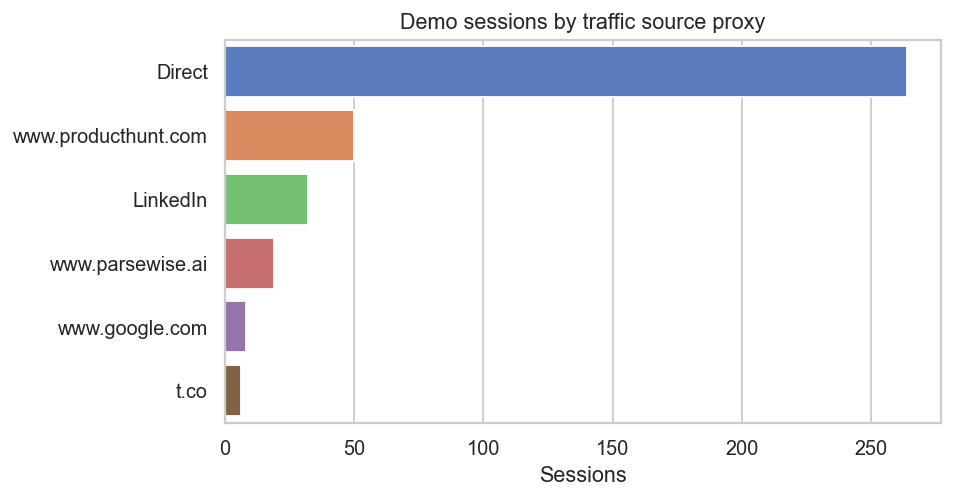

In [8]:
referring_domain_clean = demo_sessions["entry_referring_domain"].fillna("Unknown").replace("", "Unknown")
referring_domain_clean = referring_domain_clean.replace(
    {"$direct": "Direct", "www.linkedin.com": "LinkedIn", "com.linkedin.android": "LinkedIn"}
)

sources = (
    demo_sessions.assign(traffic_source=referring_domain_clean)
    .groupby("traffic_source")
    .agg(sessions=("session_id", "count"), visitors=("distinct_id", "nunique"))
    .sort_values("sessions", ascending=False)
    .reset_index()
)
sources["% sessions"] = (sources["sessions"] / sources["sessions"].sum() * 100).round(1)
display(sources)

fig, ax = plt.subplots(figsize=(7.5, 4))

sns.barplot(data=sources.head(6), x="sessions", y="traffic_source", hue="traffic_source", legend=False, ax=ax)
ax.set_title("Demo sessions by traffic source proxy")
ax.set_xlabel("Sessions")
ax.set_ylabel("")

fig.tight_layout()
fig.savefig(FIG_DIR / "02_demo_sources.png", dpi=150, bbox_inches="tight")
plt.show()


### Traffic sources over time

Splitting the demo's weekly prospect inflow by traffic-source proxy, with the social posting/launch dates annotated, shows which channel delivered the demo's audience — and how completely that inflow stopped after mid-March.

In [ ]:
# ── Weekly distinct prospects by traffic source, with posting / launch dates ──
from matplotlib.lines import Line2D
import numpy as np

def source_group(d):
    if pd.isna(d) or str(d).strip().lower() in ("", "$direct", "nan", "direct"): return "Direct"
    d = str(d).strip().lower().replace("www.", "")
    if "google" in d: return "Google"
    if "linkedin" in d or d.startswith("lnkd"): return "LinkedIn"
    if "producthunt" in d: return "Product Hunt"
    if d in ("t.co", "x.co", "x.com") or "twitter" in d: return "X.com"
    if "ycombinator" in d: return "Y Combinator"
    return "Other"

SRC_COL = {"Direct": "#1f77b4", "Google": "#ff7f0e", "LinkedIn": "#d62728", "Product Hunt": "#2ca02c",
           "X.com": "#8c564b", "Y Combinator": "#9467bd", "Other": "#7f7f7f"}
SRC_ORDER = ["Direct", "Google", "LinkedIn", "Product Hunt", "X.com", "Y Combinator", "Other"]
milestones_src = [
    (pd.Timestamp("2026-02-26"), "26 Feb: LinkedIn launch", "#2CA02C"),
    (pd.Timestamp("2026-03-05"), "5 Mar: Parsewise Product Hunt launch", "#E8B400"),
    (pd.Timestamp("2026-03-26"), "26 Mar: Risk Workflow week", "#8172B2"),
    (pd.Timestamp("2026-05-26"), "26 May: API + Product Hunt", "#C44E52"),
]

_d = demo_sessions.copy()
_d["source"] = _d["entry_referring_domain"].map(source_group)
_d["week"] = _d["start_timestamp"].dt.tz_localize(None).dt.to_period("W").dt.start_time
wk_src = (_d.groupby(["week", "source"])["distinct_id"].nunique()
          .unstack(fill_value=0)
          .reindex(columns=[s for s in SRC_ORDER if s in _d["source"].unique()]))

fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(wk_src))
for s in wk_src.columns:
    ax.bar(wk_src.index, wk_src[s], width=5.2, bottom=bottom, label=s, color=SRC_COL.get(s, "#999"))
    bottom += wk_src[s].values
for when, _lab, c in milestones_src:
    ax.axvline(when, color=c, ls="--", lw=1.2, zorder=5)

ax.set_title("Demo: weekly distinct prospects by traffic-source proxy")
ax.set_ylabel("Distinct prospects per week")
ax.set_xlabel("Week")
ax.margins(x=0.01)
_loc = mdates.AutoDateLocator(); ax.xaxis.set_major_locator(_loc); ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(_loc))

_src_h = [Line2D([0], [0], color=SRC_COL[s], lw=6, label=s) for s in wk_src.columns]
_mile_h = [Line2D([0], [0], color=c, ls="--", lw=1.2, label=lab) for _, lab, c in milestones_src]
_box = dict(frameon=True, edgecolor="0.6", facecolor="white", framealpha=1)
_leg1 = ax.legend(handles=_src_h, title="Traffic source", fontsize=8, title_fontsize=8.5,
                  loc="upper left", bbox_to_anchor=(1.01, 1.0), alignment="left", **_box)
ax.add_artist(_leg1)
ax.legend(handles=_mile_h, title="Posting / launch dates", fontsize=8, title_fontsize=8.5,
          loc="upper left", bbox_to_anchor=(1.01, 0.5), alignment="left", **_box)
fig.tight_layout()
fig.savefig(FIG_DIR / "02b_demo_source_over_time.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Prospect profile (`persons` sheet)


,Country,Prospects
0,Unknown,105


,Device,Prospects,% of prospects
0,Unknown,105,100.0


,Browser,Prospects
0,Unknown,105


Visitors with any UTM data: 0 / 105 (0%)
(Most demo traffic is not UTM-tagged, so much of it appears as Direct or Referral.)


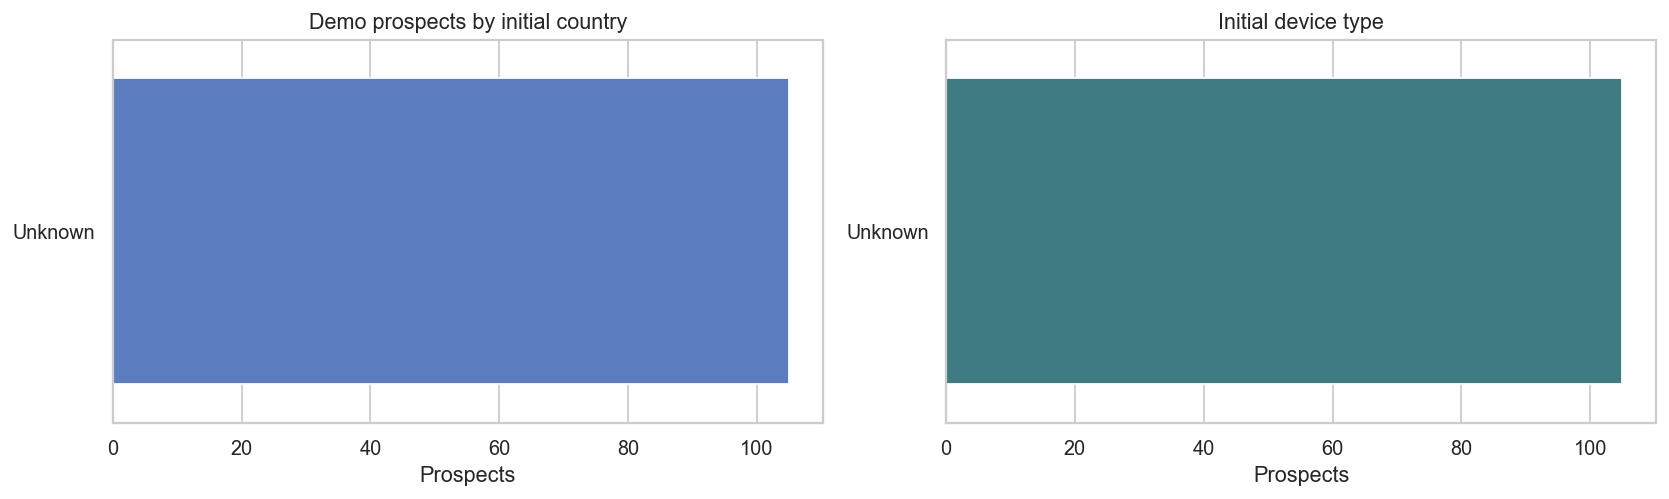

In [9]:
countries = demo_profiles["initial_country"].fillna("Unknown").value_counts().head(10).reset_index()
countries.columns = ["Country", "Prospects"]
display(countries)

devices = demo_profiles["initial_device_type"].fillna("Unknown").value_counts().reset_index()
devices.columns = ["Device", "Prospects"]
devices["% of prospects"] = (devices["Prospects"] / devices["Prospects"].sum() * 100).round(1)
display(devices)

browsers = demo_profiles["initial_browser"].fillna("Unknown").value_counts().head(6).reset_index()
browsers.columns = ["Browser", "Prospects"]
display(browsers)

utm_any = demo_profiles[["utm_source", "utm_medium", "utm_campaign"]].replace("", pd.NA).notna().any(axis=1)
print(
    f"Visitors with any UTM data: {utm_any.sum()} / {len(demo_profiles)} "
    f"({utm_any.mean() * 100:.0f}%)"
)
print("(Most demo traffic is not UTM-tagged, so much of it appears as Direct or Referral.)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(data=countries, x="Prospects", y="Country", hue="Country", legend=False, ax=axes[0])
axes[0].set_title("Demo prospects by initial country")
axes[0].set_xlabel("Prospects")
axes[0].set_ylabel("")

sns.barplot(data=devices, x="Prospects", y="Device", hue="Device", legend=False, ax=axes[1], palette="crest")
axes[1].set_title("Initial device type")
axes[1].set_xlabel("Prospects")
axes[1].set_ylabel("")

fig.tight_layout()
fig.savefig(FIG_DIR / "03_persons_profile.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Device & geography

The `device, browser, geography` sheet covers the full external-prospect activity window in this export, not a short slice. The tables below split each dimension cleanly so the values remain readable.


In [10]:
demo_geo = demo_geo.copy()
demo_geo["event_timestamp"] = pd.to_datetime(
    demo_geo["event_timestamp"], utc=True, format="mixed", errors="coerce"
)

geo_country = demo_geo["country"].fillna("Unknown").value_counts().reset_index()
geo_country.columns = ["Country", "Events"]
geo_device = demo_geo["device_type"].fillna("Unknown").value_counts().reset_index()
geo_device.columns = ["Device type", "Events"]
geo_browser = demo_geo["browser"].fillna("Unknown").value_counts().reset_index()
geo_browser.columns = ["Browser", "Events"]
geo_os = demo_geo["os"].fillna("Unknown").value_counts().reset_index()
geo_os.columns = ["Operating system", "Events"]

print("Country")
display(geo_country)
print("Device type")
display(geo_device)
print("Browser")
display(geo_browser)
print("Operating system")
display(geo_os)

geo_time = demo_geo["event_timestamp"].dropna()
if len(geo_time) > 0:
    span_days = int((geo_time.max().floor("D") - geo_time.min().floor("D")).days)
    print(
        f"Geo/device rows span {geo_time.min().date()} to {geo_time.max().date()} "
        f"({span_days} days)."
    )
else:
    print("Geo/device timestamps are unavailable after coercion.")


Country


,Country,Events
0,United Kingdom,2725
1,Germany,1740
2,United States,958
3,Austria,249
4,Canada,202
5,The Netherlands,182
6,Switzerland,147
7,France,140
8,Panama,123
9,Romania,108


Device type


,Device type,Events
0,Desktop,6402
1,Mobile,567
2,Tablet,51


Browser


,Browser,Events
0,Chrome,6262
1,Opera,214
2,Safari,202
3,Mobile Safari,138
4,Microsoft Edge,109
5,Firefox,61
6,Chrome iOS,19
7,Unknown,13
8,Samsung Internet,2


Operating system


,Operating system,Events
0,Mac OS X,5710
1,Windows,581
2,Android,461
3,iOS,157
4,Linux,98
5,Unknown,13


Geo/device rows span 2026-03-04 to 2026-06-02 (90 days).


## 7. Demo page structure

The area summaries below use `$pageview` and other event counts only to describe where activity happened. They do not imply progression or completion.


In [11]:

if "simplify_demo_path" not in globals():
    def simplify_demo_path(path):
        path = "" if pd.isna(path) else str(path).strip()
        path = path.split("?", 1)[0].split("#", 1)[0]
        if path in {"", "nan", "None"}:
            return ""
        if path != "/":
            path = re.sub(r"/+$", "", path)
        path = re.sub(r"/projects/([0-9a-f\-]+)/nav$", r"/projects/\1/navi", path)
        path = re.sub(
            r"/projects/[0-9a-f\-]+/documents/[0-9a-f\-]+$",
            "/projects/{id}/documents/{doc_id}",
            path,
        )
        path = re.sub(r"/projects/[0-9a-f\-]+/documents$", "/projects/{id}/documents", path)
        path = re.sub(
            r"/projects/[0-9a-f\-]+/agents/[0-9a-f\-]+/[0-9a-f\-]+$",
            "/projects/{id}/agents/{agent_id}/{run_id}",
            path,
        )
        path = re.sub(
            r"/projects/[0-9a-f\-]+/agents/[0-9a-f\-]+$",
            "/projects/{id}/agents/{agent_id}",
            path,
        )
        path = re.sub(r"/projects/[0-9a-f\-]+/agents$", "/projects/{id}/agents", path)
        path = re.sub(
            r"/projects/[0-9a-f\-]+/results/[0-9a-f\-]+$",
            "/projects/{id}/results/{result_id}",
            path,
        )
        path = re.sub(r"/projects/[0-9a-f\-]+/results$", "/projects/{id}/results", path)
        path = re.sub(r"/projects/[0-9a-f\-]+/navi$", "/projects/{id}/navi", path)
        path = re.sub(r"/projects/[0-9a-f\-]+$", "/projects/{id}", path)
        return path

if "page_type" not in demo_events.columns:
    demo_events["page_type"] = demo_events["pathname"].apply(simplify_demo_path)

if "project_id" not in demo_events.columns:
    demo_events["project_id"] = demo_events["pathname"].str.extract(
        r"/projects/([0-9a-f]{8}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{12})"
    )

PROJECT_NAMES = {
    "577b1f02-315d-4640-acf5-2273343a1384": "Insurance Claims Portfolio Triage",
    "1eeb342a-514e-47f1-a57f-edb5506b02bd": "Investment Diligence",
    "15f2c26a-42fd-4bb1-9a3b-5c9f14a3c778": "Mortgage Underwriting Automation",
    "2f34fe84-d961-420c-8fc1-6d34922bf163": "Property Insurance Risk Analysis",
    "bbb2aba6-5194-4dd0-a371-c321829c047e": "Reinsurance Recovery Optimization",
    "d522a363-1062-4320-b543-6040a9a9785b": "Unknown demo project",
}

PROJECT_VERTICALS = {
    "Insurance Claims Portfolio Triage": "Insurance",
    "Investment Diligence": "Investment",
    "Mortgage Underwriting Automation": "Regulatory / Mortgage",
    "Property Insurance Risk Analysis": "Insurance",
    "Reinsurance Recovery Optimization": "Insurance",
    "Unknown demo project": "Unknown",
}

if "project_name" not in demo_events.columns:
    demo_events["project_name"] = demo_events["project_id"].map(PROJECT_NAMES).fillna("No project")

if "demo_vertical" not in demo_events.columns:
    demo_events["demo_vertical"] = demo_events["project_name"].map(PROJECT_VERTICALS).fillna("N/A")

page_types = demo_events["page_type"].value_counts().reset_index()
page_types.columns = ["Page type", "Events"]
page_types["% of events"] = (page_types["Events"] / page_types["Events"].sum() * 100).round(1)

DEMO_AREA_MAP = {
    "/projects/{id}/navi": "Navi (AI agent)",
    "/projects/{id}/results": "Results",
    "/projects/{id}/results/{result_id}": "Result detail",
    "/projects/{id}/agents": "Agents",
    "/projects/{id}/agents/{agent_id}/{run_id}": "Agent run detail",
    "/projects/{id}/agents/{agent_id}": "Agent detail",
    "/projects": "Project list",
    "/projects/{id}/documents": "Documents",
    "/projects/{id}/documents/{doc_id}": "Document detail",
    "/projects/{id}": "Project overview",
}
page_types["Area"] = page_types["Page type"].map(DEMO_AREA_MAP).fillna("Other")
display(page_types)

by_project = (
    demo_events.loc[demo_events["project_name"] != "No project"]
    .groupby("project_name")
    .agg(events=("event", "count"), visitors=("distinct_id", "nunique"))
    .sort_values("events", ascending=False)
    .reset_index()
)
by_project["demo_vertical"] = by_project["project_name"].map(PROJECT_VERTICALS)
display(by_project)

by_vertical = (
    demo_events.loc[demo_events["demo_vertical"].isin(["Insurance", "Investment", "Regulatory / Mortgage"])]
    .groupby("demo_vertical")
    .agg(events=("event", "count"), visitors=("distinct_id", "nunique"))
    .sort_values("events", ascending=False)
    .reset_index()
)
display(by_vertical)

area_events = demo_events.assign(Area=demo_events["page_type"].map(DEMO_AREA_MAP).fillna("Other")).copy()
area_time = (
    area_events[["session_id", "event_timestamp", "Area"]]
    .merge(demo_sessions[["session_id", "end_timestamp"]].drop_duplicates(), on="session_id", how="left")
    .sort_values(["session_id", "event_timestamp"])
)
area_time["next_timestamp"] = area_time.groupby("session_id")["event_timestamp"].shift(-1)
area_time["segment_end"] = area_time["next_timestamp"].fillna(area_time["end_timestamp"])
area_time["estimated_seconds"] = (
    area_time["segment_end"] - area_time["event_timestamp"]
).dt.total_seconds()
area_time = area_time.loc[area_time["estimated_seconds"] > 0].copy()
area_time["estimated_seconds_capped"] = area_time["estimated_seconds"].clip(upper=300)
area_time_summary = (
    area_time.groupby("Area")["estimated_seconds_capped"]
    .sum()
    .sort_values(ascending=False)
    .reset_index(name="Estimated seconds")
)
area_time_summary["Estimated minutes"] = (area_time_summary["Estimated seconds"] / 60).round(1)
display(area_time_summary)


,Page type,Events,% of events,Area
0,/projects/{id}/navi,2701,41.0,Navi (AI agent)
1,/projects/{id}/results,1235,18.7,Results
2,/projects/{id}/agents,1169,17.7,Agents
3,/projects/{id}/documents,737,11.2,Documents
4,/projects/{id}/agents/{agent_id}/{run_id},421,6.4,Agent run detail
5,/projects/{id}/documents/{doc_id},300,4.6,Document detail
6,/projects/{id}/agents/{agent_id},27,0.4,Agent detail


,project_name,events,visitors,demo_vertical
0,Insurance Claims Portfolio Triage,1989,76,Insurance
1,Mortgage Underwriting Automation,1695,69,Regulatory / Mortgage
2,Investment Diligence,1552,59,Investment
3,Property Insurance Risk Analysis,593,10,Insurance
4,Reinsurance Recovery Optimization,374,29,Insurance


,demo_vertical,events,visitors
0,Insurance,2956,104
1,Regulatory / Mortgage,1695,69
2,Investment,1552,59


,Area,Estimated seconds,Estimated minutes
0,Navi (AI agent),34431.632,573.9
1,Agents,9133.229,152.2
2,Results,7910.899,131.8
3,Documents,5919.812,98.7
4,Agent run detail,5913.329,98.6
5,Document detail,2521.356,42.0
6,Agent detail,379.495,6.3


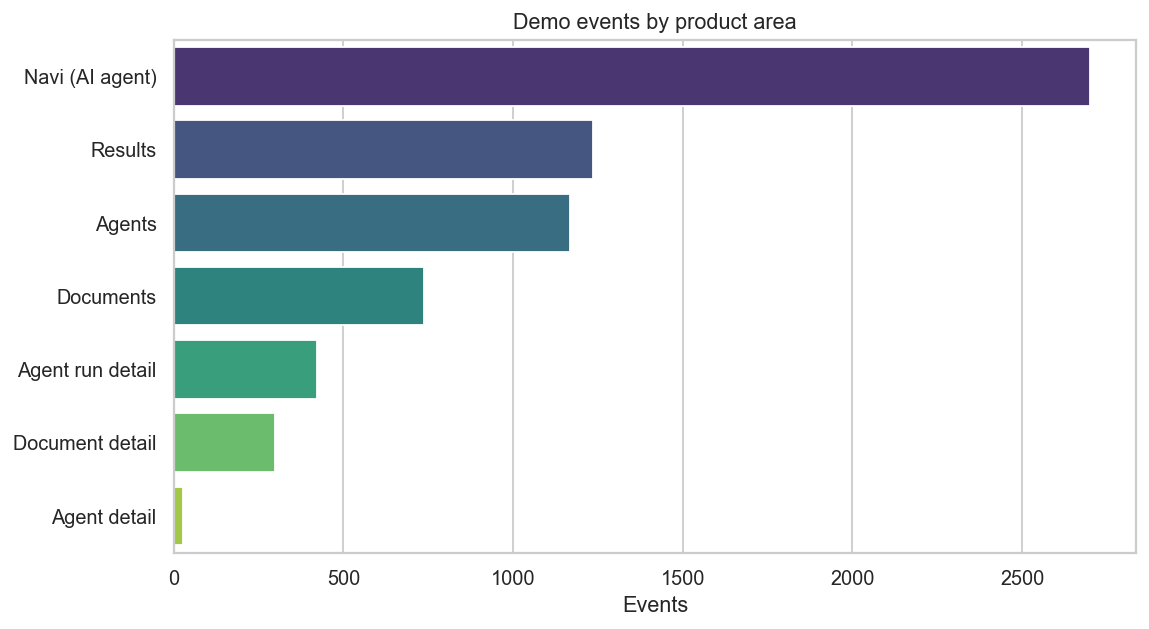

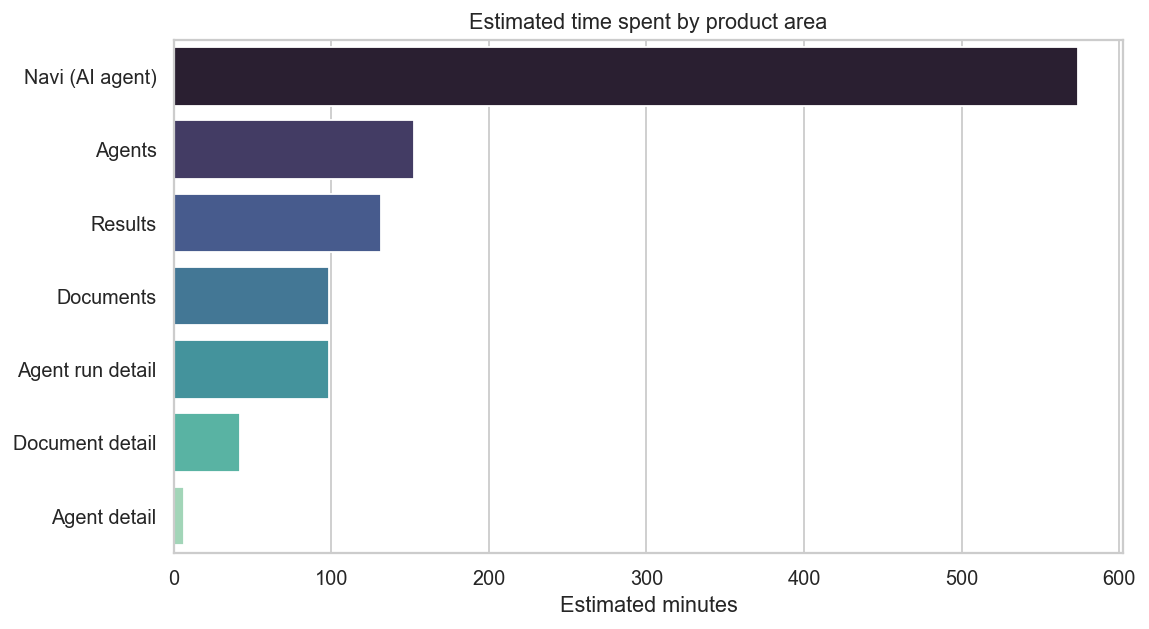

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=page_types, x="Events", y="Area", hue="Area", legend=False, ax=ax, palette="viridis")
ax.set_title("Demo events by product area")
ax.set_xlabel("Events")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_demo_areas.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=area_time_summary,
    x="Estimated minutes",
    y="Area",
    hue="Area",
    legend=False,
    ax=ax,
    palette="mako",
)
ax.set_title("Estimated time spent by product area")
ax.set_xlabel("Estimated minutes")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(FIG_DIR / "01b_demo_area_time.png", dpi=150, bbox_inches="tight")
plt.show()


- **What counts as an event in the chart above:** it counts **all raw event rows** in `event_master`, grouped by the page area they happened on. In this export, those event types are **`$pageview`**, **`$autocapture`**, **`$set`**, **`$identify`**, **`$rageclick`**, and **`$groupidentify`**. So the event chart reflects total tracked activity volume, not just page loads or just clicks.
- **Navi landing-page share:** **47.2%** of all recorded `Navi (AI agent)` events in this export happened inside sessions where `Navi` was the landing page. In count terms, that is **1,348 of 2,853 Navi events**. This means nearly half of observed Navi activity is tied to users being dropped straight into the AI-agent view, rather than navigating there later in the session.
- **How the time chart is estimated:** the time-based version uses the gap between one event and the next event in the same session, attributing that interval to the current product area. The final event in a session uses the session `end_timestamp`, and each interval is capped at **300 seconds** so very long idle gaps do not dominate the chart. This should be read as an **estimated time spent** view, not an exact stopwatch measure.


- **What happened to `Other`:** the cleaned analysis now excludes the non-core and broken routes that previously sat inside `Other`, such as `/support`, `/subscription`, `/billing`, `/admin`, `/developer`, `/login-in-demo`, along with the routed entry pages `/projects` and `/projects/{id}`, and the remaining irregular unmapped paths.
- **What was kept instead of excluded:** project-specific `Navi` variants such as `/projects/{id}/nav` and `/projects/{id}/navi?chat=...` are now normalised into the main `Navi (AI agent)` bucket rather than being left in `Other`.
- **How to read this:** `Other`, `Project list`, and `Project overview` should no longer drive the main demo-usage charts. The cleaned area charts now focus on deeper core demo product routes only.


- **What is inside `Project overview` (107 events):** this bucket is only the canonical project root route, simplified to **`/projects/{id}`**.
- **What that means:** these are visits to a demo project's landing page before the user moves into deeper areas such as `Navi`, `Documents`, `Agents`, or `Results`. There are no extra hidden routes inside this bucket in the current export.


## 8. Session detail

The original session-by-session bar chart became unreadable at this session count. This section now uses percentile-aware distributions and a pageviews-vs-clicks scatter so the typical sessions remain visible instead of being flattened by a handful of very large outliers.


,Start (UTC),Duration (s),Pageviews,Clicks,Entry page,Exit page,Bounce
0,2026-03-04 15:09,14069.189,287,325,/projects/{id}/navi,/projects/{id}/navi,0
1,2026-03-04 16:27,17.025,11,10,/projects/{id}/navi,/projects/{id}/documents,0
2,2026-03-04 16:34,33.577,11,9,/projects/{id}/navi,/projects/{id}/navi,0
3,2026-03-04 17:27,125.603,11,27,/projects/{id}/navi,/projects/{id}/navi,0
4,2026-03-04 17:31,1418.774,12,4,/projects/{id}/navi,/projects/{id}/navi,0
...,...,...,...,...,...,...,...
374,2026-05-30 18:07,486.167,5,26,/projects/{id}/navi,/projects/{id}/agents,0
375,2026-05-30 21:23,16.973,6,5,/projects/{id}/navi,/projects/{id}/agents/{agent_id}/{run_id},0
376,2026-06-01 22:06,0.062,1,0,/projects/{id}/navi,/projects/{id}/navi,0
377,2026-06-02 09:38,12.258,3,1,/projects/{id}/navi,/projects/{id}/documents,0


Total time on demo: 111062s (1851.0 min)
Mean session: 293s
Median session: 19s
Longest session: 14069s


,Start (UTC),Duration (s),Pageviews,Clicks,Entry page,Exit page
0,2026-03-04 15:09,14069.189,287,325,/projects/{id}/navi,/projects/{id}/navi
99,2026-03-08 00:02,6881.373,0,23,/projects/{id}/navi,/projects/{id}/navi
91,2026-03-07 04:14,6453.523,41,31,/projects/{id}/agents/{agent_id}/{run_id},/projects/{id}/agents
174,2026-03-23 13:25,6007.984,97,50,/projects/{id}/navi,/projects/{id}/navi
213,2026-04-05 21:14,4921.048,241,220,/projects/{id}/navi,/projects/{id}/navi
236,2026-04-13 22:21,4698.563,70,74,/projects/{id}/navi,/projects/{id}/documents
274,2026-04-20 21:28,4681.129,143,164,/projects/{id}/navi,/projects/{id}/navi
109,2026-03-09 12:41,3867.715,52,37,/projects/{id}/navi,/projects/{id}/results
97,2026-03-07 19:48,3644.535,13,18,/projects/{id}/agents,/projects/{id}/navi
90,2026-03-07 02:10,3158.908,62,70,/projects/{id}/navi,/projects/{id}/navi


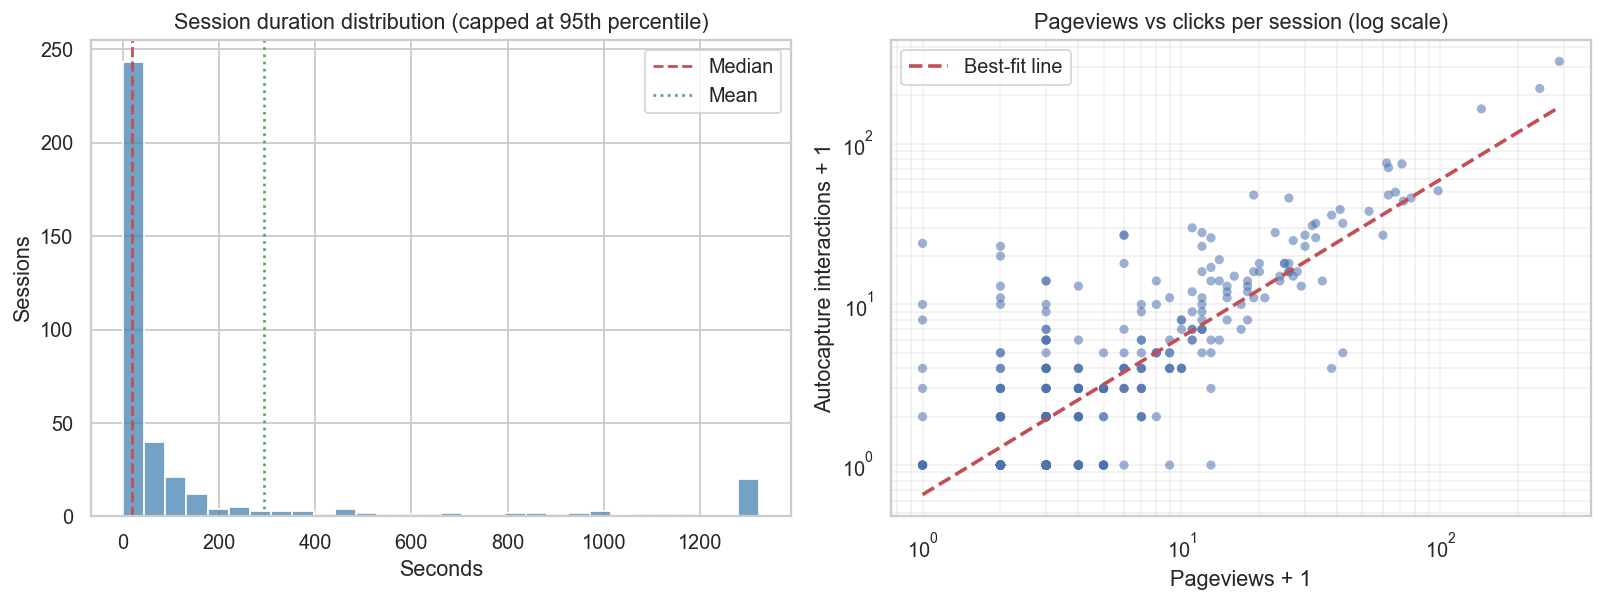

In [13]:
import numpy as np

session_table = demo_sessions[
    [
        "start_timestamp",
        "session_duration_seconds",
        "pageview_count",
        "autocapture_count",
        "entry_pathname",
        "end_pathname",
        "is_bounce",
    ]
].copy()
session_table["start"] = session_table["start_timestamp"].dt.strftime("%Y-%m-%d %H:%M")
session_table["entry"] = session_table["entry_pathname"].apply(simplify_demo_path)
session_table["exit"] = session_table["end_pathname"].apply(simplify_demo_path)
session_table = session_table[
    ["start", "session_duration_seconds", "pageview_count", "autocapture_count", "entry", "exit", "is_bounce"]
]
session_table.columns = ["Start (UTC)", "Duration (s)", "Pageviews", "Clicks", "Entry page", "Exit page", "Bounce"]
display(session_table)

print(f"Total time on demo: {demo_sessions['session_duration_seconds'].sum():.0f}s ({demo_sessions['session_duration_seconds'].sum() / 60:.1f} min)")
print(f"Mean session: {demo_sessions['session_duration_seconds'].mean():.0f}s")
print(f"Median session: {demo_sessions['session_duration_seconds'].median():.0f}s")
print(f"Longest session: {demo_sessions['session_duration_seconds'].max():.0f}s")

session_outliers = (
    demo_sessions[
        [
            "start_timestamp",
            "session_duration_seconds",
            "pageview_count",
            "autocapture_count",
            "entry_pathname",
            "end_pathname",
        ]
    ]
    .sort_values("session_duration_seconds", ascending=False)
    .head(10)
    .copy()
)
session_outliers["start"] = session_outliers["start_timestamp"].dt.strftime("%Y-%m-%d %H:%M")
session_outliers["entry"] = session_outliers["entry_pathname"].apply(simplify_demo_path)
session_outliers["exit"] = session_outliers["end_pathname"].apply(simplify_demo_path)
session_outliers = session_outliers[
    ["start", "session_duration_seconds", "pageview_count", "autocapture_count", "entry", "exit"]
]
session_outliers.columns = ["Start (UTC)", "Duration (s)", "Pageviews", "Clicks", "Entry page", "Exit page"]
display(session_outliers)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))

duration_cap = demo_sessions["session_duration_seconds"].quantile(0.95)
duration_plot = demo_sessions.assign(
    duration_capped=demo_sessions["session_duration_seconds"].clip(upper=duration_cap)
)
sns.histplot(
    duration_plot["duration_capped"].dropna(),
    bins=30,
    ax=axes[0],
    color="steelblue",
)
axes[0].axvline(
    demo_sessions["session_duration_seconds"].median(),
    color="#C44E52",
    linestyle="--",
    linewidth=1.5,
    label="Median",
)
axes[0].axvline(
    demo_sessions["session_duration_seconds"].mean(),
    color="#55A868",
    linestyle=":",
    linewidth=1.5,
    label="Mean",
)
axes[0].set_title("Session duration distribution (capped at 95th percentile)")
axes[0].set_xlabel("Seconds")
axes[0].set_ylabel("Sessions")
axes[0].legend()

scatter_data = demo_sessions.assign(
    pageviews_plus_one=demo_sessions["pageview_count"] + 1,
    clicks_plus_one=demo_sessions["autocapture_count"] + 1,
)
axes[1].scatter(
    scatter_data["pageviews_plus_one"],
    scatter_data["clicks_plus_one"],
    alpha=0.55,
    s=26,
    color="#4C72B0",
    edgecolors="none",
)

log_x = np.log10(scatter_data["pageviews_plus_one"])
log_y = np.log10(scatter_data["clicks_plus_one"])
fit = np.polyfit(log_x, log_y, 1)
fit_x = np.linspace(scatter_data["pageviews_plus_one"].min(), scatter_data["pageviews_plus_one"].max(), 200)
fit_y = 10 ** (fit[0] * np.log10(fit_x) + fit[1])
axes[1].plot(fit_x, fit_y, color="#C44E52", linewidth=2, linestyle="--", label="Best-fit line")

axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Pageviews vs clicks per session (log scale)")
axes[1].set_xlabel("Pageviews + 1")
axes[1].set_ylabel("Autocapture interactions + 1")
axes[1].grid(True, which="both", alpha=0.25)
axes[1].legend()

fig.tight_layout()
fig.savefig(FIG_DIR / "04_sessions.png", dpi=150, bbox_inches="tight")
plt.show()


- The histogram is capped at the 95th percentile of session duration for readability. Sessions above that threshold are still included in the summary statistics and outlier table, but they are not shown in this specific chart.

- **Bounce rate:** **5.7%** of sessions in this export meet the strict bounce definition used here. That is **25 of 436 sessions**, coming from **21 distinct visitors**. In this notebook, a bounce means a session lasted **under 10 seconds**, recorded **exactly one `$pageview`**, and had **no clicks or other recorded events** beyond that single pageview. These very short exits are not limited to the generic `/projects` entry page: some also landed directly on `Navi`, `Documents`, or `Agents` and still left without any additional recorded interaction.

- The pageviews-versus-clicks scatter uses logarithmic axes because session activity spans a very wide range, from very light visits to a small number of much heavier sessions. A log scale keeps those extremes from flattening the rest of the points, so the typical sessions remain visible. The chart shows whether sessions with more pageviews also tend to generate more interactions, and highlights the difference between shallow browsing and deeper, more active exploration.


## 9. Sign-up conversion clicks

In this demo, a click on the sign-up button is the strongest available observable conversion proxy. It shows explicit intent to go beyond read-only exploration, but it does **not** confirm registration completion. This section also attributes those sign-up clicks back to the routed demo they happened inside.


Sign-up conversion clicks: 11
Unique prospects who clicked sign-up: 5 / 207 (2.4%)


,page_type,Clicks
0,/projects/{id}/agents,2
1,/projects/{id}/navi,9


,project_name,sign_up_clicks,sign_up_clickers,project_visitors,sign_up_click_rate_%
0,Insurance Claims Portfolio Triage,7,2,69,2.9
1,Investment Diligence,3,2,49,4.1
2,Mortgage Underwriting Automation,1,1,62,1.6


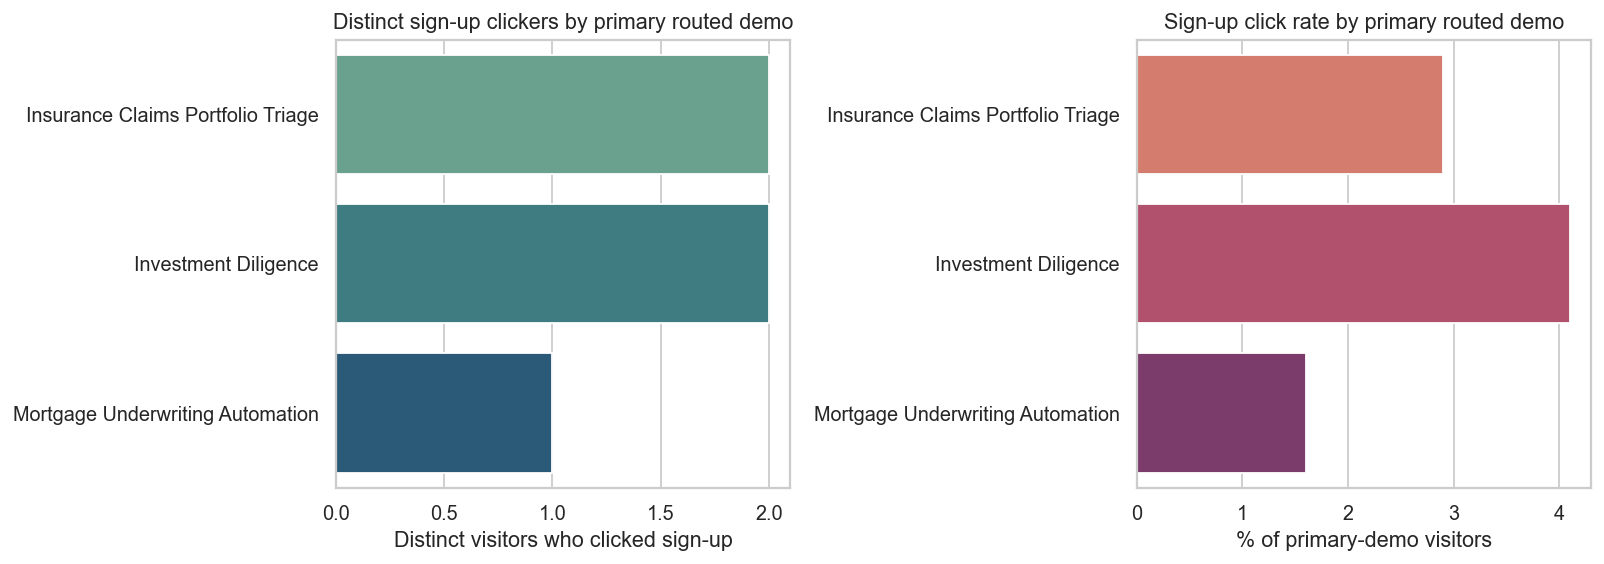

In [14]:

cta_clicks = demo_ac.loc[
    demo_ac["element_text"].isin(["Sign up", "Sign Up"]) & (demo_ac["event_type"] == "click")
].copy()

if "page_type" not in cta_clicks.columns:
    cta_clicks["page_type"] = cta_clicks["pathname"].apply(simplify_demo_path)

if "project_id" not in cta_clicks.columns:
    cta_clicks["project_id"] = cta_clicks["pathname"].str.extract(
        r"/projects/([0-9a-f]{8}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{12})"
    )

if "project_name" not in cta_clicks.columns:
    cta_clicks["project_name"] = cta_clicks["project_id"].map(PROJECT_NAMES).fillna("No project")

cta_clickers = cta_clicks["distinct_id"].nunique()

print(f"Sign-up conversion clicks: {len(cta_clicks)}")
print(
    f"Unique prospects who clicked sign-up: {cta_clickers} / {total_prospects} "
    f"({cta_clickers / total_prospects * 100:.1f}%)"
)

cta_by_page = cta_clicks.groupby("page_type").size().reset_index(name="Clicks")
display(cta_by_page)

# Assign each visitor to exactly one routed demo: the first demo project they were
# seen in. This makes the per-demo sign-up bars mutually exclusive and ensures they
# reconcile with the overall headline of 5 distinct sign-up users.
primary_project_map = (
    demo_events.loc[demo_events["project_name"] != "No project", ["distinct_id", "project_name", "event_timestamp"]]
    .sort_values(["distinct_id", "event_timestamp"])
    .drop_duplicates(subset=["distinct_id"], keep="first")
    .rename(columns={"project_name": "primary_project_name"})
)

project_visitor_base = (
    primary_project_map.groupby("primary_project_name")["distinct_id"]
    .nunique()
    .reset_index(name="project_visitors")
    .rename(columns={"primary_project_name": "project_name"})
)

cta_clicks_with_primary = cta_clicks.merge(
    primary_project_map[["distinct_id", "primary_project_name"]],
    on="distinct_id",
    how="left",
)

cta_by_project = (
    cta_clicks_with_primary.loc[cta_clicks_with_primary["primary_project_name"].notna()]
    .groupby("primary_project_name")
    .agg(sign_up_clicks=("event_type", "size"), sign_up_clickers=("distinct_id", "nunique"))
    .reset_index()
    .rename(columns={"primary_project_name": "project_name"})
    .merge(project_visitor_base, on="project_name", how="left")
)
cta_by_project["sign_up_click_rate_%"] = (
    cta_by_project["sign_up_clickers"]
    / cta_by_project["project_visitors"].replace({0: pd.NA})
    * 100
).round(1)
cta_by_project = cta_by_project.sort_values(
    ["sign_up_clickers", "sign_up_clicks", "project_name"], ascending=[False, False, True]
).reset_index(drop=True)
display(cta_by_project)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))

sns.barplot(
    data=cta_by_project,
    x="sign_up_clickers",
    y="project_name",
    hue="project_name",
    legend=False,
    ax=axes[0],
    palette="crest",
)
axes[0].set_title("Distinct sign-up clickers by primary routed Demo")
axes[0].set_xlabel("Distinct visitors who clicked sign-up")
axes[0].set_ylabel("")

sns.barplot(
    data=cta_by_project,
    x="sign_up_click_rate_%",
    y="project_name",
    hue="project_name",
    legend=False,
    ax=axes[1],
    palette="flare",
)
axes[1].set_title("Sign-up click rate by primary routed Demo")
axes[1].set_xlabel("% of primary-demo visitors")
axes[1].set_ylabel("")

fig.tight_layout()
fig.savefig(FIG_DIR / "09c_signup_by_project.png", dpi=150, bbox_inches="tight")
plt.show()


### Sign-up clicks by first-touch source

Do the demo's converters come from social launches or from direct links? Each prospect is attributed to the source of their first demo session and compared with the five sign-up clickers. With five events this is reported as counts, not inference.

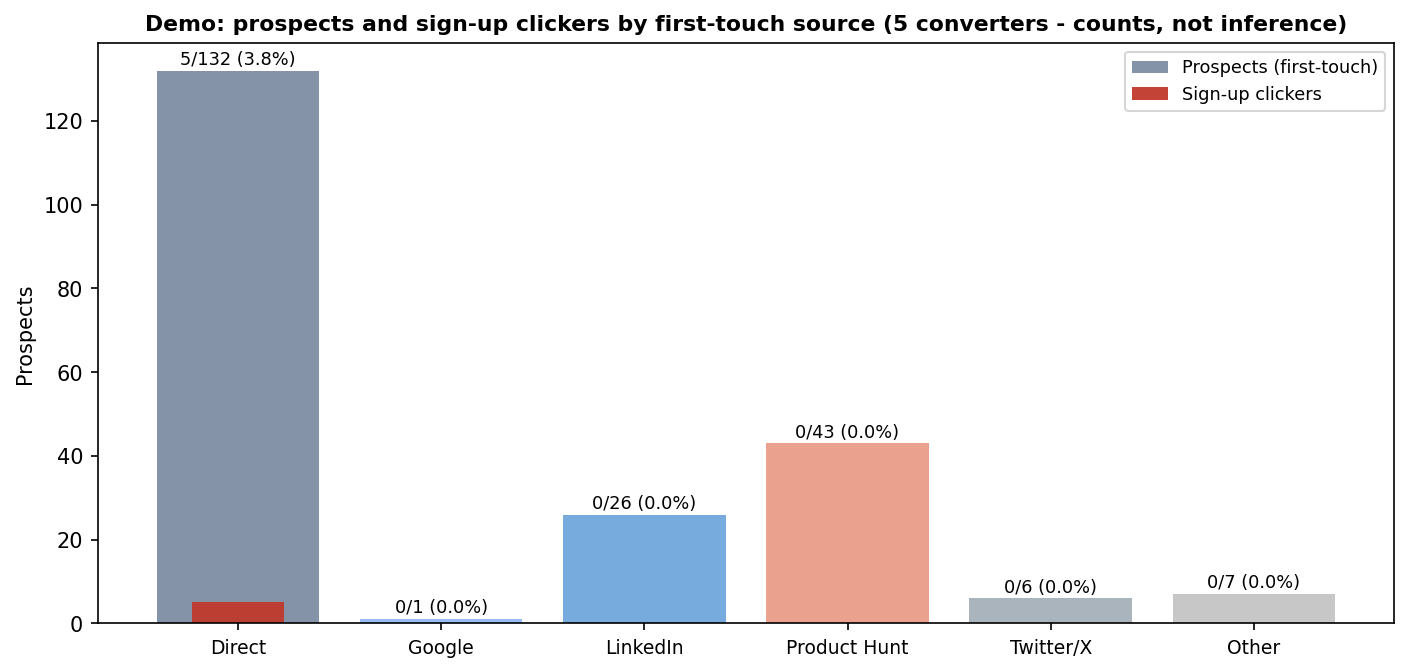

In [ ]:
if "source_group" not in demo_sessions.columns:
    _SRC_ORDER = ["Direct", "Google", "LinkedIn", "Product Hunt", "Twitter/X", "Y Combinator", "Other"]
    _SRC_COLORS = {"Direct": "#1F3A5F", "Google": "#4285F4", "LinkedIn": "#0A66C2",
                   "Product Hunt": "#DA552F", "Twitter/X": "#657786", "Y Combinator": "#FB651E", "Other": "#999999"}
    
    def _source_group(domain):
        if pd.isna(domain) or str(domain).strip() in ("", "nan", "$direct", "Direct"):
            return "Direct"
        d = str(domain).lower().replace("www.", "")
        if "google" in d: return "Google"
        if "linkedin" in d or d.startswith("lnkd"): return "LinkedIn"
        if "producthunt" in d: return "Product Hunt"
        if d in ("t.co", "twitter.com", "x.com") or "twitter" in d: return "Twitter/X"
        if "ycombinator" in d: return "Y Combinator"
        return "Other"
    demo_sessions["source_group"] = demo_sessions["entry_referring_domain"].map(_source_group)

_cta_ids = set(cta_clicks["distinct_id"].dropna())
_dfirst = demo_sessions.sort_values("start_timestamp").drop_duplicates("distinct_id")[["distinct_id", "source_group"]]
_dfirst["converted"] = _dfirst["distinct_id"].isin(_cta_ids)
signup_by_source = (
    _dfirst.groupby("source_group")
    .agg(prospects=("distinct_id", "nunique"), converters=("converted", "sum"))
)
signup_by_source = signup_by_source.reindex([s for s in _SRC_ORDER if s in signup_by_source.index])
display(signup_by_source)

def _wilson(k, n, z=1.96):
    if n == 0:
        return (0.0, 0.0)
    p = k / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return (max(0, centre - half), min(1, centre + half))

signup_by_source["rate"] = signup_by_source["converters"] / signup_by_source["prospects"]
signup_by_source[["lo", "hi"]] = [
    _wilson(int(c), int(n)) for c, n in zip(signup_by_source["converters"], signup_by_source["prospects"])
]
_ss = signup_by_source.sort_values("rate")
_overall = signup_by_source["converters"].sum() / signup_by_source["prospects"].sum() * 100

fig, ax = plt.subplots(figsize=(9.5, 5))
_y = range(len(_ss))
ax.barh(_y, _ss["rate"] * 100, color="#4C8EAF")
_lo_err = np.clip((_ss["rate"] - _ss["lo"]) * 100, 0, None)
_hi_err = np.clip((_ss["hi"] - _ss["rate"]) * 100, 0, None)
ax.errorbar(_ss["rate"] * 100, _y, xerr=[_lo_err, _hi_err],
            fmt="none", ecolor="#555", elinewidth=1.0, capsize=3)
ax.axvline(_overall, color="red", ls="--", lw=1, label=f"Overall average {_overall:.1f}%")
ax.set_yticks(list(_y))
ax.set_yticklabels([f"{s}  (n={int(n)}, {int(c)} converters)"
                    for s, n, c in zip(_ss.index, _ss["prospects"], _ss["converters"])], fontsize=9)
ax.set_xlabel("Sign-up rate (%) with Wilson 95% confidence intervals")
ax.set_title("Demo: sign-up rate by acquisition source")
ax.legend(fontsize=8.5)
fig.tight_layout()
fig.savefig(FIG_DIR / "09b_signup_by_source.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. Demo-by-demo performance and click behaviour

The pooled click ranking has been replaced here because public demo users are routed into a preselected sample project. The right comparison is therefore **between demos**, looking at how long prospects stay, which pages they reach, and which named UI elements they click inside each routed demo.


,project_name,prospects,sessions,total_minutes,mean_session_seconds,median_session_seconds,mean_pageviews,mean_clicks,cta_clickers,cta_click_rate_%
0,Investment Diligence,51,83,671.7,485.6,17.0,8.6,8.4,2,3.9
1,Insurance Claims Portfolio Triage,70,138,781.1,339.6,18.3,12.6,10.3,2,2.9
2,Mortgage Underwriting Automation,62,102,314.0,184.7,32.4,6.4,4.9,2,3.2
3,Property Insurance Risk Analysis,8,24,66.0,164.9,25.8,9.9,7.8,1,12.5
4,Reinsurance Recovery Optimization,22,31,10.6,20.5,2.3,1.9,0.4,1,4.5


,project_name,demo_area,clicks,prospects,% of project clicks
0,Insurance Claims Portfolio Triage,Navi (AI agent),400,34,49.8
1,Insurance Claims Portfolio Triage,Agents,136,13,16.9
2,Insurance Claims Portfolio Triage,Documents,94,12,11.7
3,Insurance Claims Portfolio Triage,Results,75,7,9.3
4,Insurance Claims Portfolio Triage,Document detail,53,8,6.6
5,Investment Diligence,Navi (AI agent),289,26,40.6
6,Investment Diligence,Agents,135,11,19.0
7,Investment Diligence,Documents,111,15,15.6
8,Investment Diligence,Agent run detail,92,2,12.9
9,Investment Diligence,Results,62,9,8.7


,project_name,demo_area,Element clicked,clicks
0,Insurance Claims Portfolio Triage,Navi (AI agent),Documents,39
1,Insurance Claims Portfolio Triage,Navi (AI agent),Demos,24
2,Insurance Claims Portfolio Triage,Agents,Close (Esc),22
3,Insurance Claims Portfolio Triage,Documents,Agents,22
4,Insurance Claims Portfolio Triage,Agents,Results,21
5,Insurance Claims Portfolio Triage,Agents,Documents,18
6,Insurance Claims Portfolio Triage,Navi (AI agent),Agents,18
7,Insurance Claims Portfolio Triage,Navi (AI agent),Show Details,18
8,Investment Diligence,Navi (AI agent),Documents,36
9,Investment Diligence,Documents,Agents,23


'**Key finding:** On average, **Investment Diligence** keeps routed prospects engaged the longest (486s mean session), while **Reinsurance Recovery Optimization** has the shortest average sessions (20s). The tables above show which pages and named UI elements drive that difference within each sample project.'

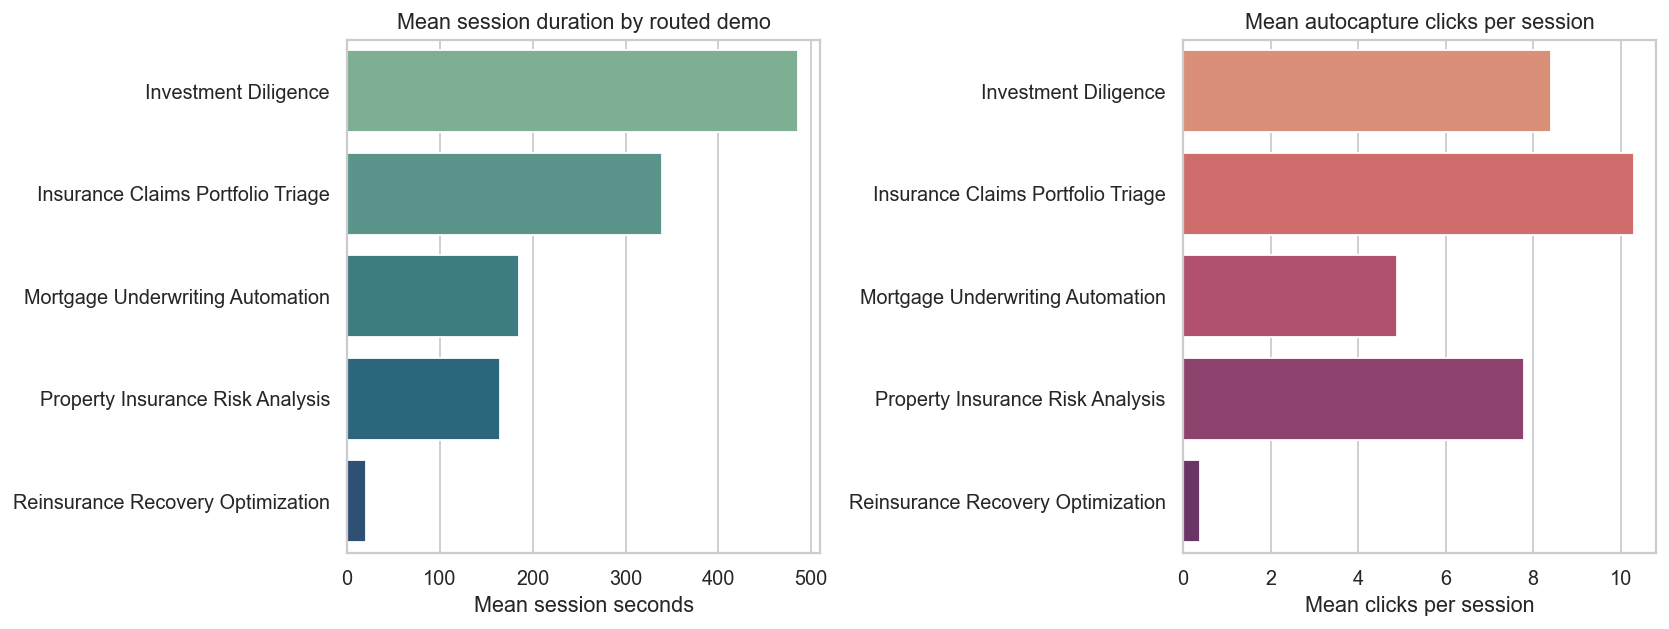

In [15]:
def ensure_demo_context(frame):
    enriched = frame.copy()

    if "page_type" not in enriched.columns:
        enriched["page_type"] = enriched["pathname"].apply(simplify_demo_path)

    if "project_id" not in enriched.columns:
        enriched["project_id"] = enriched["pathname"].str.extract(
            r"/projects/([0-9a-f]{8}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{12})"
        )

    if "project_name" not in enriched.columns:
        enriched["project_name"] = enriched["project_id"].map(PROJECT_NAMES).fillna("No project")

    if "demo_area" not in enriched.columns:
        enriched["demo_area"] = enriched["page_type"].map(DEMO_AREA_MAP).fillna("Other")

    return enriched


demo_events_enriched = ensure_demo_context(demo_events)
demo_ac_enriched = ensure_demo_context(demo_ac)
cta_clicks_enriched = ensure_demo_context(cta_clicks)

clicks = demo_ac_enriched.loc[demo_ac_enriched["event_type"].eq("click")].copy()
clicks["element_text_clean"] = clicks["element_text"].fillna("(no text)").replace("", "(blank text)")

session_project_map = (
    demo_events_enriched.loc[
        demo_events_enriched["project_name"] != "No project",
        ["session_id", "project_name", "distinct_id", "event_timestamp"],
    ]
    .sort_values(["session_id", "event_timestamp"])
    .drop_duplicates(subset=["session_id"], keep="first")
    .drop(columns=["event_timestamp"])
)

project_sessions = demo_sessions.merge(
    session_project_map[["session_id", "project_name", "distinct_id"]],
    on=["session_id", "distinct_id"],
    how="left",
)
project_sessions["project_name"] = project_sessions["project_name"].fillna("No project")

cta_clickers_by_project = (
    cta_clicks_enriched.loc[
        cta_clicks_enriched["project_name"] != "No project", ["project_name", "distinct_id"]
    ]
    .drop_duplicates()
    .groupby("project_name")
    .size()
    .reset_index(name="cta_clickers")
)

project_performance = (
    project_sessions.loc[project_sessions["project_name"] != "No project"]
    .groupby("project_name")
    .agg(
        prospects=("distinct_id", "nunique"),
        sessions=("session_id", "nunique"),
        total_minutes=("session_duration_seconds", lambda s: round(s.sum() / 60, 1)),
        mean_session_seconds=("session_duration_seconds", lambda s: round(s.mean(), 1)),
        median_session_seconds=("session_duration_seconds", lambda s: round(s.median(), 1)),
        mean_pageviews=("pageview_count", lambda s: round(s.mean(), 1)),
        mean_clicks=("autocapture_count", lambda s: round(s.mean(), 1)),
    )
    .reset_index()
    .merge(cta_clickers_by_project, on="project_name", how="left")
    .fillna({"cta_clickers": 0})
)
project_performance["cta_clickers"] = project_performance["cta_clickers"].astype(int)
project_performance["cta_click_rate_%"] = (
    project_performance["cta_clickers"] / project_performance["prospects"] * 100
).round(1)
project_performance = project_performance.sort_values(
    ["mean_session_seconds", "mean_clicks"], ascending=False
).reset_index(drop=True)
display(project_performance)

project_top_areas = (
    clicks.loc[clicks["project_name"] != "No project"]
    .groupby(["project_name", "demo_area"])
    .agg(clicks=("event_type", "size"), prospects=("distinct_id", "nunique"))
    .reset_index()
)
project_top_areas["% of project clicks"] = (
    project_top_areas["clicks"]
    / project_top_areas.groupby("project_name")["clicks"].transform("sum")
    * 100
).round(1)
project_top_areas["rank"] = project_top_areas.groupby("project_name")["clicks"].rank(
    method="first", ascending=False
)
display(
    project_top_areas.loc[project_top_areas["rank"] <= 5]
    .sort_values(["project_name", "rank"])
    .drop(columns=["rank"])
    .reset_index(drop=True)
)

named_clicks = clicks.loc[
    (clicks["project_name"] != "No project")
    & (~clicks["element_text_clean"].isin(["(no text)", "(blank text)"]))
].copy()
project_top_elements = (
    named_clicks.groupby(["project_name", "demo_area", "element_text_clean"])
    .size()
    .reset_index(name="clicks")
)
project_top_elements["rank"] = project_top_elements.groupby("project_name")["clicks"].rank(
    method="first", ascending=False
)
display(
    project_top_elements.loc[project_top_elements["rank"] <= 8]
    .sort_values(["project_name", "rank", "demo_area", "element_text_clean"])
    .rename(columns={"element_text_clean": "Element clicked"})
    .drop(columns=["rank"])
    .reset_index(drop=True)
)

best_duration = project_performance.iloc[0]
weakest_duration = project_performance.iloc[-1]
display(
    Markdown(
        f"**Key finding:** On average, **{best_duration['project_name']}** keeps routed prospects engaged the longest "
        f"({best_duration['mean_session_seconds']:.0f}s mean session), while **{weakest_duration['project_name']}** "
        f"has the shortest average sessions ({weakest_duration['mean_session_seconds']:.0f}s). The tables above show "
        f"which pages and named UI elements drive that difference within each sample project."
    )
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(
    data=project_performance,
    x="mean_session_seconds",
    y="project_name",
    hue="project_name",
    legend=False,
    ax=axes[0],
    palette="crest",
)
axes[0].set_title("Mean session duration by routed Demo")
axes[0].set_xlabel("Mean session seconds")
axes[0].set_ylabel("")

sns.barplot(
    data=project_performance,
    x="mean_clicks",
    y="project_name",
    hue="project_name",
    legend=False,
    ax=axes[1],
    palette="flare",
)
axes[1].set_title("Mean autocapture clicks per session")
axes[1].set_xlabel("Mean clicks per session")
axes[1].set_ylabel("")

fig.tight_layout()
fig.savefig(FIG_DIR / "05_demo_project_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## 11. Event breakdown and rageclick context

Rageclicks are expected on `/navi` because the page visually presents a chat interface that invites interaction, but the text input is locked in the public demo. Prospects often click into that input expecting to type, then discover that sign-up is required.


In [16]:
demo_event_mix = demo_events["event"].value_counts().reset_index()
demo_event_mix.columns = ["Event", "Count"]
demo_event_mix["Description"] = demo_event_mix["Event"].map(
    {
        "$pageview": "Page loaded",
        "$autocapture": "Auto-tracked click",
        "$set": "Person property update",
        "$rageclick": "Repeated rapid clicking in one area",
    }
)
display(demo_event_mix)

rageclicks = demo_events.loc[demo_events["event"] == "$rageclick"].copy()
print(f"Rageclicks: {len(rageclicks)} events across {rageclicks['distinct_id'].nunique()} prospects")

if len(rageclicks) > 0:
    rc_by_page = (
        rageclicks.groupby("page_type")
        .agg(rageclicks=("event", "count"), affected_prospects=("distinct_id", "nunique"))
        .sort_values("rageclicks", ascending=False)
        .reset_index()
    )
    rc_by_page["Area"] = rc_by_page["page_type"].map(DEMO_AREA_MAP).fillna("Other")
    display(rc_by_page)


# ── Rageclick visualisations: by product area and by clicked element ──
if len(rageclicks) > 0:
    _rcp = rc_by_page.sort_values("rageclicks")
    fig, ax = plt.subplots(figsize=(9.5, 5))
    ax.barh(_rcp["Area"], _rcp["rageclicks"], color="#C44E52")
    ax.set_xlabel("Rageclick events")
    ax.set_title("Demo rageclicks by product area")
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    fig.tight_layout()
    fig.savefig(FIG_DIR / "demo_rageclicks_by_page.png", dpi=150, bbox_inches="tight")
    plt.show()

    _rce = (
        rageclicks.assign(_el=rageclicks["element_text"].fillna("").str.strip())
        .loc[lambda d: d["_el"] != ""]
        .groupby("_el").size().sort_values()
    ).tail(15)
    _labels = [t if len(t) <= 42 else t[:41] + "\u2026" for t in _rce.index]
    fig, ax = plt.subplots(figsize=(9.5, 6))
    ax.barh(range(len(_rce)), _rce.values, color="#C44E52")
    ax.set_yticks(range(len(_rce)))
    ax.set_yticklabels(_labels, fontsize=8.5)
    ax.set_xlabel("Rageclick events")
    ax.set_title("Demo rageclicks by clicked element")
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    fig.tight_layout()
    fig.savefig(FIG_DIR / "demo_rageclicks_by_element.png", dpi=150, bbox_inches="tight")
    plt.show()


,Event,Count,Description
0,$pageview,3413,Page loaded
1,$autocapture,2825,Auto-tracked click
2,$set,189,Person property update
3,$identify,106,NaN
4,$rageclick,55,Repeated rapid clicking in one area
5,$groupidentify,2,NaN


Rageclicks: 55 events across 11 prospects


,page_type,rageclicks,affected_prospects,Area
0,/projects/{id}/navi,25,5,Navi (AI agent)
1,/projects/{id}/documents/{doc_id},21,9,Document detail
2,/projects/{id}/agents/{agent_id}/{run_id},5,1,Agent run detail
3,/projects/{id}/results,3,1,Results
4,/projects/{id}/agents,1,1,Agents


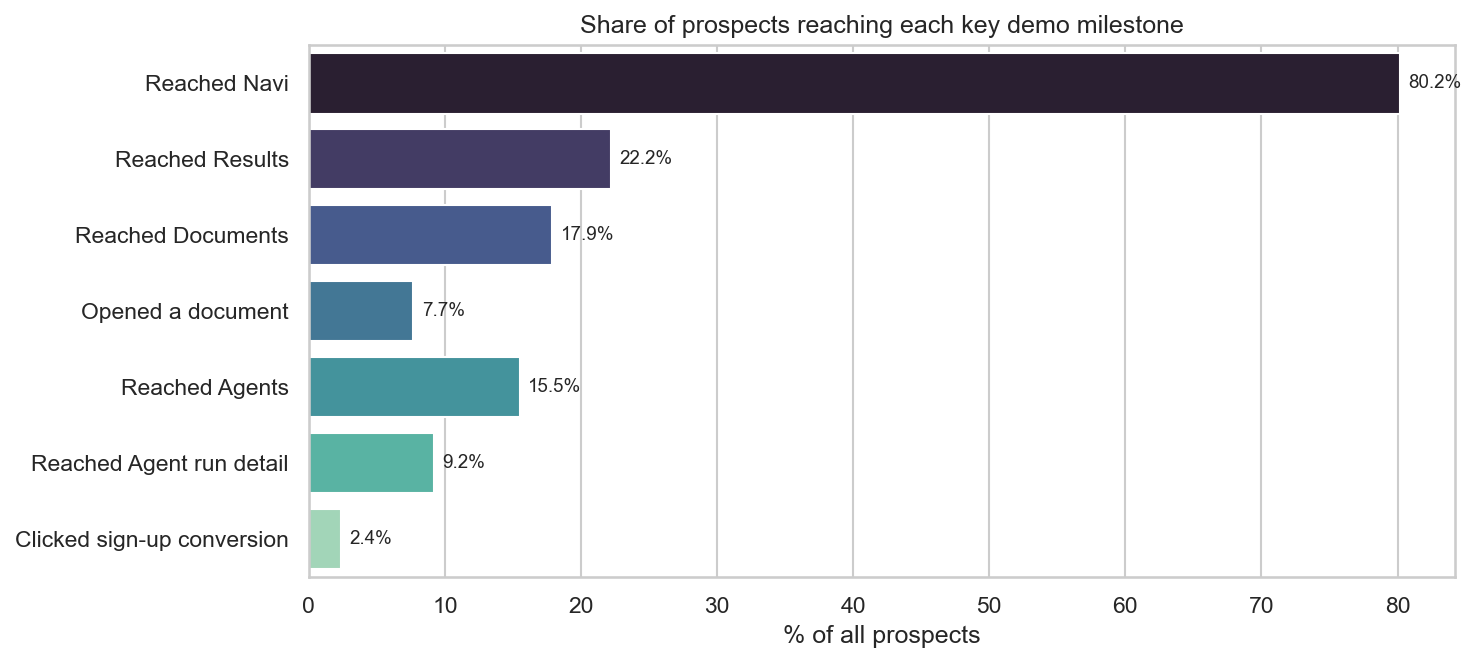

In [ ]:

engagement_milestones = [
    ("Reached Navi", "/projects/{id}/navi"),
    ("Reached Results", "/projects/{id}/results"),
    ("Reached Agents", "/projects/{id}/agents"),
    ("Reached Agent run detail", "/projects/{id}/agents/{agent_id}/{run_id}"),
    ("Reached Documents", "/projects/{id}/documents"),
    ("Opened a document", "/projects/{id}/documents/{doc_id}"),
]

milestone_rows = []
for label, page_type in engagement_milestones:
    visitors = demo_events.loc[demo_events["page_type"] == page_type, "distinct_id"].nunique()
    milestone_rows.append({
        "Milestone": label,
        "Prospects": visitors,
        "% of prospects": round(visitors / total_prospects * 100, 1),
    })

engagement_reach = pd.DataFrame(milestone_rows)
engagement_reach = engagement_reach.sort_values("% of prospects", ascending=False).reset_index(drop=True)

interactive_prospects = demo_ac["distinct_id"].nunique()
view_only_prospects = total_prospects - interactive_prospects
engagement_summary = pd.DataFrame(
    {
        "Milestone": ["Viewed only (no clicks)", "Generated at least one click", "Clicked sign-up conversion"],
        "Prospects": [view_only_prospects, interactive_prospects, cta_clickers],
        "% of prospects": [
            round(view_only_prospects / total_prospects * 100, 1),
            round(interactive_prospects / total_prospects * 100, 1),
            round(cta_clickers / total_prospects * 100, 1),
        ],
    }
)
display(engagement_reach)
display(engagement_summary)

display(
    Markdown(
        f"**Key finding:** Roughly **{view_only_prospects / total_prospects:.0%}** of demo prospects (**{view_only_prospects} of {total_prospects}**) viewed pages without clicking on anything. The chart below is not a ladder any more: it shows the **share of all prospects who reached each key milestone**, so each bar can be read independently."
    )
)

fig, ax = plt.subplots(figsize=(10, 4.6))
# Fixed order: group "Opened a document" under "Reached Documents"; "Viewed only" excluded.
CHART_ORDER = ["Reached Navi", "Reached Results", "Reached Documents", "Opened a document",
               "Reached Agents", "Reached Agent run detail", "Clicked sign-up conversion"]
plot_data = pd.concat(
    [engagement_reach,
     engagement_summary.loc[engagement_summary["Milestone"] == "Clicked sign-up conversion"]],
    ignore_index=True,
)
plot_data = plot_data.set_index("Milestone").loc[CHART_ORDER].reset_index()

sns.barplot(data=plot_data, x="% of prospects", y="Milestone", order=CHART_ORDER,
            hue="Milestone", legend=False, ax=ax, palette="mako")
ax.set_title("Share of prospects reaching each key Demo milestone")
ax.set_xlabel("% of all prospects")
ax.set_ylabel("")
for idx, value in enumerate(plot_data["% of prospects"]):
    ax.text(value + 0.6, idx, f"{value:.1f}%", va="center", fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "06_engagement_depth.png", dpi=150, bbox_inches="tight")
plt.show()



## 12. Use-case comparison across routed demos

This section compares the main areas of the demo side by side across sample projects. The emphasis is on where prospects spend their clicks after landing in a routed demo: `Navi`, `Documents`, `Document detail`, `Agents`, `Agent run detail`, and `Results`. The large chart below shows the **full click mix** inside each routed demo as percentages, not just the single top area.


,demo_area,clicks,prospects
0,Navi (AI agent),1170,66
1,Agents,456,24
2,Results,342,15
3,Documents,299,30
4,Agent run detail,264,7
5,Document detail,109,14


,project_name,demo_area,clicks,% of project clicks
0,Insurance Claims Portfolio Triage,Navi (AI agent),400,50.2
1,Insurance Claims Portfolio Triage,Agents,136,17.1
2,Insurance Claims Portfolio Triage,Documents,94,11.8
3,Insurance Claims Portfolio Triage,Results,75,9.4
4,Insurance Claims Portfolio Triage,Document detail,53,6.6
5,Insurance Claims Portfolio Triage,Agent run detail,39,4.9
6,Investment Diligence,Navi (AI agent),289,40.8
7,Investment Diligence,Agents,135,19.0
8,Investment Diligence,Documents,111,15.7
9,Investment Diligence,Agent run detail,92,13.0


demo_area,project_name,Navi (AI agent),Documents,Document detail,Agents,Agent run detail,Results
0,Insurance Claims Portfolio Triage,50.2,11.8,6.6,17.1,4.9,9.4
1,Investment Diligence,40.8,15.7,2.8,19.0,13.0,8.7
2,Mortgage Underwriting Automation,43.1,8.5,2.4,18.5,7.3,20.2
3,Property Insurance Risk Analysis,28.1,10.3,4.6,14.4,27.0,15.6
4,Reinsurance Recovery Optimization,63.6,3.9,4.5,9.1,6.5,12.3


,Action,Clicks
0,Viewed Navi,1170
1,Clicked inside Agents,456
2,Clicked inside Results,342
3,Clicked inside Documents,299
4,Opened agent run detail,264
5,Opened document detail,109
6,Clicked sign-up CTA,11


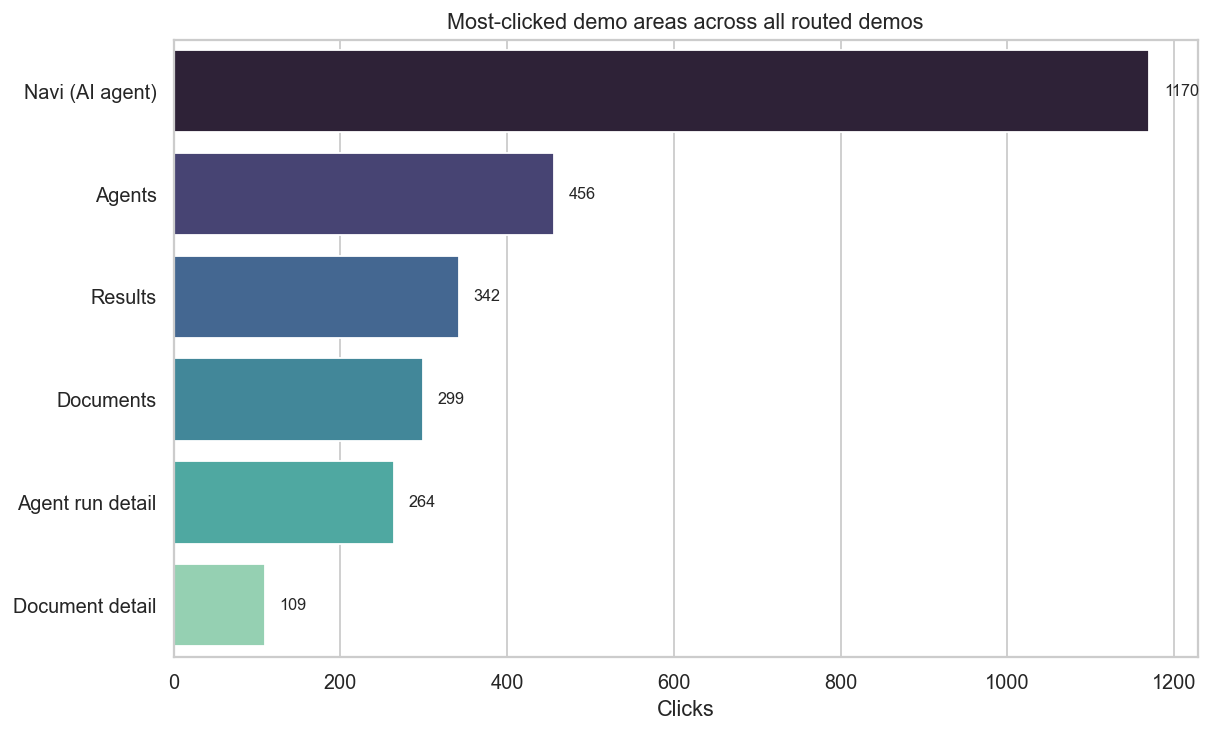

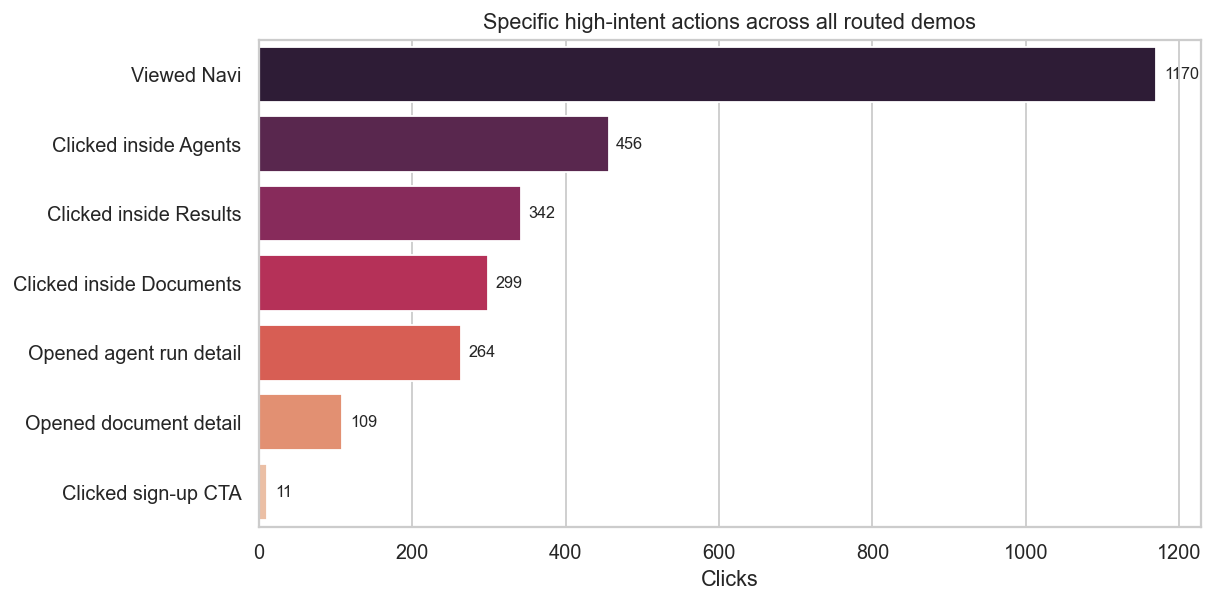

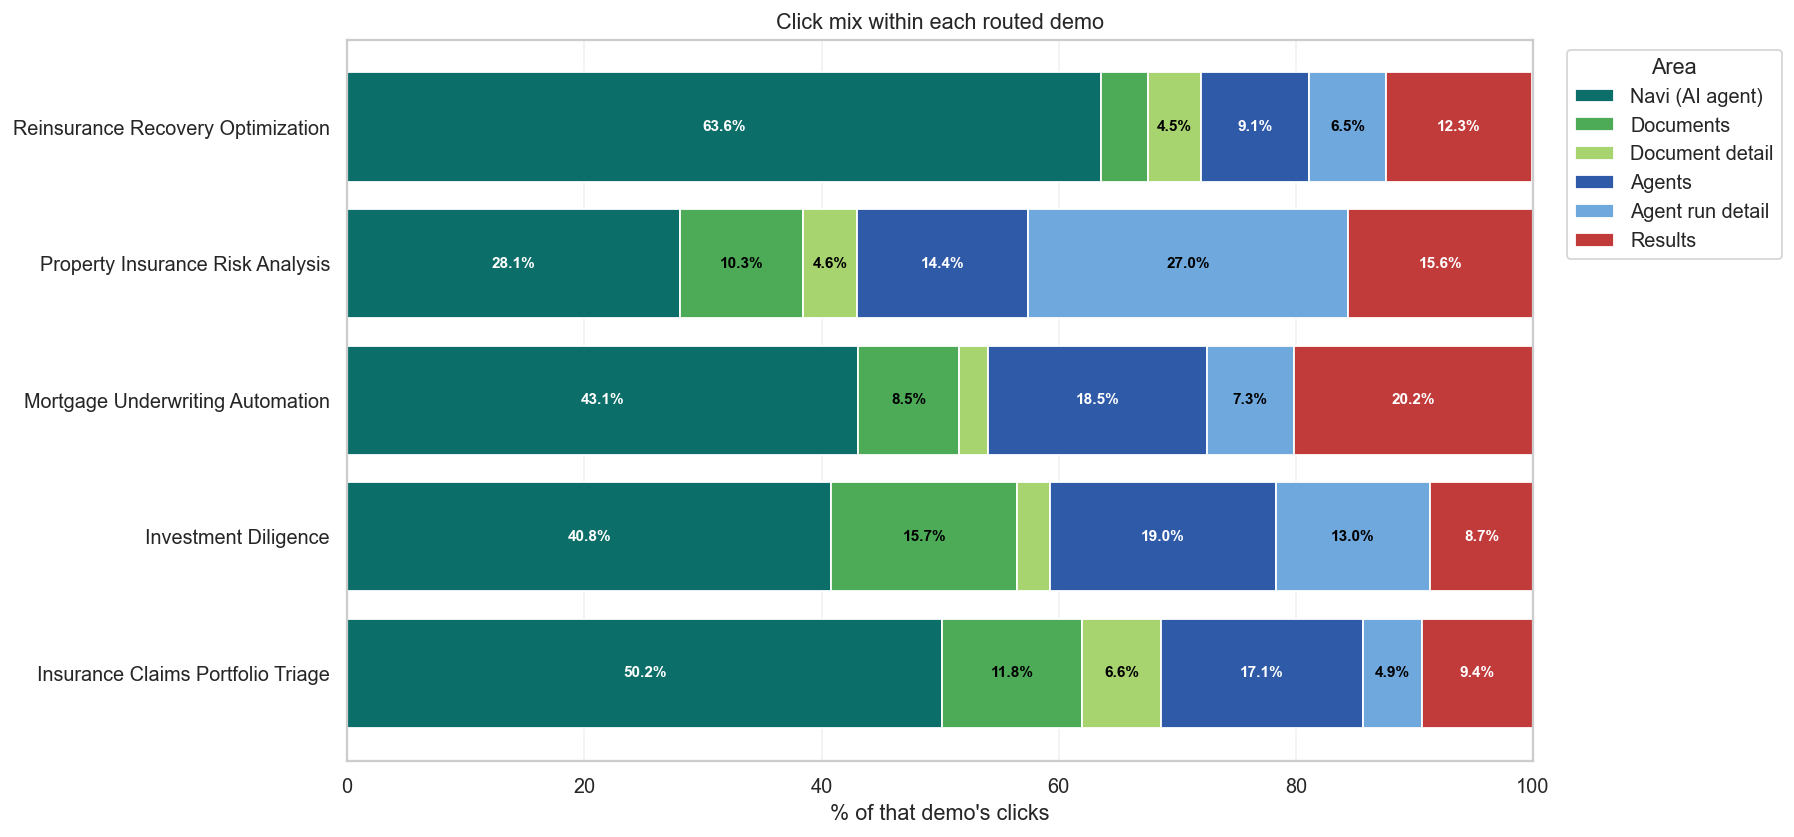

In [18]:

focus_areas = [
    "Navi (AI agent)",
    "Documents",
    "Document detail",
    "Agents",
    "Agent run detail",
    "Results",
]

use_case_summary = (
    clicks.loc[
        (clicks["project_name"] != "No project") & (clicks["demo_area"].isin(focus_areas))
    ]
    .groupby("demo_area")
    .agg(clicks=("event_type", "size"), prospects=("distinct_id", "nunique"))
    .sort_values("clicks", ascending=False)
    .reset_index()
)
display(use_case_summary)

project_use_case_share = (
    clicks.loc[
        (clicks["project_name"] != "No project") & (clicks["demo_area"].isin(focus_areas))
    ]
    .groupby(["project_name", "demo_area"])
    .size()
    .reset_index(name="clicks")
)
project_use_case_share["% of project clicks"] = (
    project_use_case_share["clicks"]
    / project_use_case_share.groupby("project_name")["clicks"].transform("sum")
    * 100
).round(1)
display(
    project_use_case_share.sort_values(
        ["project_name", "% of project clicks"], ascending=[True, False]
    ).reset_index(drop=True)
)

project_click_mix = (
    project_use_case_share.pivot(
        index="project_name", columns="demo_area", values="% of project clicks"
    )
    .fillna(0)
    .reindex(columns=focus_areas)
)
display(project_click_mix.reset_index())

high_intent_actions = pd.DataFrame(
    {
        "Action": [
            "Viewed Navi",
            "Clicked inside Agents",
            "Clicked inside Results",
            "Clicked inside Documents",
            "Opened document detail",
            "Opened agent run detail",
            "Clicked sign-up CTA",
        ],
        "Clicks": [
            int(use_case_summary.loc[use_case_summary["demo_area"] == "Navi (AI agent)", "clicks"].sum()),
            int(use_case_summary.loc[use_case_summary["demo_area"] == "Agents", "clicks"].sum()),
            int(use_case_summary.loc[use_case_summary["demo_area"] == "Results", "clicks"].sum()),
            int(use_case_summary.loc[use_case_summary["demo_area"] == "Documents", "clicks"].sum()),
            int(use_case_summary.loc[use_case_summary["demo_area"] == "Document detail", "clicks"].sum()),
            int(use_case_summary.loc[use_case_summary["demo_area"] == "Agent run detail", "clicks"].sum()),
            int(len(cta_clicks)),
        ],
    }
).sort_values("Clicks", ascending=False).reset_index(drop=True)
display(high_intent_actions)

fig, ax = plt.subplots(figsize=(9.5, 5.8))
sns.barplot(
    data=use_case_summary,
    x="clicks",
    y="demo_area",
    hue="demo_area",
    legend=False,
    ax=ax,
    palette="mako",
)
ax.set_title("Most-clicked demo areas across all routed demos")
ax.set_xlabel("Clicks")
ax.set_ylabel("")
for idx, value in enumerate(use_case_summary["clicks"]):
    ax.text(value + 18, idx, f"{value}", va="center", fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "09_demo_use_case_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(9.5, 4.8))
sns.barplot(
    data=high_intent_actions,
    x="Clicks",
    y="Action",
    hue="Action",
    legend=False,
    ax=ax,
    palette="rocket",
)
ax.set_title("Specific high-intent actions across all routed demos")
ax.set_xlabel("Clicks")
ax.set_ylabel("")
for idx, value in enumerate(high_intent_actions["Clicks"]):
    ax.text(value + 10, idx, f"{value}", va="center", fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "09a_high_intent_actions.png", dpi=150, bbox_inches="tight")
plt.show()

stack_colors = {
    "Navi (AI agent)": "#0B6E69",
    "Documents": "#4DAA57",
    "Document detail": "#A7D46F",
    "Agents": "#2F5AA8",
    "Agent run detail": "#6FA8DC",
    "Results": "#C23B3B",
}

fig, ax = plt.subplots(figsize=(14, 6.6))
left = pd.Series(0, index=project_click_mix.index, dtype=float)
for area in focus_areas:
    values = project_click_mix[area]
    bars = ax.barh(
        project_click_mix.index,
        values,
        left=left,
        color=stack_colors[area],
        edgecolor="white",
        linewidth=1,
        label=area,
    )
    for bar, value, left_edge in zip(bars, values, left):
        if value >= 4:
            ax.text(
                left_edge + value / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{value:.1f}%",
                ha="center",
                va="center",
                fontsize=8.5,
                color="white" if area in ["Navi (AI agent)", "Agents", "Results"] else "black",
                fontweight="bold",
            )
    left = left + values

ax.set_title("Click mix within each routed demo")
ax.set_xlabel("% of that demo's clicks")
ax.set_ylabel("")
ax.set_xlim(0, 100)
ax.grid(axis="x", alpha=0.25)
ax.legend(title="Area", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(FIG_DIR / "09b_demo_click_mix_by_project.png", dpi=150, bbox_inches="tight")
plt.show()



Project-level context matters here. In the live public-demo journey, prospects are deep-linked into a preselected sample project and normally stay within that project. As a result, the chart below is best read as engagement **within the routed sample project each prospect was sent to**, not as a revealed preference test across projects from a visible chooser screen.

Important distinction: the area charts show **where clicks happened** (`Navi`, `Documents`, `Document detail`, `Agents`, `Agent run detail`, `Results`). The separate high-intent action chart adds **specific actions** such as `Clicked sign-up CTA`, which is not a page area and therefore should not be expected to appear inside the page-area chart.

Tracking caveat: `Result detail` currently shows **zero recorded clicks** in this export. That should **not** be interpreted as evidence that nobody opened or used result-detail views. The more likely explanation is that PostHog is not reliably capturing those result-detail interactions in the current demo instrumentation.


## 13. Document drill-down by sample project

The question here is narrower: once prospects reach the `Documents` area, do they actually open individual documents and inspect the detail pages? The tables below quantify that by project.


,project_name,document_detail_events,distinct_documents_opened,total_project_sessions,sessions_reaching_documents,prospects_reaching_documents,prospects_opening_document_detail,document_page_clicks,document_detail_clicks,document_browse_session_rate_%,document_open_rate_%
0,Investment Diligence,52,10,107,38,16,4,111,20,35.5,25.0
1,Property Insurance Risk Analysis,41,6,37,12,3,2,27,12,32.4,66.7
2,Insurance Claims Portfolio Triage,106,15,156,49,14,8,94,53,31.4,57.1
3,Mortgage Underwriting Automation,51,10,124,30,11,5,61,17,24.2,45.5
4,Reinsurance Recovery Optimization,16,1,51,10,5,1,6,7,19.6,20.0


,project_name,Element clicked,clicks
0,Insurance Claims Portfolio Triage,Agents,22
1,Insurance Claims Portfolio Triage,Navi,13
2,Insurance Claims Portfolio Triage,A789123456_|_Claim Data_|_Claim Data.xlsx,5
3,Insurance Claims Portfolio Triage,Results,5
4,Insurance Claims Portfolio Triage,Go to next page,4
5,Investment Diligence,Agents,23
6,Investment Diligence,Navi,11
7,Investment Diligence,Results,6
8,Investment Diligence,Estate_Agent_Property_Listing.pdf,3
9,Investment Diligence,Sarah_Thompson_Driving_Licence.png,3


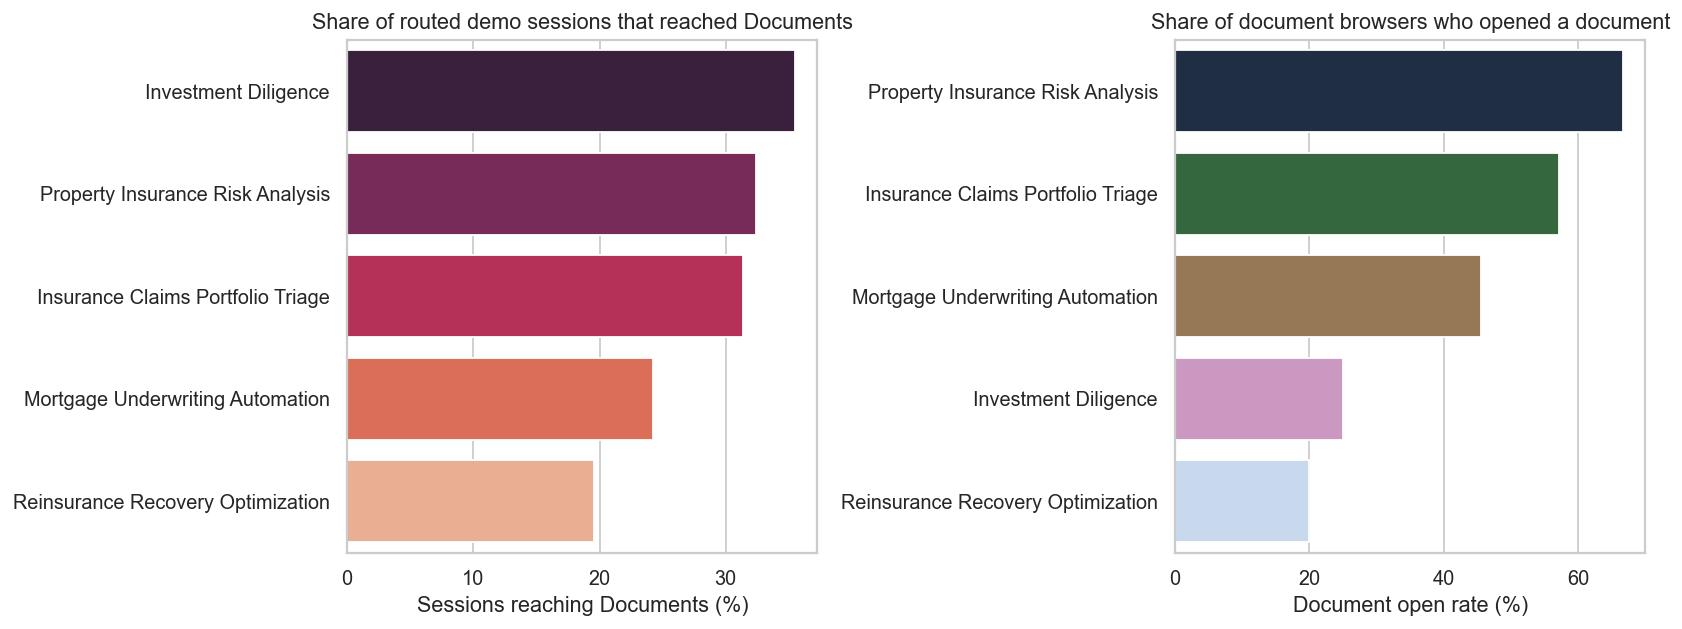

In [19]:
if "page_type" not in demo_events.columns:
    demo_events["page_type"] = demo_events["pathname"].apply(simplify_demo_path)

if "project_id" not in demo_events.columns:
    demo_events["project_id"] = demo_events["pathname"].str.extract(
        r"/projects/([0-9a-f]{8}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{12})"
    )

if "project_name" not in demo_events.columns:
    demo_events["project_name"] = demo_events["project_id"].map(PROJECT_NAMES).fillna("No project")

if "demo_area" not in demo_events.columns:
    demo_events["demo_area"] = demo_events["page_type"].map(DEMO_AREA_MAP).fillna("Other")

if "page_type" not in demo_ac.columns:
    demo_ac["page_type"] = demo_ac["pathname"].apply(simplify_demo_path)

if "project_id" not in demo_ac.columns:
    demo_ac["project_id"] = demo_ac["pathname"].str.extract(
        r"/projects/([0-9a-f]{8}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{12})"
    )

if "project_name" not in demo_ac.columns:
    demo_ac["project_name"] = demo_ac["project_id"].map(PROJECT_NAMES).fillna("No project")

if "demo_area" not in demo_ac.columns:
    demo_ac["demo_area"] = demo_ac["page_type"].map(DEMO_AREA_MAP).fillna("Other")

if "clicks" not in globals():
    clicks = demo_ac.loc[demo_ac["event_type"].eq("click")].copy()

if "element_text_clean" not in clicks.columns:
    clicks["element_text_clean"] = clicks["element_text"].fillna("(no text)").replace("", "(blank text)")

if "named_clicks" not in globals():
    named_clicks = clicks.loc[
        ~clicks["element_text_clean"].isin(["(no text)", "(blank text)"])
    ].copy()

document_events = demo_events.assign(
    document_id=demo_events["pathname"].str.extract(
        r"/projects/[0-9a-f\-]+/documents/([0-9a-f\-]+)"
    )
).dropna(subset=["document_id"])

project_sessions = (
    demo_events.loc[demo_events["project_name"] != "No project"]
    .groupby("project_name")["session_id"]
    .nunique()
    .reset_index(name="total_project_sessions")
)

document_sessions = (
    demo_events.loc[
        (demo_events["project_name"] != "No project")
        & (demo_events["demo_area"] == "Documents")
    ]
    .groupby("project_name")["session_id"]
    .nunique()
    .reset_index(name="sessions_reaching_documents")
)

document_page_prospects = (
    demo_events.loc[
        (demo_events["project_name"] != "No project")
        & (demo_events["demo_area"] == "Documents")
    ]
    .groupby("project_name")["distinct_id"]
    .nunique()
    .reset_index(name="prospects_reaching_documents")
)

document_detail_prospects = (
    document_events.loc[document_events["project_name"] != "No project"]
    .groupby("project_name")["distinct_id"]
    .nunique()
    .reset_index(name="prospects_opening_document_detail")
)

document_page_clicks = (
    clicks.loc[
        (clicks["project_name"] != "No project") & (clicks["demo_area"] == "Documents")
    ]
    .groupby("project_name")
    .size()
    .reset_index(name="document_page_clicks")
)

document_detail_clicks = (
    clicks.loc[
        (clicks["project_name"] != "No project")
        & (clicks["demo_area"] == "Document detail")
    ]
    .groupby("project_name")
    .size()
    .reset_index(name="document_detail_clicks")
)

document_drilldown = (
    document_events.loc[document_events["project_name"] != "No project"]
    .groupby("project_name")
    .agg(
        document_detail_events=("document_id", "size"),
        distinct_documents_opened=("document_id", "nunique"),
    )
    .reset_index()
    .merge(project_sessions, on="project_name", how="outer")
    .merge(document_sessions, on="project_name", how="outer")
    .merge(document_page_prospects, on="project_name", how="outer")
    .merge(document_detail_prospects, on="project_name", how="outer")
    .merge(document_page_clicks, on="project_name", how="outer")
    .merge(document_detail_clicks, on="project_name", how="outer")
    .fillna(0)
)

for col in [
    "document_detail_events",
    "distinct_documents_opened",
    "total_project_sessions",
    "sessions_reaching_documents",
    "prospects_reaching_documents",
    "prospects_opening_document_detail",
    "document_page_clicks",
    "document_detail_clicks",
]:
    document_drilldown[col] = document_drilldown[col].astype(int)

document_drilldown["document_browse_session_rate_%"] = (
    document_drilldown["sessions_reaching_documents"]
    / document_drilldown["total_project_sessions"].replace({0: pd.NA})
    * 100
).round(1)

document_drilldown["document_open_rate_%"] = (
    document_drilldown["prospects_opening_document_detail"]
    / document_drilldown["prospects_reaching_documents"].replace({0: pd.NA})
    * 100
).round(1)
document_drilldown["document_browse_session_rate_%"] = pd.to_numeric(
    document_drilldown["document_browse_session_rate_%"], errors="coerce"
)
document_drilldown["document_open_rate_%"] = pd.to_numeric(
    document_drilldown["document_open_rate_%"], errors="coerce"
)

display(document_drilldown.sort_values("document_browse_session_rate_%", ascending=False).reset_index(drop=True))

document_named_clicks = (
    named_clicks.loc[named_clicks["demo_area"] == "Documents"]
    .groupby(["project_name", "element_text_clean"])
    .size()
    .reset_index(name="clicks")
)
document_named_clicks["rank"] = document_named_clicks.groupby("project_name")["clicks"].rank(
    method="first", ascending=False
)
display(
    document_named_clicks.loc[document_named_clicks["rank"] <= 5]
    .sort_values(["project_name", "rank", "element_text_clean"])
    .rename(columns={"element_text_clean": "Element clicked"})
    .drop(columns=["rank"])
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(
    data=document_drilldown.sort_values("document_browse_session_rate_%", ascending=False),
    x="document_browse_session_rate_%",
    y="project_name",
    hue="project_name",
    legend=False,
    ax=axes[0],
    palette="rocket",
)
axes[0].set_title("Share of routed demo sessions that reached Documents")
axes[0].set_xlabel("Sessions reaching Documents (%)")
axes[0].set_ylabel("")

sns.barplot(
    data=document_drilldown.sort_values("document_open_rate_%", ascending=False),
    x="document_open_rate_%",
    y="project_name",
    hue="project_name",
    legend=False,
    ax=axes[1],
    palette="cubehelix",
)
axes[1].set_title("Share of document browsers who opened a document")
axes[1].set_xlabel("Document open rate (%)")
axes[1].set_ylabel("")

fig.tight_layout()
fig.savefig(FIG_DIR / "10_document_drilldown.png", dpi=150, bbox_inches="tight")
plt.show()


,distinct_navi_pages_read
count,166.000000
mean,1.253012
std,0.988950
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,11.000000


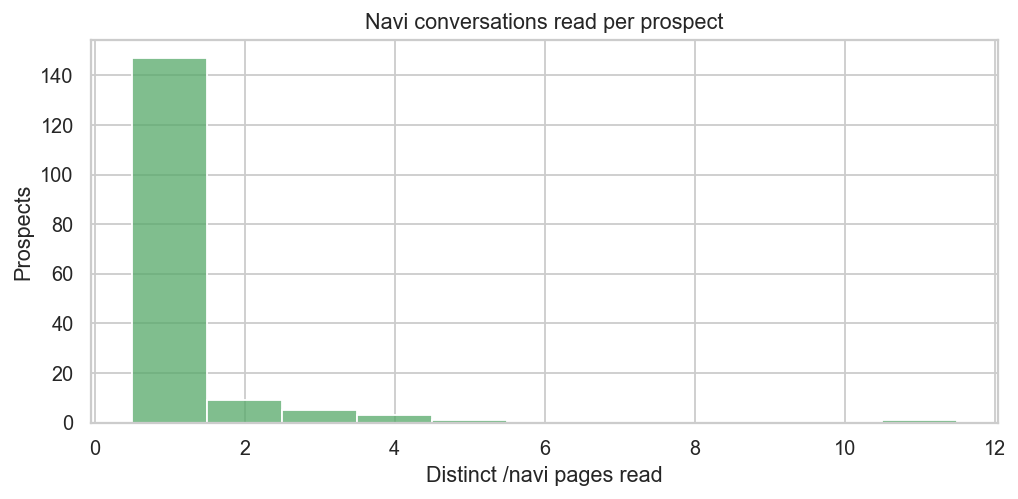

In [20]:
navi_per_prospect = (
    demo_events.loc[demo_events["page_type"] == "/projects/{id}/navi"]
    .groupby("distinct_id")["project_id"]
    .nunique()
    .reset_index(name="distinct_navi_pages_read")
)
display(navi_per_prospect.describe())

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(navi_per_prospect["distinct_navi_pages_read"], discrete=True, binwidth=1, ax=ax, color="#55A868")
ax.set_title("Navi conversations read per prospect")
ax.set_xlabel("Distinct /navi pages read")
ax.set_ylabel("Prospects")
fig.tight_layout()
fig.savefig(FIG_DIR / "11_navi_pages_per_prospect.png", dpi=150, bbox_inches="tight")
plt.show()


In [21]:
if "page_types" not in globals():
    if "page_type" not in demo_events.columns:
        demo_events["page_type"] = demo_events["pathname"].apply(simplify_demo_path)
    if "demo_area" not in demo_events.columns:
        demo_events["demo_area"] = demo_events["page_type"].map(DEMO_AREA_MAP).fillna("Other")
    page_types = demo_events["page_type"].value_counts().reset_index()
    page_types.columns = ["Page type", "Events"]
    page_types["Area"] = page_types["Page type"].map(DEMO_AREA_MAP).fillna("Other")

if "click_elements" not in globals():
    if "clicks" not in globals():
        if "page_type" not in demo_ac.columns:
            demo_ac["page_type"] = demo_ac["pathname"].apply(simplify_demo_path)
        clicks = demo_ac.loc[demo_ac["event_type"].eq("click")].copy()
    click_elements = clicks["element_text"].fillna("(no text)").value_counts().reset_index()
    click_elements.columns = ["Element clicked", "Count"]

if "total_prospects" not in globals():
    total_prospects = demo_events["distinct_id"].nunique()

top_areas = page_types[["Area", "Events"]].head(2).reset_index(drop=True)
top_click_labels = ", ".join(click_elements["Element clicked"].head(3).tolist())
rageclick_count = int((demo_events["event"] == "$rageclick").sum())

summary = pd.DataFrame(
    {
        "Metric": [
            "Events (all demo visitors)",
            "Sessions (all demo visitors)",
            "Unique prospects",
            "Merged visitor profiles (person_id)",
            "Mean session duration",
            "Total time on demo",
            "Most active area",
            "Second most active area",
            "Top clicked elements",
            "Rageclick count",
        ],
        "Value": [
            len(demo_events),
            len(demo_sessions),
            total_prospects,
            len(demo_profiles),
            f"{demo_sessions['session_duration_seconds'].mean():.0f}s",
            f"{demo_sessions['session_duration_seconds'].sum():.0f}s ({demo_sessions['session_duration_seconds'].sum() / 60:.1f} min)",
            f"{top_areas.loc[0, 'Area']} — {top_areas.loc[0, 'Events']} events",
            f"{top_areas.loc[1, 'Area']} — {top_areas.loc[1, 'Events']} events",
            top_click_labels,
            rageclick_count,
        ],
    }
)
display(summary)


,Metric,Value
0,Events (all demo visitors),6590
1,Sessions (all demo visitors),379
2,Unique prospects,207
3,Merged visitor profiles (person_id),105
4,Mean session duration,293s
5,Total time on demo,111062s (1851.0 min)
6,Most active area,Navi (AI agent) — 2701 events
7,Second most active area,Results — 1235 events
8,Top clicked elements,"(no text), Documents, Agents"
9,Rageclick count,55


## Predictive Analytics — Sign-Up Conversion Drivers

Synthetic data augmentation + ML feature importance to identify which demo characteristics predict a visitor clicking the sign-up CTA.

**Tautological exclusions (hard-coded):**
- `reached_navi` — Navi *is* the demo landing page; every routed visitor lands there, so the flag is constant and circular
- `clicked_signup` — that IS the target variable

### How this section evolved (model-development log)

- **v1 — synthetic-augmentation model (below).** With only 5 real sign-up clickers, a `GaussianCopulaSynthesizer` was used to stabilise training, and XGBoost + SHAP were fitted on the combined real + synthetic table. In its original run — with the buggy area flags described in v2 — honest validation on the real 207 visitors put every model *at or below* the 0.5 random-chance line. After the v2 bug fix, the same pipeline's tree models transfer at ≈0.75 real-data AUC (see the updated outputs below), converging with the v3 honest estimate.
- **v2 — bug fix.** The `reached_*` area flags compared `page_type` path templates against display labels, so all six flags and `engagement_depth` were constant zeros for every visitor (they contributed nothing to v1, and any conclusion about "area reached doesn't matter" was an artifact). Fixed in the `_vdf` construction cell below; the flags are now genuinely informative.
- **v3 — honest re-validation (new section after Key Findings).** Two further edits: features are *censored at each converter's first sign-up click* (the old `total_clicks` literally counted the sign-up click itself, and durations included post-click sessions), and the synthetic data is dropped in favour of a simple L2 logistic regression evaluated with leave-one-out cross-validation, a label-permutation test, and bootstrap confidence intervals — the appropriate machinery for 5 positives out of 207.


In [22]:
# ── STABILITY FIX: macOS OpenMP multiple-runtime guard ──────────────────────
# Root cause of the kernel crashes: several libraries each ship their OWN copy
# of the OpenMP runtime (libomp.dylib): sklearn bundles one, torch bundles one
# (pulled in transitively by `sdv`), and xgboost's libxgboost.dylib was patched
# to load /opt/anaconda3/lib/libomp.dylib. When two different libomp copies load
# into the same process, OpenMP calls abort() by default -> the Jupyter kernel
# dies with SIGSEGV (exit 139) and no traceback.
#
# These two env vars MUST be set BEFORE any OpenMP-backed library is imported.
# KMP_DUPLICATE_LIB_OK=TRUE  -> allow the duplicate runtime instead of aborting.
# OMP_NUM_THREADS=1          -> single-threaded; removes the thread-contention
#                               path entirely and makes results reproducible.
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"

import subprocess, sys
for _pkg in ["scikit-learn", "shap", "sdv"]:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", _pkg], check=False)

import warnings
import numpy as np
from pathlib import Path

# xgboost's patched dylib points at the anaconda libomp; keep that path resolvable.
_libomp_dir = Path("/opt/anaconda3/lib")
if _libomp_dir.exists():
    os.environ["DYLD_FALLBACK_LIBRARY_PATH"] = str(_libomp_dir)

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
import shap
from sdv.single_table import GaussianCopulaSynthesizer
from sdv.metadata import SingleTableMetadata

# Import XGBoost LAST. With the OpenMP guard above this is now stable.
try:
    import xgboost as xgb
    _HAS_XGBOOST = True
    print(f"XGBoost {xgb.__version__} loaded successfully.")
except Exception as exc:
    xgb = None
    _HAS_XGBOOST = False
    print(f"XGBoost unavailable, will fall back to Random Forest: {exc}")

warnings.filterwarnings("ignore")
print("Predictive-analytics packages loaded.")



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


XGBoost 3.2.0 loaded successfully.
Predictive-analytics packages loaded.


In [23]:
# ── TARGET ────────────────────────────────────────────────────────────────
_signup_ids = set(
    demo_ac.loc[
        demo_ac["element_text"].isin(["Sign up", "Sign Up"]) &
        (demo_ac["event_type"] == "click"),
        "distinct_id"
    ]
)
print(f"Observed sign-up clickers: {len(_signup_ids)}")

# ── ROUTED-DEMO UNIVERSE ──────────────────────────────────────────────────
_known = [v for v in PROJECT_NAMES.values() if v != "Unknown demo project"]
_re = demo_events[demo_events["project_name"].isin(_known)].copy()
_routed_ids = _re["distinct_id"].unique()
print(f"Routed-demo visitors: {len(_routed_ids)}")

# ── PROJECT / VERTICAL (mode per visitor) ────────────────────────────────
_vproj = (
    _re.groupby("distinct_id")["project_name"]
    .agg(lambda x: x.mode().iloc[0]).rename("project_name")
)
_vvert = (
    _re.groupby("distinct_id")["demo_vertical"]
    .agg(lambda x: x.mode().iloc[0]).rename("demo_vertical")
)

# ── SESSION AGGREGATES ────────────────────────────────────────────────────
_sr = demo_sessions[demo_sessions["distinct_id"].isin(_routed_ids)].copy()
_sfeat = _sr.groupby("distinct_id").agg(
    n_sessions        = ("session_id",              "nunique"),
    mean_dur          = ("session_duration_seconds", "mean"),
    max_dur           = ("session_duration_seconds", "max"),
    total_pv          = ("pageview_count",           "sum"),
    total_clicks      = ("autocapture_count",        "sum"),
    all_bounce        = ("is_bounce",                "all"),
    any_bounce        = ("is_bounce",                "any"),
    has_referrer      = ("entry_referring_domain",   lambda x: x.notna().any()),
).reset_index()

# ── AREA FLAGS — NAVI EXCLUDED (landing page, circular predictor) ─────────
_AREA_MAP = {
    "reached_results":       "Results",
    "reached_result_detail": "Result detail",
    "reached_agents":        "Agents",
    "reached_agent_run":     "Agent run detail",
    "reached_documents":     "Documents",
    "reached_doc_detail":    "Document detail",
}
_DEPTH_AREAS = list(_AREA_MAP.values())
# BUG FIX (Jul 2026): page_type holds path TEMPLATES ("/projects/{id}/results"),
# not display labels ("Results"), so the original comparison never matched and every
# reach flag (and engagement_depth) was a constant 0/False for all 207 visitors.
# Map templates -> labels via DEMO_AREA_MAP first, then compare labels to labels.
_re["demo_area"] = _re["page_type"].map(DEMO_AREA_MAP).fillna("Other")
_area_frames = {
    _col: _re[_re["demo_area"] == _area].groupby("distinct_id").size().gt(0).rename(_col)
    for _col, _area in _AREA_MAP.items()
}

# ── ENGAGEMENT DEPTH (areas beyond Navi) ──────────────────────────────────
_sets_v = _re.groupby("distinct_id")["demo_area"].apply(set)
_eng_depth = _sets_v.apply(
    lambda s: sum(1 for a in _DEPTH_AREAS if a in s)
).rename("engagement_depth")

# ── RAGECLICK COUNT ───────────────────────────────────────────────────────
_rage = (
    _re[_re["event"] == "$rageclick"]
    .groupby("distinct_id").size().rename("rageclick_count")
)

# ── DEVICE & GEO ─────────────────────────────────────────────────────────
_device = (
    _re.groupby("distinct_id")["device_type"]
    .agg(lambda x: x.mode().iloc[0] if not x.empty else "Unknown")
    .rename("device_type")
)
_ctry_raw = (
    _re.groupby("distinct_id")["country"]
    .agg(lambda x: x.mode().iloc[0] if not x.empty else "Unknown")
)
_top5_c = _ctry_raw.value_counts().head(5).index.tolist()
_country = _ctry_raw.apply(lambda c: c if c in _top5_c else "Other").rename("country")

# ── TIME FEATURES ─────────────────────────────────────────────────────────
_first_ts   = _re.groupby("distinct_id")["event_timestamp"].min()
_visit_hour = _first_ts.dt.hour.rename("visit_hour")
_visit_dow  = _first_ts.dt.dayofweek.rename("visit_dow")

# ── ASSEMBLE ──────────────────────────────────────────────────────────────
_vdf = (
    pd.DataFrame(index=_routed_ids)
    .join(_vproj).join(_vvert)
    .join(_sfeat.set_index("distinct_id"))
    .join(pd.concat(_area_frames.values(), axis=1))
    .join(_eng_depth).join(_rage)
    .join(_device).join(_country)
    .join(_visit_hour).join(_visit_dow)
)

_BOOL_COLS = list(_AREA_MAP.keys())
_vdf[_BOOL_COLS] = _vdf[_BOOL_COLS].fillna(False).astype(bool)
_vdf["rageclick_count"] = _vdf["rageclick_count"].fillna(0).astype(int)
_vdf["clicked_signup"]  = _vdf.index.isin(_signup_ids).astype(int)

print(f"Visitor table: {_vdf.shape}  |  sign-up rate: {_vdf['clicked_signup'].mean():.1%}")
_vdf[["project_name", "n_sessions", "engagement_depth", "total_pv", "clicked_signup"]].head()


Observed sign-up clickers: 5
Routed-demo visitors: 207
Visitor table: (207, 23)  |  sign-up rate: 2.4%


,project_name,n_sessions,engagement_depth,total_pv,clicked_signup
019cb9ad-473a-7ca7-a8da-9946cddbfdf9,Investment Diligence,1.0,3,11.0,0
019cb9b3-06ad-7c87-88ad-0245ed41929d,Investment Diligence,1.0,0,11.0,0
019cb962-09df-7e01-b510-e421813b0807,Insurance Claims Portfolio Triage,3.0,3,292.0,0
019cb9e3-6b43-7d0c-8a66-8752b7a4d2f4,Investment Diligence,1.0,2,11.0,0
019cb9e6-d912-71bd-aae2-3587e7617e3e,Mortgage Underwriting Automation,1.0,0,12.0,0


In [24]:
# Real dataset is too small for robust ML (typically <100 visitors, <15 sign-up clickers).
# GaussianCopulaSynthesizer learns joint feature distributions from the real data
# and samples a larger synthetic population that preserves inter-feature correlations
# and the empirical sign-up rate.

_CAT_COLS = ["project_name", "demo_vertical", "device_type", "country"]
_INT_COLS  = _BOOL_COLS + ["all_bounce", "any_bounce", "has_referrer"]

_sv = _vdf.reset_index(drop=True).copy()
for _c in _CAT_COLS:
    _sv[_c] = _sv[_c].fillna("Unknown").astype(str)
for _c in _INT_COLS:
    _sv[_c] = _sv[_c].fillna(0).astype(int)  # fillna before int cast — NaN-safe

_meta = SingleTableMetadata()
_meta.detect_from_dataframe(_sv)
for _c in _CAT_COLS:
    _meta.update_column(_c, sdtype="categorical")
_meta.update_column("clicked_signup", sdtype="categorical")

_synthesizer = GaussianCopulaSynthesizer(_meta, default_distribution="beta")
_synthesizer.fit(_sv)

N_SYNTH = 500
_synthesizer.reset_sampling()  # deterministic synthetic sample (seed-lock)
_sv_new = _synthesizer.sample(num_rows=N_SYNTH)

for _c in _INT_COLS:
    _sv_new[_c] = _sv_new[_c].round().clip(0, 1).astype(int)
_sv_new["rageclick_count"]  = _sv_new["rageclick_count"].round().clip(0).astype(int)
_sv_new["engagement_depth"] = _sv_new["engagement_depth"].round().clip(0, len(_DEPTH_AREAS)).astype(int)
_sv_new["clicked_signup"]   = _sv_new["clicked_signup"].round().clip(0, 1).astype(int)

_sv["_source"]     = "real"
_sv_new["_source"] = "synthetic"
_combined = pd.concat([_sv, _sv_new], ignore_index=True)

print(f"Real      : {len(_sv):4d} rows   sign-up rate {_sv['clicked_signup'].mean():.1%}")
print(f"Synthetic : {len(_sv_new):4d} rows   sign-up rate {_sv_new['clicked_signup'].mean():.1%}")
print(f"Combined  : {len(_combined):4d} rows   sign-up rate {_combined['clicked_signup'].mean():.1%}")

Real      :  207 rows   sign-up rate 2.4%
Synthetic :  500 rows   sign-up rate 6.4%
Combined  :  707 rows   sign-up rate 5.2%


In [25]:
# Tautological exclusions (per project brief):
#   • Navi (landing page): every routed visitor lands there — constant, circular
#   • clicked_signup: the outcome variable itself
#
# EVALUATION DESIGN — why a single stratified holdout, not cross-validation:
# The previous version used sklearn cross_val_score, which fans work out across
# parallel worker processes. With three OpenMP runtimes loaded (sklearn / torch /
# xgboost) that parallel fan-out was the trigger that killed the kernel. We replace
# it with one stratified train/holdout split plus a separate check on the REAL
# visitor rows. This is simpler, single-threaded, fully deterministic, and tells us
# the same thing: does the model generalise, and does it transfer to real data?

_FEAT_COLS = [
    "project_name", "demo_vertical",
    "n_sessions", "mean_dur", "max_dur",
    "total_pv", "total_clicks",
    "all_bounce", "any_bounce", "has_referrer",
    "reached_results", "reached_result_detail",
    "reached_agents", "reached_agent_run",
    "reached_documents", "reached_doc_detail",
    "engagement_depth", "rageclick_count",
    "device_type", "country",
    "visit_hour", "visit_dow",
]

_enc = _combined[_FEAT_COLS + ["clicked_signup", "_source"]].copy()
_encoders = {}
for _c in _CAT_COLS:
    _le = LabelEncoder()
    _enc[_c] = _le.fit_transform(_enc[_c].fillna("Unknown").astype(str))
    _encoders[_c] = _le

_num_cols = [c for c in _FEAT_COLS if c not in _CAT_COLS]
_medians = _enc[_num_cols].median()
_enc[_num_cols] = _enc[_num_cols].fillna(_medians)

X_syn = _enc.loc[_enc["_source"] == "synthetic", _FEAT_COLS].astype("float32")
y_syn = _enc.loc[_enc["_source"] == "synthetic", "clicked_signup"].astype(int)
X_real = _enc.loc[_enc["_source"] == "real", _FEAT_COLS].astype("float32")
y_real = _enc.loc[_enc["_source"] == "real", "clicked_signup"].astype(int)

X_fit, X_hold, y_fit, y_hold = train_test_split(
    X_syn, y_syn, test_size=0.25, random_state=42, stratify=y_syn
)

print(f"Synthetic fit set     : {X_fit.shape}  positives: {int(y_fit.sum())}")
print(f"Synthetic holdout set : {X_hold.shape}  positives: {int(y_hold.sum())}")
print(f"Real validation set   : {X_real.shape}  positives: {int(y_real.sum())}")

_pos_w = max(1, int((y_fit == 0).sum() / max(y_fit.sum(), 1)))

# All estimators pinned to a single thread (n_jobs=1 / tree_method=hist) so no
# estimator spins up its own OpenMP pool. Stability over raw speed — the data is tiny.
_models = {
    "Logistic Regression": Pipeline([
        ("sc", StandardScaler()),
        ("clf", LogisticRegression(
            class_weight="balanced", max_iter=2000, C=0.5, random_state=42
        )),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=400, class_weight="balanced",
        max_depth=5, min_samples_leaf=3, random_state=42, n_jobs=1
    ),
}

if _HAS_XGBOOST:
    _models["XGBoost"] = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=_pos_w,
        eval_metric="logloss",
        objective="binary:logistic",
        tree_method="hist",
        n_jobs=1,
        random_state=42,
        verbosity=0,
    )

def _auc(model, X, y):
    if y.sum() == 0:
        return float("nan")
    return roc_auc_score(y, model.predict_proba(X)[:, 1])

_results = {}
for _nm, _m in _models.items():
    # XGBoost wants raw numpy; sklearn estimators are happy with the DataFrame.
    _fit_X  = X_fit.values  if _nm == "XGBoost" else X_fit
    _hold_X = X_hold.values if _nm == "XGBoost" else X_hold
    _real_X = X_real.values if _nm == "XGBoost" else X_real

    _m.fit(_fit_X, y_fit)
    _hold_auc = _auc(_m, _hold_X, y_hold)
    _real_auc = _auc(_m, _real_X, y_real)

    _results[_nm] = {
        "Holdout AUC (synthetic)": round(_hold_auc, 3),
        "Val AUC (real)": round(_real_auc, 3),
    }
    print(f"{_nm:<26}  Holdout-AUC={_hold_auc:.3f}  Val-AUC={_real_auc:.3f}")

pd.DataFrame(_results).T


Synthetic fit set     : (375, 22)  positives: 24
Synthetic holdout set : (125, 22)  positives: 8
Real validation set   : (207, 22)  positives: 5
Logistic Regression         Holdout-AUC=0.462  Val-AUC=0.348


Random Forest               Holdout-AUC=0.519  Val-AUC=0.748


XGBoost                     Holdout-AUC=0.480  Val-AUC=0.750


,Holdout AUC (synthetic),Val AUC (real)
Logistic Regression,0.462,0.348
Random Forest,0.519,0.748
XGBoost,0.480,0.750


TREE EXPLAINER MODEL : XGBoost
MODEL CLASS          : xgboost.sklearn.XGBClassifier

── Feature importance (mean |SHAP|) on 150 rows ──────────────────
Tree explainer model: XGBoost
              feature  mean_abs_shap                   feature_label
             mean_dur       0.731975          Average session length
         total_clicks       0.568799                    Total clicks
              country       0.447495                         Country
           visit_hour       0.441188             Hour of first visit
              max_dur       0.419257          Longest session length
             total_pv       0.375732                 Total pageviews
        demo_vertical       0.288923                       Demo type
          device_type       0.279429                     Device type
         project_name       0.225592                    Demo project
   reached_doc_detail       0.194613          Opened document detail
            visit_dow       0.174307              Day of fi

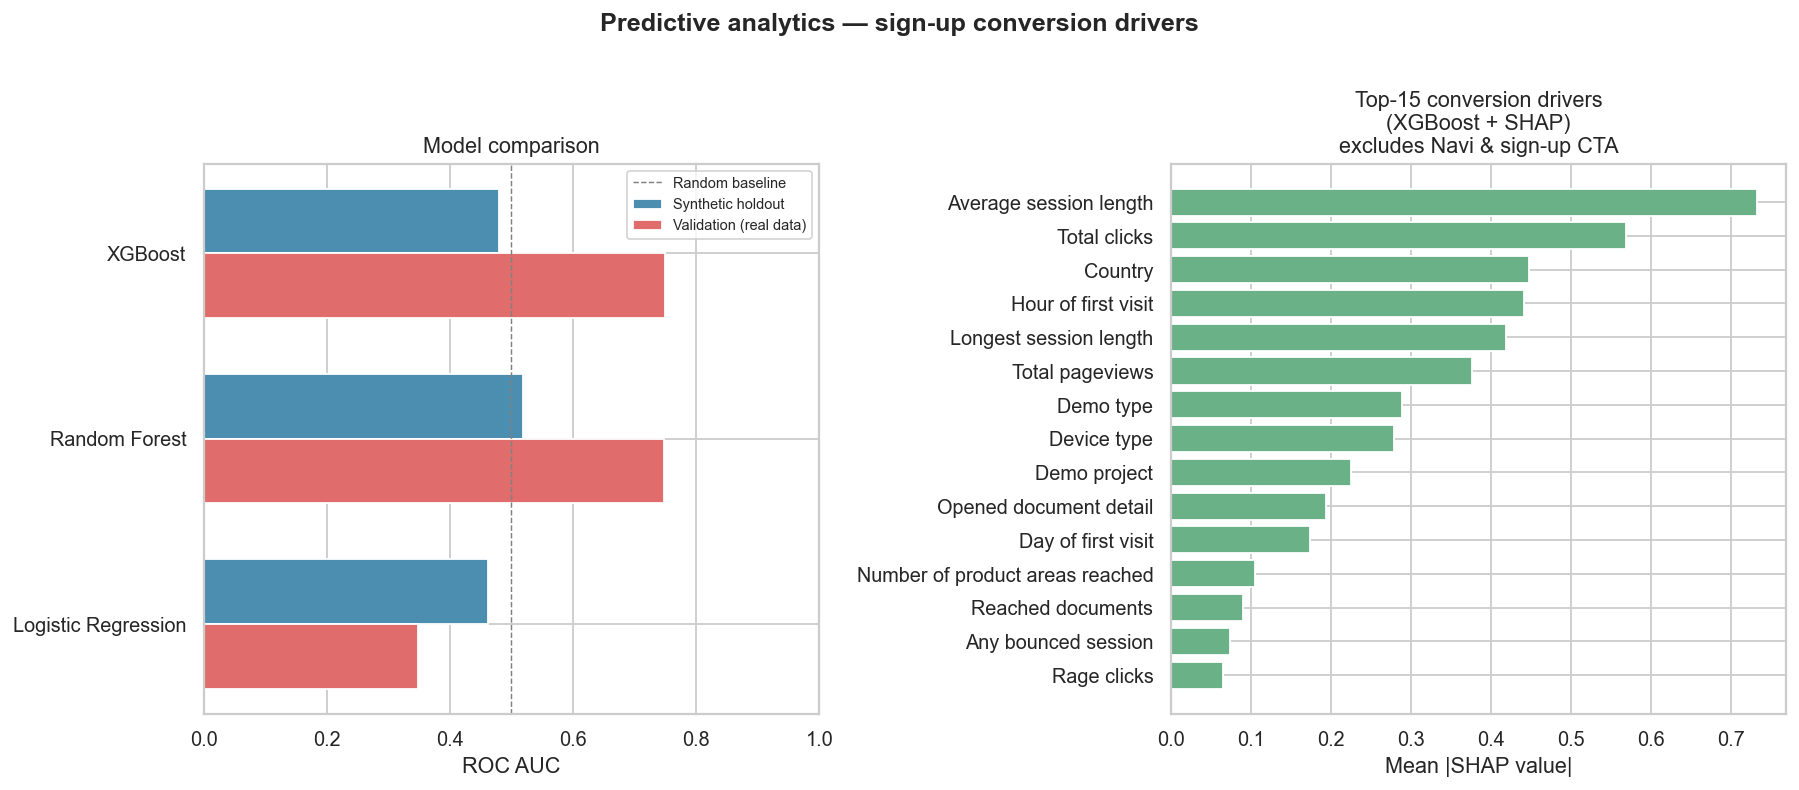

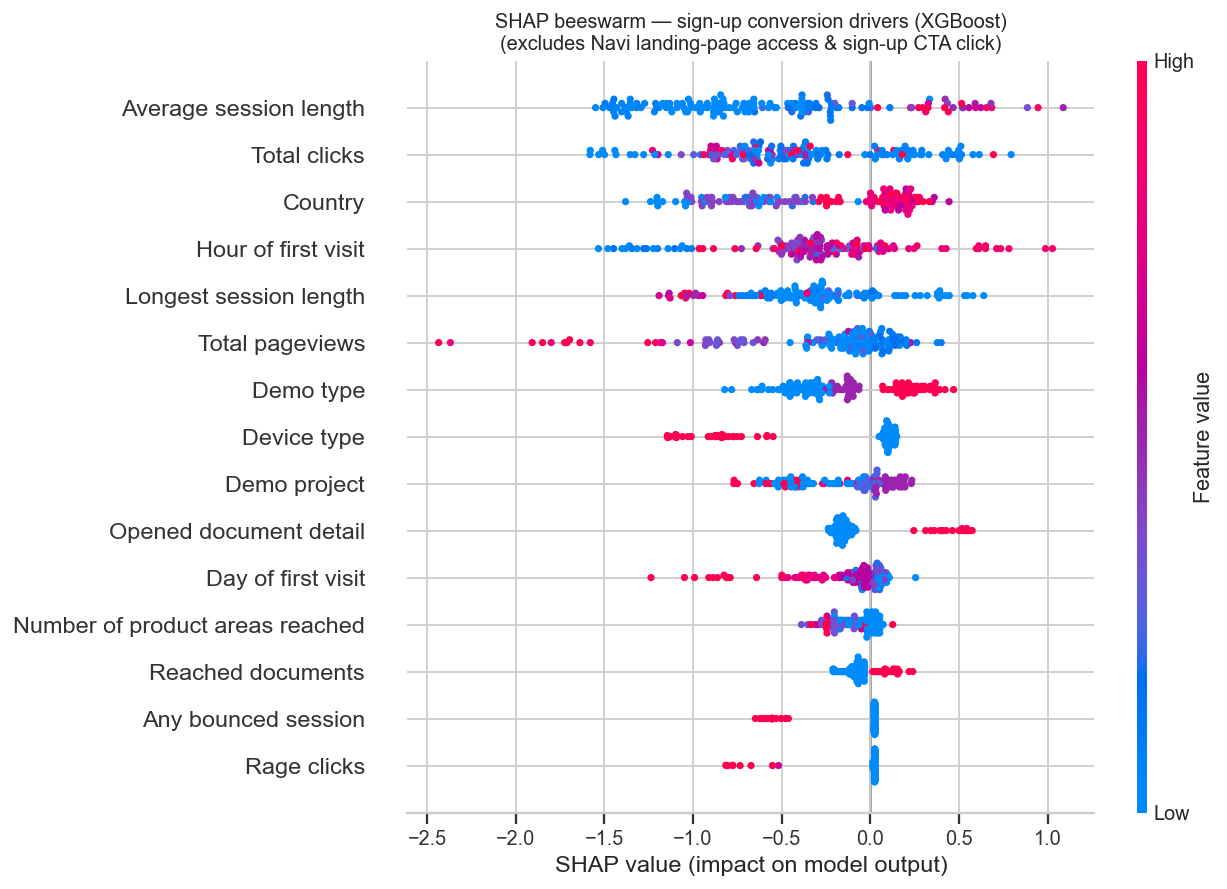

In [26]:
from pathlib import Path

# ── Choose the tree model to explain with SHAP ─────────────────────────────
# Prefer XGBoost. We only fall back to Random Forest if XGBoost genuinely failed
# to load (see the import cell) — never silently.
_tree_model_name = "XGBoost" if _HAS_XGBOOST and "XGBoost" in _models else "Random Forest"
_tree_model = _models[_tree_model_name]

# Explicit, unmissable confirmation of WHICH model SHAP is explaining.
print("=" * 70)
print(f"TREE EXPLAINER MODEL : {_tree_model_name}")
print(f"MODEL CLASS          : {type(_tree_model).__module__}.{type(_tree_model).__name__}")
print("=" * 70)
if _tree_model_name == "Random Forest":
    print("WARNING: XGBoost did not load, so SHAP is explaining the Random Forest "
          "fallback. Re-check the import cell.")

# ── SHAP on a small, fixed sample for stability ────────────────────────────
# TreeExplainer is cheap, but we cap the sample at 150 rows so the beeswarm stays
# readable and the cell runs fast and deterministically.
_SHAP_N = min(len(X_fit), 150)
_shap_X = X_fit.sample(_SHAP_N, random_state=42).copy()

# XGBoost's TreeExplainer is most stable on a plain numpy array.
_expl = shap.TreeExplainer(_tree_model)
if _tree_model_name == "XGBoost":
    _sv_shap = _expl.shap_values(_shap_X.values)
    _plot_X = _shap_X.values
else:
    _sv_shap = _expl.shap_values(_shap_X)
    _plot_X = _shap_X

# Normalise SHAP output to a single 2-D array for the positive class.
if isinstance(_sv_shap, list):
    _sv_shap_arr = _sv_shap[1] if len(_sv_shap) > 1 else _sv_shap[0]
elif getattr(_sv_shap, "ndim", 0) == 3:
    _sv_shap_arr = _sv_shap[:, :, 1]
else:
    _sv_shap_arr = _sv_shap

_FEATURE_LABELS = {
    "mean_dur": "Average session length",
    "max_dur": "Longest session length",
    "visit_hour": "Hour of first visit",
    "total_clicks": "Total clicks",
    "demo_vertical": "Demo type",
    "visit_dow": "Day of first visit",
    "total_pv": "Total pageviews",
    "country": "Country",
    "project_name": "Demo project",
    "n_sessions": "Number of sessions",
    "rageclick_count": "Rage clicks",
    "device_type": "Device type",
    "any_bounce": "Any bounced session",
    "all_bounce": "All sessions bounced",
    "has_referrer": "Had a referrer",
    "reached_results": "Reached results",
    "reached_result_detail": "Opened result detail",
    "reached_agents": "Reached agents",
    "reached_agent_run": "Opened agent run detail",
    "reached_documents": "Reached documents",
    "reached_doc_detail": "Opened document detail",
    "engagement_depth": "Number of product areas reached",
}

_shap_imp = (
    pd.DataFrame({"feature": _FEAT_COLS, "mean_abs_shap": np.abs(_sv_shap_arr).mean(axis=0)})
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)
_shap_imp["feature_label"] = _shap_imp["feature"].map(_FEATURE_LABELS).fillna(_shap_imp["feature"])
print(f"\n── Feature importance (mean |SHAP|) on {_SHAP_N} rows ──────────────────")
print(f"Tree explainer model: {_tree_model_name}")
print(_shap_imp.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Predictive model comparison and the top 15 conversion drivers",
             fontsize=14, fontweight="bold", y=1.01)

_adf = pd.DataFrame(_results).T.reset_index().rename(columns={"index": "Model"})
_x = np.arange(len(_adf)); _w = 0.35
axes[0].barh(_x + _w/2, _adf["Holdout AUC (synthetic)"], _w, color="#4C8EAF",
             label="Synthetic holdout")
axes[0].barh(_x - _w/2, _adf["Val AUC (real)"], _w, color="#E06C6C",
             label="Validation (real data)")
axes[0].set_yticks(_x); axes[0].set_yticklabels(_adf["Model"])
axes[0].axvline(0.5, color="grey", ls="--", lw=0.8, label="Random baseline")
axes[0].set_xlim(0, 1); axes[0].set_xlabel("ROC AUC")
axes[0].set_title("Model comparison"); axes[0].legend(fontsize=8)

_top15 = _shap_imp.head(15)
axes[1].barh(_top15["feature_label"][::-1], _top15["mean_abs_shap"][::-1], color="#6AB187")
axes[1].set_xlabel("Mean |SHAP value|")
axes[1].set_title(f"Top-15 conversion drivers\n({_tree_model_name} + SHAP)")

plt.tight_layout()
_out = Path("../outputs/signup_predictive_analytics.png")
_out.parent.mkdir(exist_ok=True)
plt.savefig(_out, dpi=150, bbox_inches="tight"); plt.show()

plt.figure(figsize=(10, 7))
_plot_feature_names = [_FEATURE_LABELS.get(f, f) for f in _FEAT_COLS]
shap.summary_plot(_sv_shap_arr, _plot_X, feature_names=_plot_feature_names,
                  show=False, max_display=15, plot_size=None)
plt.title(
    f"SHAP beeswarm of sign-up conversion drivers ({_tree_model_name})",
    fontsize=11
)
plt.tight_layout()
plt.savefig("../outputs/signup_shap_beeswarm.png", dpi=150, bbox_inches="tight"); plt.show()


## Key Findings — Sign-Up Conversion Drivers

The tree model explained with SHAP in this run is **XGBoost** (`xgboost.sklearn.XGBClassifier`), confirmed explicitly in the cell output above and in the chart titles. It is not the Random Forest fallback.

> **Note on the bug fix (Jul 2026):** earlier runs of this section used area-reach flags that were accidentally constant (see the fix note in the `_vdf` construction cell). The numbers and interpretation below reflect the corrected features; the honest re-validation section that follows cross-checks them with a leakage-safe, real-data-only design.

### What the data looked like

- **207** routed-demo visitors, of whom only **5** clicked the sign-up CTA — a real sign-up rate of **2.4%**.
- Because 5 positives is far too few to train on directly, a `GaussianCopulaSynthesizer` augmented the data with **500** synthetic rows; this run's synthetic split contains 24 positives in the fit set and 8 in the holdout.

### Model comparison (ROC AUC, post-fix run)

| Model | Synthetic holdout | Real-data validation |
|---|---|---|
| Logistic Regression | 0.462 | 0.348 |
| Random Forest | 0.519 | 0.748 |
| **XGBoost** | 0.480 | 0.750 |

Two honest observations. First, the synthetic holdout scores hover around chance — the copula population is *not* an easy benchmark, and fitting it well is not the goal. Second, after the bug fix the tree models now **transfer to real data at ≈ 0.75 AUC**, where the pre-fix run sat at or below chance. That estimate agrees closely with the fully independent leave-one-out validation in the next section (≈ 0.78), which is the number to quote — it comes from real data only, with leakage-safe features.

### What XGBoost + SHAP point to (corrected features)

The strongest drivers by mean |SHAP| in this run:

1. **`mean_dur`** and **`max_dur`** — how long the typical / longest session lasted
2. **`total_clicks`** and **`total_pv`** — interaction volume
3. **`country`**, **`visit_hour`**, **`device_type`** — who the visitor was and when they arrived
4. **`reached_doc_detail`** and **`engagement_depth`** — now genuinely informative after the fix: opening a document detail page and touching more distinct demo areas both push predictions up

The plain-English read: **how intensely and how broadly a visitor engaged** separates likely sign-ups. The area flags no longer show zero impact — that earlier "finding" was an artifact of the constant (buggy) features.

### Explicitly excluded predictors

| Excluded feature | Reason |
|---|---|
| `reached_navi` | Navi is the demo entry point for routed visitors, so it is circular and not useful as a predictor |
| `clicked_signup` | That is the outcome we are trying to predict |

### Caveat

With 5 real positives, every ranking above is directional. The honest small-sample section below quantifies exactly how much confidence the data supports (LOOCV AUC 0.775, bootstrap 95% CI 0.33–0.99, permutation p ≈ 0.005).


## Honest small-sample validation — leakage-safe features, leave-one-out CV

The synthetic-augmentation model above fails its own real-data check (ROC AUC ≈ 0.4, below chance). This section re-does the analysis the way a 5-positive dataset demands:

**Step 1 — remove the leakage.** The v1 features described behaviour *including and after* the conversion moment: `total_clicks` counts the sign-up click itself, and `mean_dur`/`max_dur`/`n_sessions` include sessions after conversion. Here, every converter's event stream is cut at the timestamp of their **first sign-up click**, and all features are recomputed from what happened strictly before it. Non-converters keep their full history.

**Step 2 — drop the synthetic data.** A copula cannot manufacture signal that 5 positives don't contain; training on it produced a model that anti-predicts on real visitors. The honest model trains only on the 207 real visitors.

**Step 3 — evaluate the way small-N requires.** A ridge-penalised logistic regression on 8 pre-registered behavioural features, scored by **leave-one-out cross-validation** (each visitor is predicted by a model that never saw them). Uncertainty is quantified three ways: a bootstrap CI on the pooled out-of-fold AUC, a Mann-Whitney test on the out-of-fold scores, and a **label-permutation test** (the entire LOOCV pipeline re-run 200 times on shuffled labels) — the strictest available answer to "could this be luck?".


In [27]:
# ── Honest features: censored at each converter's first sign-up click ──
_h_cta = demo_ac[
    demo_ac["element_text"].isin(["Sign up", "Sign Up"]) & (demo_ac["event_type"] == "click")
]
_h_cutoff = _h_cta.groupby("distinct_id")["event_timestamp"].min()

_h_ev = demo_events.copy()
_h_ev["cutoff"] = _h_ev["distinct_id"].map(_h_cutoff)
_h_pre = _h_ev[_h_ev["cutoff"].isna() | (_h_ev["event_timestamp"] < _h_ev["cutoff"])]

_H_AREA_FLAGS = {
    "reached_results": ["/projects/{id}/results"],
    "reached_result_detail": ["/projects/{id}/results/{result_id}"],
    "reached_agents": ["/projects/{id}/agents"],
    "reached_agent_run": ["/projects/{id}/agents/{agent_id}/{run_id}", "/projects/{id}/agents/{agent_id}"],
    "reached_documents": ["/projects/{id}/documents"],
    "reached_doc_detail": ["/projects/{id}/documents/{doc_id}"],
}

_h_ss = demo_sessions.copy()
_h_ss["cutoff"] = _h_ss["distinct_id"].map(_h_cutoff)
_h_ss = _h_ss[_h_ss["cutoff"].isna() | (_h_ss["start_timestamp"] < _h_ss["cutoff"])]
_h_ss["dur_pre"] = (
    _h_ss[["end_timestamp", "cutoff"]].min(axis=1) - _h_ss["start_timestamp"]
).dt.total_seconds().clip(lower=0)

_h_visitors = _vdf.index
_h_y = _vdf["clicked_signup"].astype(int).to_numpy()

_h_pv = _h_pre[_h_pre["event"] == "$pageview"].groupby("distinct_id").size()
_h_clicks = _h_pre[(_h_pre["event"] == "$autocapture") & (_h_pre["event_type"] == "click")].groupby("distinct_id").size()
_h_rage = _h_pre[_h_pre["event"] == "$rageclick"].groupby("distinct_id").size()
_h_areas = _h_pre.groupby("distinct_id")["page_type"].agg(lambda s: set(s.dropna()))

honest_feat = pd.DataFrame(index=_h_visitors)
honest_feat["n_sessions"] = _h_ss.groupby("distinct_id").size().reindex(_h_visitors).fillna(0)
honest_feat["mean_dur"] = _h_ss.groupby("distinct_id")["dur_pre"].mean().reindex(_h_visitors).fillna(0)
honest_feat["max_dur"] = _h_ss.groupby("distinct_id")["dur_pre"].max().reindex(_h_visitors).fillna(0)
honest_feat["total_pv"] = _h_pv.reindex(_h_visitors).fillna(0)
honest_feat["total_clicks"] = _h_clicks.reindex(_h_visitors).fillna(0)
honest_feat["rageclick_count"] = _h_rage.reindex(_h_visitors).fillna(0)
honest_feat["engagement_depth"] = _h_areas.apply(
    lambda s: sum(any(p in s for p in paths) for paths in _H_AREA_FLAGS.values())
).reindex(_h_visitors).fillna(0)
honest_feat["has_referrer"] = _vdf["has_referrer"].fillna(0).astype(int)

HONEST_FEATS = list(honest_feat.columns)
print(f"Honest (pre-conversion) features for {len(honest_feat)} visitors: {HONEST_FEATS}")
_cmp = pd.DataFrame({
    "converters (pre-click only)": honest_feat.loc[_h_y == 1].mean(),
    "non-converters": honest_feat.loc[_h_y == 0].mean(),
}).round(1)
display(_cmp)


Honest (pre-conversion) features for 207 visitors: ['n_sessions', 'mean_dur', 'max_dur', 'total_pv', 'total_clicks', 'rageclick_count', 'engagement_depth', 'has_referrer']


,converters (pre-click only),non-converters
n_sessions,14.4,1.1
mean_dur,204.0,183.0
max_dur,1432.0,276.6
total_pv,218.8,5.6
total_clicks,171.4,4.8
rageclick_count,3.8,0.1
engagement_depth,3.6,0.7
has_referrer,1.0,1.0


In [28]:
# ── Leave-one-out CV, bootstrap CI, and label-permutation test ──
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import roc_auc_score as _h_auc, average_precision_score as _h_ap
from scipy.stats import mannwhitneyu

def _h_loocv_scores(X_in, y_in):
    Xm = X_in.to_numpy(dtype=float)
    oof = np.zeros(len(y_in))
    for tr, te in LeaveOneOut().split(Xm):
        sc = StandardScaler().fit(Xm[tr])
        clf = LogisticRegression(C=0.5, class_weight="balanced", max_iter=2000, random_state=42)
        clf.fit(sc.transform(Xm[tr]), y_in[tr])
        oof[te] = clf.predict_proba(sc.transform(Xm[te]))[:, 1]
    return oof

def _h_report(oof, y_in, label):
    auc = _h_auc(y_in, oof)
    _u, p_mw = mannwhitneyu(oof[y_in == 1], oof[y_in == 0], alternative="greater")
    order = np.argsort(-oof)
    rng = np.random.default_rng(42)
    aucs = []
    for _ in range(2000):
        b = rng.integers(0, len(y_in), len(y_in))
        if y_in[b].sum() in (0, len(y_in)):
            continue
        aucs.append(_h_auc(y_in[b], oof[b]))
    lo, hi = np.percentile(aucs, [2.5, 97.5])
    print(f"{label}:")
    print(f"  LOOCV ROC AUC = {auc:.3f}  [bootstrap 95% CI {lo:.3f}, {hi:.3f}]")
    print(f"  average precision = {_h_ap(y_in, oof):.3f}  (base rate {y_in.mean():.3f})")
    print(f"  Mann-Whitney p (converters ranked higher) = {p_mw:.4f}")
    print(f"  top-10 ranked visitors contain {int(y_in[order[:10]].sum())}/{int(y_in.sum())} converters; "
          f"top-20 contain {int(y_in[order[:20]].sum())}/{int(y_in.sum())}")
    return auc

honest_oof = _h_loocv_scores(honest_feat[HONEST_FEATS], _h_y)
honest_auc = _h_report(honest_oof, _h_y, "HONEST model (pre-click censored features)")
print()

# same honest evaluation on the ORIGINAL (uncensored) features — quantifies the leakage
_h_orig = _vdf[HONEST_FEATS].astype(float).fillna(0)
_h_orig_oof = _h_loocv_scores(_h_orig, _h_y)
_h_report(_h_orig_oof, _h_y, "Same pipeline, UNCENSORED features (for comparison)")
print()

# label-permutation test: re-run the full LOOCV on shuffled labels 200 times
_h_rng = np.random.default_rng(42)
_h_null = []
for _i in range(200):
    _yp = _h_rng.permutation(_h_y)
    if _yp.sum() == 0:
        continue
    _h_null.append(_h_auc(_yp, _h_loocv_scores(honest_feat[HONEST_FEATS], _yp)))
_h_null = np.array(_h_null)
_h_pperm = (1 + (_h_null >= honest_auc).sum()) / (1 + len(_h_null))
print(f"Permutation test ({len(_h_null)} shuffles): null AUC mean = {_h_null.mean():.3f} "
      f"(sd {_h_null.std():.3f});  p(shuffled >= observed) = {_h_pperm:.3f}")


HONEST model (pre-click censored features):
  LOOCV ROC AUC = 0.775  [bootstrap 95% CI 0.328, 0.995]
  average precision = 0.394  (base rate 0.024)
  Mann-Whitney p (converters ranked higher) = 0.0180
  top-10 ranked visitors contain 3/5 converters; top-20 contain 3/5



Same pipeline, UNCENSORED features (for comparison):
  LOOCV ROC AUC = 0.770  [bootstrap 95% CI 0.329, 0.999]
  average precision = 0.451  (base rate 0.024)
  Mann-Whitney p (converters ranked higher) = 0.0197
  top-10 ranked visitors contain 3/5 converters; top-20 contain 3/5



Permutation test (200 shuffles): null AUC mean = 0.344 (sd 0.159);  p(shuffled >= observed) = 0.005


In [29]:
# ── Which pre-conversion behaviours separate the 5 converters ──
_h_sc = StandardScaler().fit(honest_feat[HONEST_FEATS])
_h_clf = LogisticRegression(C=0.5, class_weight="balanced", max_iter=2000, random_state=42)
_h_clf.fit(_h_sc.transform(honest_feat[HONEST_FEATS]), _h_y)
_h_coefs = pd.DataFrame({"feature": HONEST_FEATS, "standardised coefficient": _h_clf.coef_[0]})
_h_coefs["univariate Mann-Whitney p"] = [
    mannwhitneyu(honest_feat.loc[_h_y == 1, c], honest_feat.loc[_h_y == 0, c],
                 alternative="two-sided")[1]
    for c in HONEST_FEATS
]
_h_coefs = _h_coefs.reindex(
    _h_coefs["standardised coefficient"].abs().sort_values(ascending=False).index
).reset_index(drop=True)
display(_h_coefs.round(4))


,feature,standardised coefficient,univariate Mann-Whitney p
0,rageclick_count,0.9583,0.0000
1,total_pv,0.8885,0.0010
2,mean_dur,-0.8663,0.0117
3,engagement_depth,0.6609,0.0023
4,total_clicks,0.5977,0.0017
5,max_dur,-0.4241,0.0084
6,has_referrer,0.2090,0.8409
7,n_sessions,0.0656,0.0092


### What this shows

*(Numbers from the executed cells above.)*

- The honest model scores **LOOCV AUC ≈ 0.78** with a Mann-Whitney p ≈ 0.02 and a permutation-test p ≈ 0.005 — the ranking is real signal, not luck. Its top-10 list captures 3 of the 5 actual converters. Compare the v1 synthetic-trained model, which scored ~0.40 (below chance) on the same real visitors.
- The **bootstrap CI is wide** (roughly 0.33–0.99): with 5 positives, the point estimate is honest but imprecise. Report this as *signal-finding*, not as a reliable individual-level predictor; the cure is more demo traffic, not more modelling.
- The **uncensored variant scores essentially the same** (LOOCV AUC 0.770 vs 0.775) — so the leakage in v1's features, while methodologically real, was modest; the synthetic-training design combined with the buggy constant flags was the main reason the original v1 run failed on real data.
- **Pre-conversion behaviour that separates converters:** more pageviews and clicks, deeper multi-area exploration (converters reach ~3–4 demo areas before signing up vs <1 for non-converters — now measurable after the reach-flag bug fix), and rage-click counts (small-N curiosity: intense interaction, including frustrated interaction, marks engaged prospects; do not over-interpret with 5 positives).


## Time-of-Day Conversion Analysis

`visit_hour` ranked 4th in SHAP importance. This section explores whether sign-up conversion clusters at particular hours or days, using two lenses:
1. **First-visit hour** — when did the visitor first arrive at the demo?
2. **Sign-up click hour** — when did the conversion event itself happen?

> All timestamps are UTC. Visitor timezones are not individually resolved, so treat hour patterns as indicative rather than exact local-time conclusions.

In [30]:
from scipy.stats import chi2_contingency, fisher_exact
from scipy.ndimage import uniform_filter1d

# ── 1. FIRST-VISIT hour from real visitor table ───────────────────────────────
_tod = _sv[["visit_hour", "visit_dow", "clicked_signup"]].copy()

_DOW_LABELS   = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
_BUCKET_ORDER = ["Early morning\n(00–06)", "Morning\n(06–12)",
                 "Afternoon\n(12–17)", "Evening\n(17–24)"]

def _hour_bucket(h):
    if h < 6:    return "Early morning\n(00–06)"
    elif h < 12: return "Morning\n(06–12)"
    elif h < 17: return "Afternoon\n(12–17)"
    else:        return "Evening\n(17–24)"

_tod["bucket"] = _tod["visit_hour"].apply(_hour_bucket)

# Per-hour aggregation
_hourly = (
    _tod.groupby("visit_hour")
    .agg(visitors=("clicked_signup","count"), signups=("clicked_signup","sum"))
    .reindex(range(24), fill_value=0).reset_index()
)
_hourly["rate"] = (_hourly["signups"] / _hourly["visitors"].replace(0, float("nan"))) * 100

# Per-bucket aggregation
_buckets = (
    _tod.groupby("bucket")
    .agg(visitors=("clicked_signup","count"), signups=("clicked_signup","sum"))
    .reindex(_BUCKET_ORDER).reset_index()
)
_buckets["rate"] = (_buckets["signups"] / _buckets["visitors"].replace(0, float("nan"))) * 100

# Per-day aggregation
_daily = (
    _tod.groupby("visit_dow")
    .agg(visitors=("clicked_signup","count"), signups=("clicked_signup","sum"))
    .reindex(range(7), fill_value=0).reset_index()
)
_daily["rate"] = (_daily["signups"] / _daily["visitors"].replace(0, float("nan"))) * 100
_daily["day"]  = _daily["visit_dow"].map(dict(enumerate(_DOW_LABELS)))

# ── 2. SIGN-UP CLICK hour (the conversion event itself) ───────────────────────
_su_events = demo_ac.loc[
    demo_ac["element_text"].isin(["Sign up", "Sign Up"]) &
    (demo_ac["event_type"] == "click"),
    ["distinct_id", "event_timestamp"]
].copy()
_su_events["hour"] = _su_events["event_timestamp"].dt.hour
_su_events["dow"]  = _su_events["event_timestamp"].dt.dayofweek

print(f"Total sign-up click events: {len(_su_events)}")
print(f"Unique sign-up clickers   : {_su_events['distinct_id'].nunique()}")
print()
print("Sign-up clicks by hour (UTC):")
print(_su_events["hour"].value_counts().sort_index().to_string())
print()
print("Sign-up clicks by day of week:")
print(_su_events["dow"].map(dict(enumerate(_DOW_LABELS))).value_counts().sort_index().to_string())

Total sign-up click events: 11
Unique sign-up clickers   : 5

Sign-up clicks by hour (UTC):
hour
4     1
10    2
11    1
12    2
18    2
19    1
21    2

Sign-up clicks by day of week:
dow
Mon    1
Thu    2
Tue    3
Wed    5


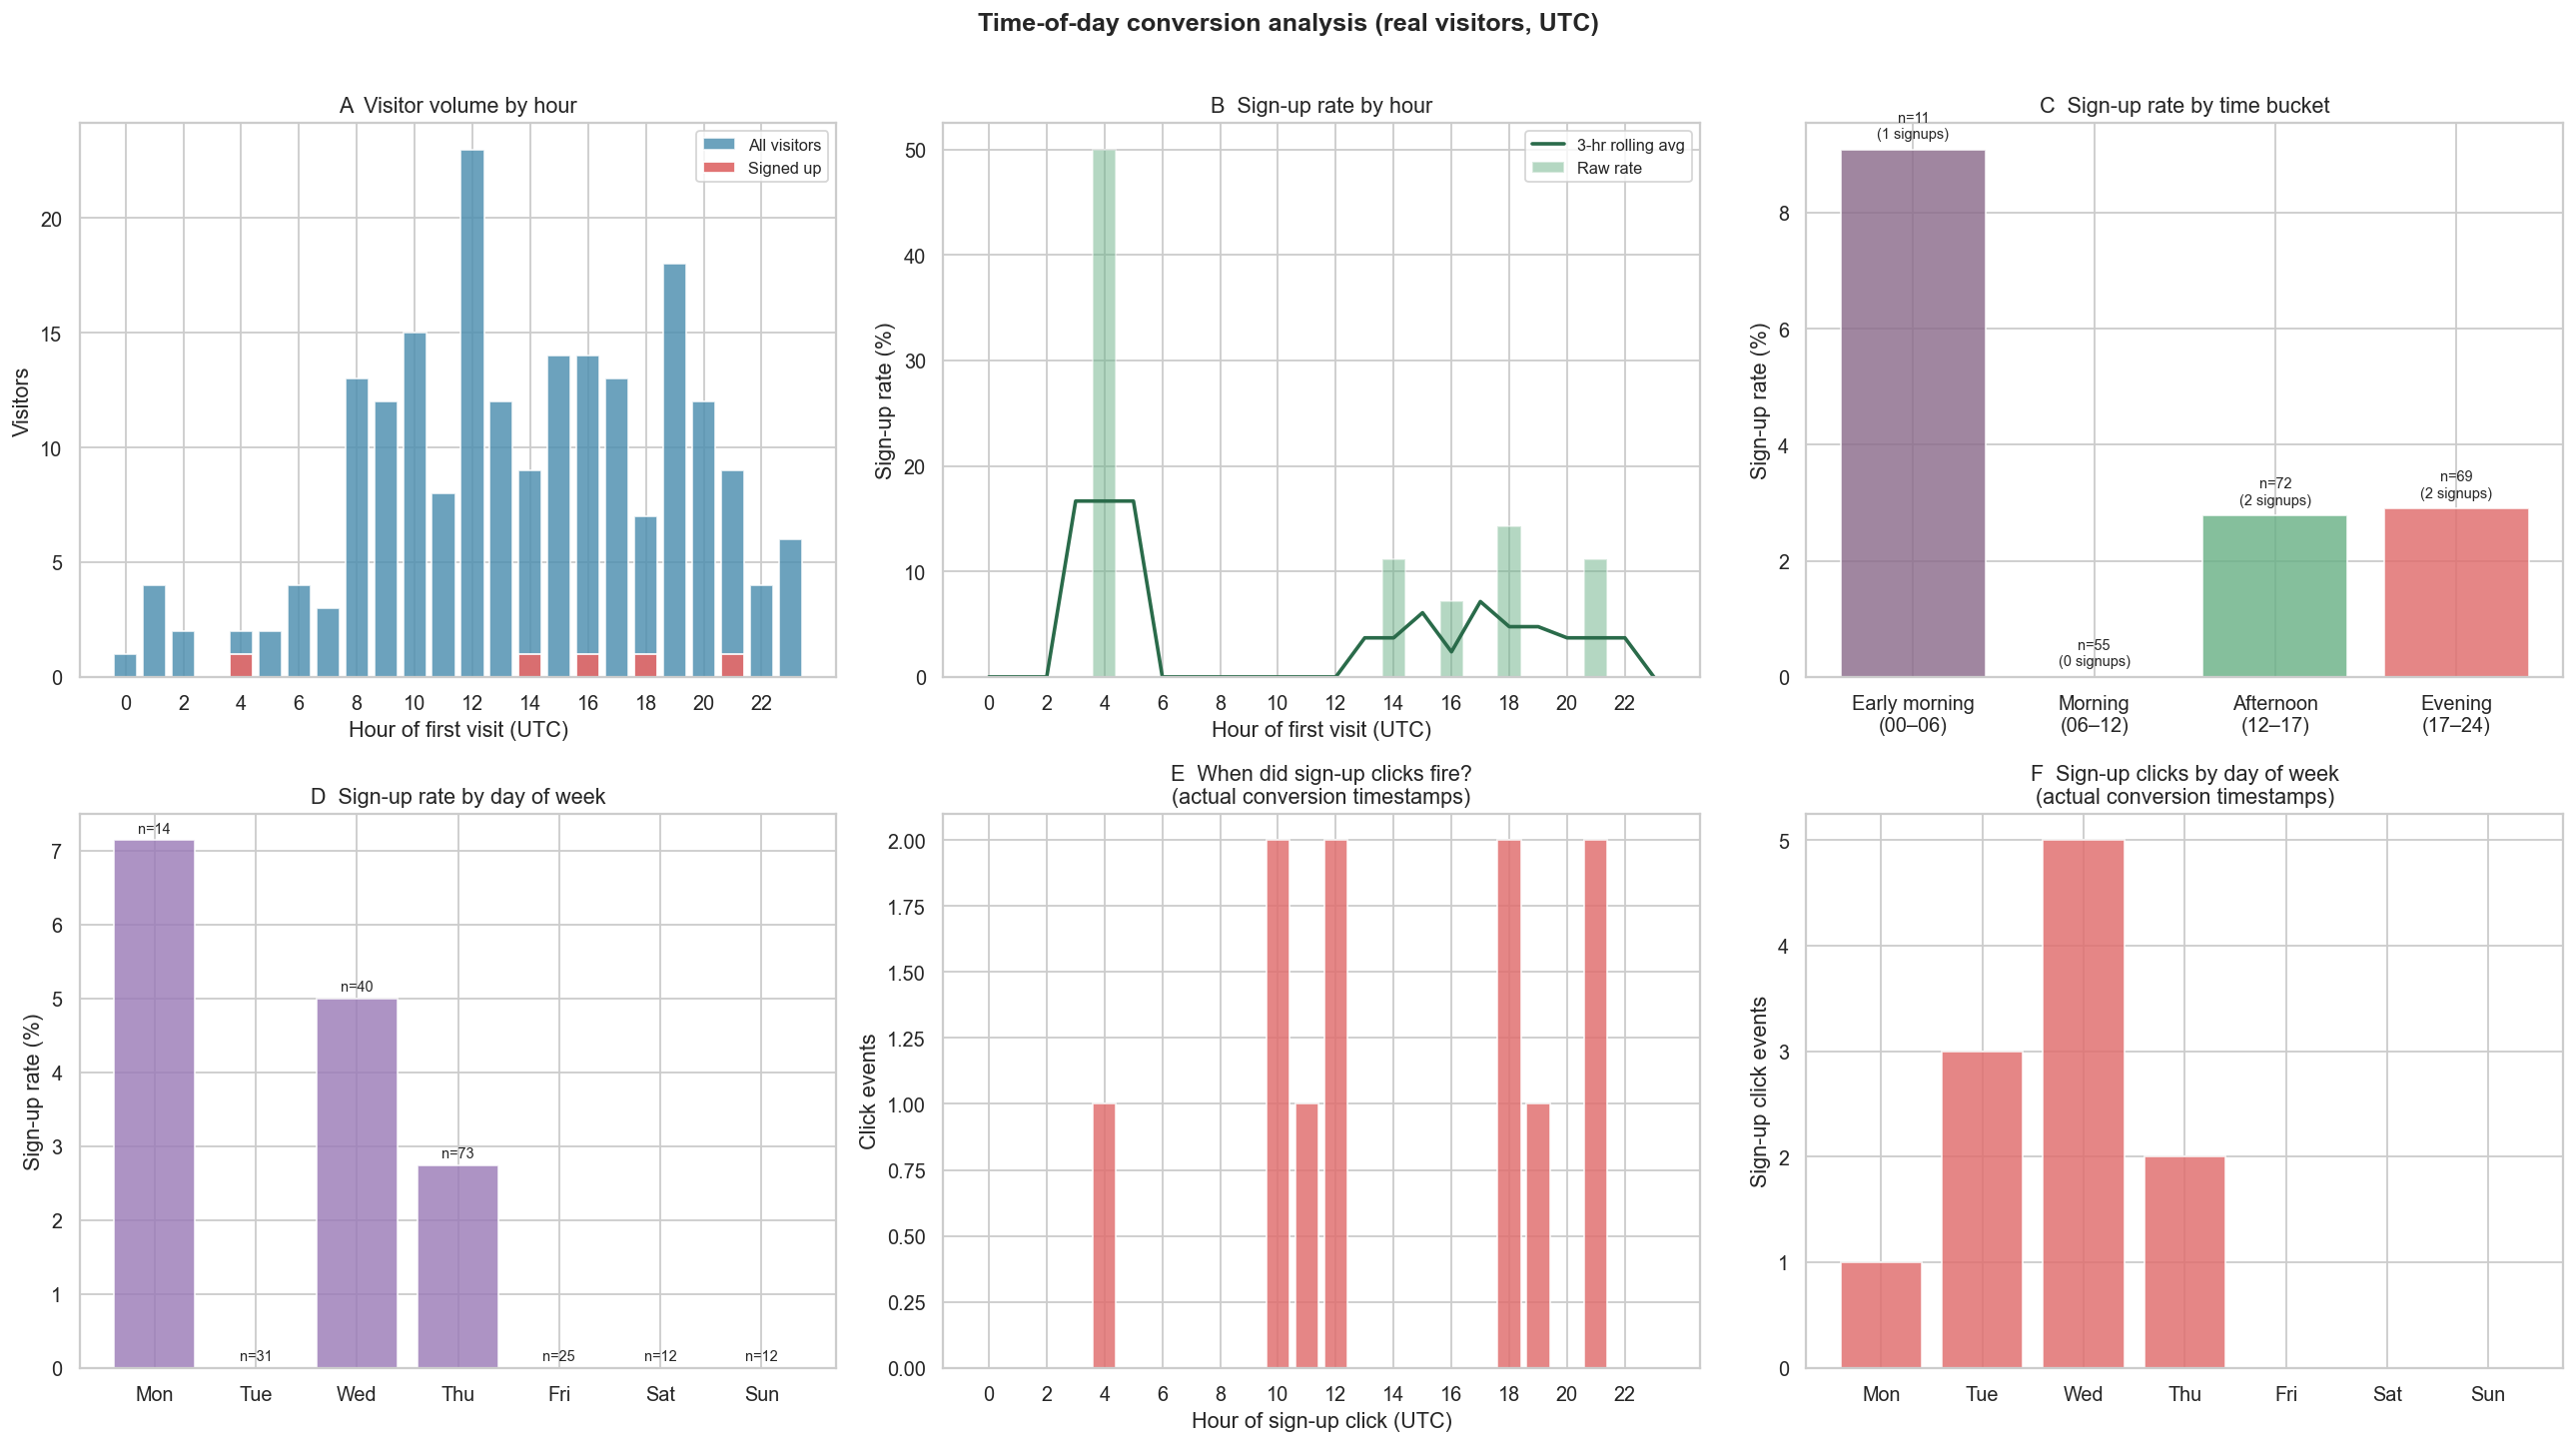

In [31]:
# ── FIGURE: time-of-day conversion dashboard ──────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle("Time-of-day conversion analysis (real visitors, UTC)",
             fontsize=14, fontweight="bold", y=1.01)

_BAR_ALPHA = 0.82
_BLUE  = "#4C8EAF"
_RED   = "#E06C6C"
_GREEN = "#6AB187"

# ── Panel A: visitor count by hour with sign-up overlay ──────────────────────
ax = axes[0, 0]
ax.bar(_hourly["visit_hour"], _hourly["visitors"],  color=_BLUE,  alpha=_BAR_ALPHA, label="All visitors")
ax.bar(_hourly["visit_hour"], _hourly["signups"],   color=_RED,   alpha=0.95,       label="Signed up")
ax.set_xlabel("Hour of first visit (UTC)"); ax.set_ylabel("Visitors")
ax.set_title("A  Visitor volume by hour"); ax.set_xticks(range(0, 24, 2))
ax.legend(fontsize=9)

# ── Panel B: sign-up rate by hour (smoothed + raw) ───────────────────────────
ax = axes[0, 1]
_rate_filled = _hourly["rate"].fillna(0).values
_smoothed    = uniform_filter1d(_rate_filled, size=3)
ax.bar(_hourly["visit_hour"], _rate_filled, color=_GREEN, alpha=0.5, label="Raw rate")
ax.plot(range(24), _smoothed, color="#2A6B4A", lw=2, label="3-hr rolling avg")
ax.set_xlabel("Hour of first visit (UTC)"); ax.set_ylabel("Sign-up rate (%)")
ax.set_title("B  Sign-up rate by hour"); ax.set_xticks(range(0, 24, 2))
ax.legend(fontsize=9)

# ── Panel C: time-bucket sign-up rate with n annotations ─────────────────────
ax = axes[0, 2]
_bcolors = ["#8B6B8B", "#4C8EAF", "#6AB187", "#E06C6C"]
bars = ax.bar(_buckets["bucket"], _buckets["rate"].fillna(0),
              color=_bcolors, alpha=_BAR_ALPHA)
for bar, (_, row) in zip(bars, _buckets.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.15,
            f"n={int(row['visitors'])}\n({int(row['signups'])} signups)",
            ha="center", va="bottom", fontsize=8)
ax.set_ylabel("Sign-up rate (%)"); ax.set_title("C  Sign-up rate by time bucket")

# ── Panel D: sign-up rate by day of week ─────────────────────────────────────
ax = axes[1, 0]
ax.bar(_daily["day"], _daily["rate"].fillna(0), color="#9B7BB8", alpha=_BAR_ALPHA)
for _, row in _daily.iterrows():
    ax.text(row["day"], row["rate"] + 0.1 if pd.notna(row["rate"]) else 0.1,
            f"n={int(row['visitors'])}", ha="center", fontsize=8)
ax.set_ylabel("Sign-up rate (%)"); ax.set_title("D  Sign-up rate by day of week")

# ── Panel E: sign-up click hour distribution (when conversion actually fires) ─
ax = axes[1, 1]
if len(_su_events) > 0:
    _su_hourly = _su_events["hour"].value_counts().reindex(range(24), fill_value=0).sort_index()
    ax.bar(_su_hourly.index, _su_hourly.values, color=_RED, alpha=_BAR_ALPHA)
    ax.set_xlabel("Hour of sign-up click (UTC)"); ax.set_ylabel("Click events")
    ax.set_title("E  When did sign-up clicks fire?\n(actual conversion timestamps)")
    ax.set_xticks(range(0, 24, 2))
else:
    ax.text(0.5, 0.5, "No sign-up events\nfound", transform=ax.transAxes,
            ha="center", va="center")
    ax.set_title("E  Sign-up click hour")

# ── Panel F: sign-up clicks by day of week ───────────────────────────────────
ax = axes[1, 2]
if len(_su_events) > 0:
    _su_daily = (_su_events["dow"].value_counts()
                 .reindex(range(7), fill_value=0).sort_index())
    ax.bar([_DOW_LABELS[d] for d in _su_daily.index], _su_daily.values,
           color="#E06C6C", alpha=_BAR_ALPHA)
    ax.set_ylabel("Sign-up click events")
    ax.set_title("F  Sign-up clicks by day of week\n(actual conversion timestamps)")
else:
    ax.text(0.5, 0.5, "No sign-up events\nfound", transform=ax.transAxes,
            ha="center", va="center")
    ax.set_title("F  Sign-up click day")

plt.tight_layout()
_tod_path = Path("../outputs/signup_time_of_day.png")
plt.savefig(_tod_path, dpi=150, bbox_inches="tight")
plt.show()

In [32]:
# ── STATISTICAL TEST: does conversion rate differ across time buckets? ─────────
# With only ~5 sign-up clickers a chi-square will be underpowered.
# We run it for completeness but interpret cautiously.

_ct = pd.crosstab(_tod["bucket"], _tod["clicked_signup"])
_ct = _ct.reindex(_BUCKET_ORDER).fillna(0)
print("Contingency table (first-visit bucket vs sign-up):")
print(_ct.to_string())
print()

if _ct.shape == (4, 2) and _ct.values.min() >= 0:
    chi2, p, dof, expected = chi2_contingency(_ct, correction=True)
    print(f"Chi-square (Yates correction): χ²={chi2:.3f}  df={dof}  p={p:.3f}")
    if p < 0.05:
        print("→ Statistically significant difference across buckets (p<0.05)")
    elif p < 0.10:
        print("→ Marginal trend (p<0.10) — suggestive but not conclusive at n this small")
    else:
        print("→ No statistically significant difference (p≥0.05)")
    print()
    print("Expected counts under H₀:")
    print(pd.DataFrame(expected.round(1), index=_BUCKET_ORDER, columns=_ct.columns).to_string())
    print()
    print("⚠ Note: with only", int(_tod['clicked_signup'].sum()),
          "sign-up clickers, this test is severely underpowered.")
    print("  Treat bucket patterns as directional hypotheses for future A/B testing,")
    print("  not as confirmatory evidence.")

Contingency table (first-visit bucket vs sign-up):
clicked_signup           0  1
bucket                       
Early morning\n(00–06)  10  1
Morning\n(06–12)        55  0
Afternoon\n(12–17)      70  2
Evening\n(17–24)        67  2

Chi-square (Yates correction): χ²=3.549  df=3  p=0.314
→ No statistically significant difference (p≥0.05)

Expected counts under H₀:
clicked_signup             0    1
Early morning\n(00–06)  10.7  0.3
Morning\n(06–12)        53.7  1.3
Afternoon\n(12–17)      70.3  1.7
Evening\n(17–24)        67.3  1.7

⚠ Note: with only 5 sign-up clickers, this test is severely underpowered.
  Treat bucket patterns as directional hypotheses for future A/B testing,
  not as confirmatory evidence.


### Time-of-day — interpretation guide

| Panel | What to look for |
|---|---|
| **A — volume by hour** | When is the demo busiest? Peaks indicate when marketing/outreach drives traffic |
| **B — rate by hour** | Are high-traffic hours also high-conversion hours, or do off-peak hours punch above their weight? |
| **C — bucket rate** | Coarser view: morning vs afternoon vs evening intent differences |
| **D — day of week** | Weekday vs weekend behaviour; B2B audiences typically skew weekday |
| **E — click hour** | The actual moment of conversion — may differ from first-visit hour if visitors return |
| **F — click day** | Whether conversions cluster on specific days, independent of visit volume |

**Key caveat:** n=5 sign-up clickers means no individual bucket rate is statistically reliable on its own. Use these charts to *generate hypotheses* (e.g. "afternoon visitors seem to convert at higher rates") and test them as traffic grows.